<div>

<h1>Machine Learning 2026 — Homework</h1>

<h2>Online Shoppers Purchasing Intention</h2>
<br>
<table>
  <thead>
    <tr>
      <th>Student</th>
      <th>Name</th>
      <th>Surname</th>
      <th>Student ID</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1</td>
      <td>Annachiara</td>
      <td>Amoia</td>
      <td>301812</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Tiziano</td>
      <td>Marsigliani</td>
      <td>301821</td>
    </tr>
  </tbody>
</table>

<br>

<p>
  <strong>Course:</strong> Machine Learning 2026<br>
  <strong>Academic Year:</strong> 2025–2026
</p>

</div>

<hr>


# Request 1
Perform preliminary analysis of the data. For instance, but not limited
to

- visualizing samples 
- identifying if features are correlated
- determining which features are most correlated with the target class
- inspecting the distribution of samples among classes. 

We want to:
- Recover the data for the Exit Rate variable
- Train a regressor to predict this variable’s values given the remaining variables
- Compare different regression algorithms for this task
- Perform feature selection. 

Since this feature is also missing in the test set, use only the training data for this step and use robust evaluation
techniques to compare algorithms.

***

## Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
import itertools
import random
import matplotlib.colors as mcolors

from scipy.stats import contingency, t, f, norm

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, make_scorer, silhouette_score,accuracy_score,precision_score,recall_score,f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.feature_selection import SelectKBest, f_classif 
from sklearn.svm import SVC

## Dataset loading

In [2]:
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
train_data.head()


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


In [3]:
#Dataset cleaning: removing the first column
train_data = train_data.drop(train_data.columns[0], axis = 1)
train_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


In [4]:
#Dataset dimensions:
train_data.shape

(9248, 18)

## Preliminary data analysis

- Finding duplicates
- Finding missing values
- Inspecting the variables types
- Distinguishing categorical and numerical features

In [5]:
# Finding duplicates
print("Number of duplicates:", train_data.duplicated().sum())

duplicate_counts = (train_data.value_counts().reset_index(name="count"))
display(duplicate_counts[duplicate_counts["count"] > 1])

Number of duplicates: 45


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,count
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False,8
1,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,2,2,1,3,Returning_Visitor,False,False,4
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False,3
3,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,May,1,1,1,3,Returning_Visitor,False,False,3
4,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Nov,2,2,1,1,Returning_Visitor,False,False,2
5,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,2,1,Returning_Visitor,False,False,2
6,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,2,2,1,3,Returning_Visitor,False,False,2
7,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,2,2,1,13,Returning_Visitor,False,False,2
8,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,2,2,2,1,Returning_Visitor,False,False,2
9,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,1,1,Returning_Visitor,False,False,2


After removing the CSV index column, 45 rows are exact duplicates across the variables considered in the analysis. However, the corresponding original row identifiers were different. Since the dataset contains aggregate session information, different sessions may legitimately share the same recorded values. For this reason, we retain these observations.

In [6]:
#Missing values
train_data.isnull().sum()

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

In [7]:
#Data types
train_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [8]:
#Categorical variables
Categorical_columns = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
for c in Categorical_columns:
    print(f"{c}:", train_data[c].unique())
    print("")

#Numerical variables
Numerical_columns = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration','ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
print("Numerical variables:", Numerical_columns)

Month: ['May' 'Nov' 'Dec' 'Sep' 'Mar' 'Oct' 'Aug' 'June' 'Jul' 'Feb']

OperatingSystems: [2 3 1 4 8 5 7 6]

Browser: [ 2  1  4 10  5  3  8  6 13  7 11 12]

Region: [1 3 4 6 8 7 2 5 9]

TrafficType: [ 3  2  1 10 13  4  8  6 11  5 20  9 15  7 14 19 18 16 12 17]

VisitorType: ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: [False  True]

Numerical variables: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


## Distribution analysis
We proceed our analysis by inspecting the distribution of our featurs:
- target class (Revenue) distribution
- categorical variable distribution

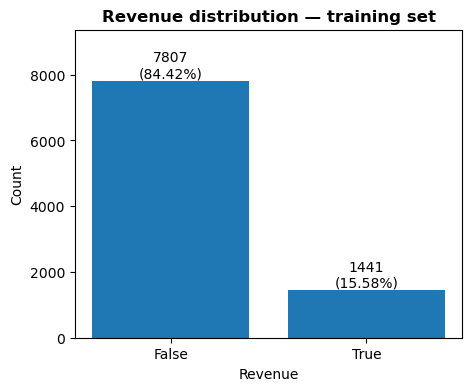

In [9]:
#Target class distribution

Revenue_distribution = train_data['Revenue'].value_counts().rename_axis('Revenue').reset_index(name='count')
Revenue_distribution['Percentage'] = 100 * Revenue_distribution['count'] / len(train_data)

plt.figure(figsize=(5,4))
bars = plt.bar(Revenue_distribution['Revenue'].astype(str), Revenue_distribution['count'])

plt.title('Revenue distribution — training set', weight = "bold")
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.xticks(rotation=0)

for bar, count, percentage in zip(bars, Revenue_distribution['count'], Revenue_distribution['Percentage']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{count}\n({percentage:.2f}%)',
        ha='center',
        va='bottom')

plt.ylim(0, Revenue_distribution['count'].max() * 1.20)
plt.show()



It appears very clearly from this plot that the Revenue class is unbalanced. Indeed, the percentage of visitors who made a purchase is low with respect to those who didn't. 

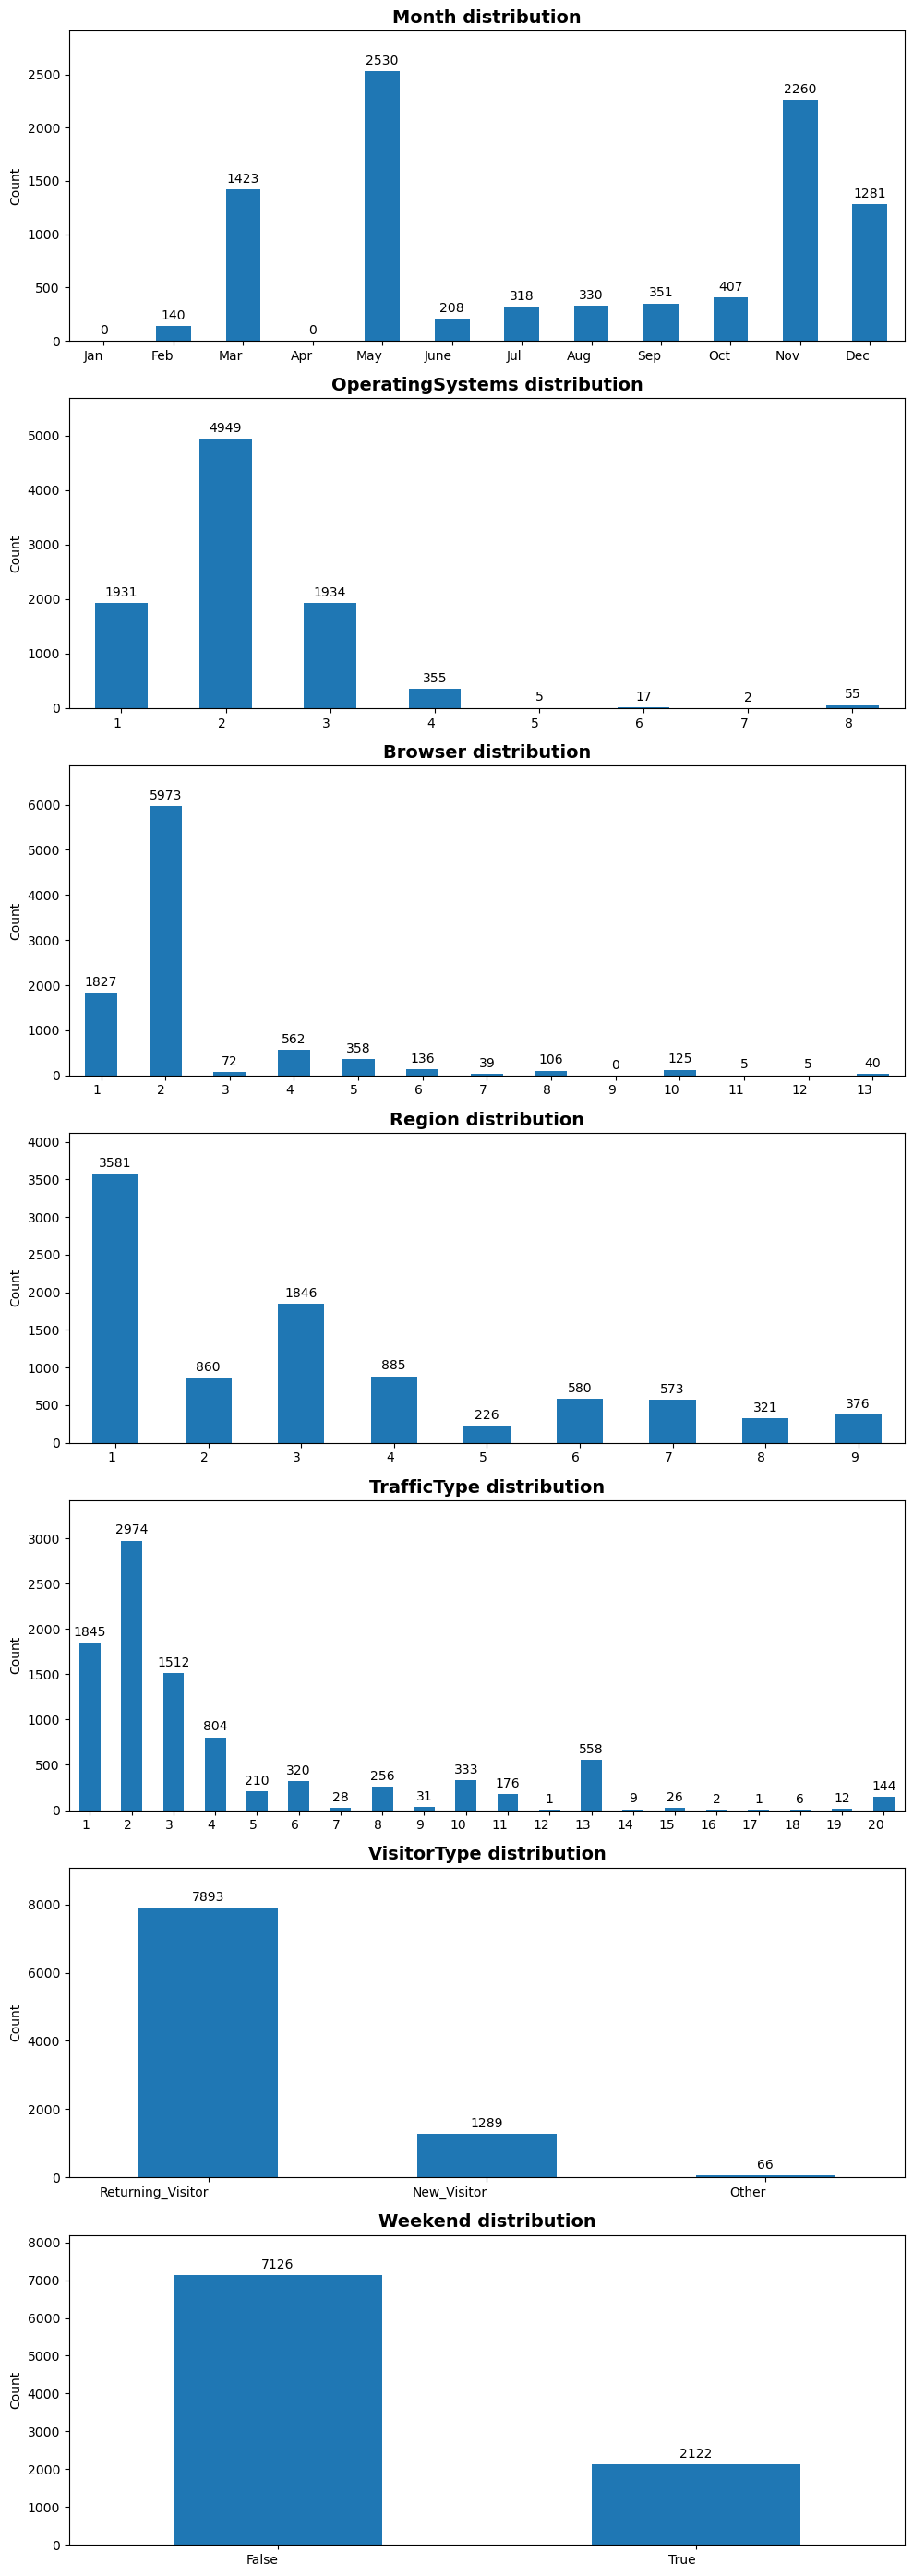

In [10]:
#Categorical variables distribution

category_orders = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'OperatingSystems': range(1,9),
    'Browser': range(1,14),
    'Region': range(1,10),
    'TrafficType': range(1,21),
    'VisitorType': ['Returning_Visitor', 'New_Visitor', 'Other'],
    'Weekend': [False, True]
}


plt.figure(figsize=(10, 4 * 7))

for i, col in enumerate(Categorical_columns, 1):
    ax = plt.subplot(7, 1, i)

    counts = train_data[col].value_counts(dropna=False)
    counts = counts.reindex(category_orders[col], fill_value=0)
    
    counts.plot(kind='bar', ax = ax)
    ax.bar_label(ax.containers[0], padding=3)
    ax.margins(y=0.15)
    ax.set_xlabel('')

    plt.title(f"{col} distribution", weight = "bold", size=14)
    plt.ylabel('Count')
    plt.xticks(rotation = 0, ha='right')

plt.tight_layout()
plt.show()


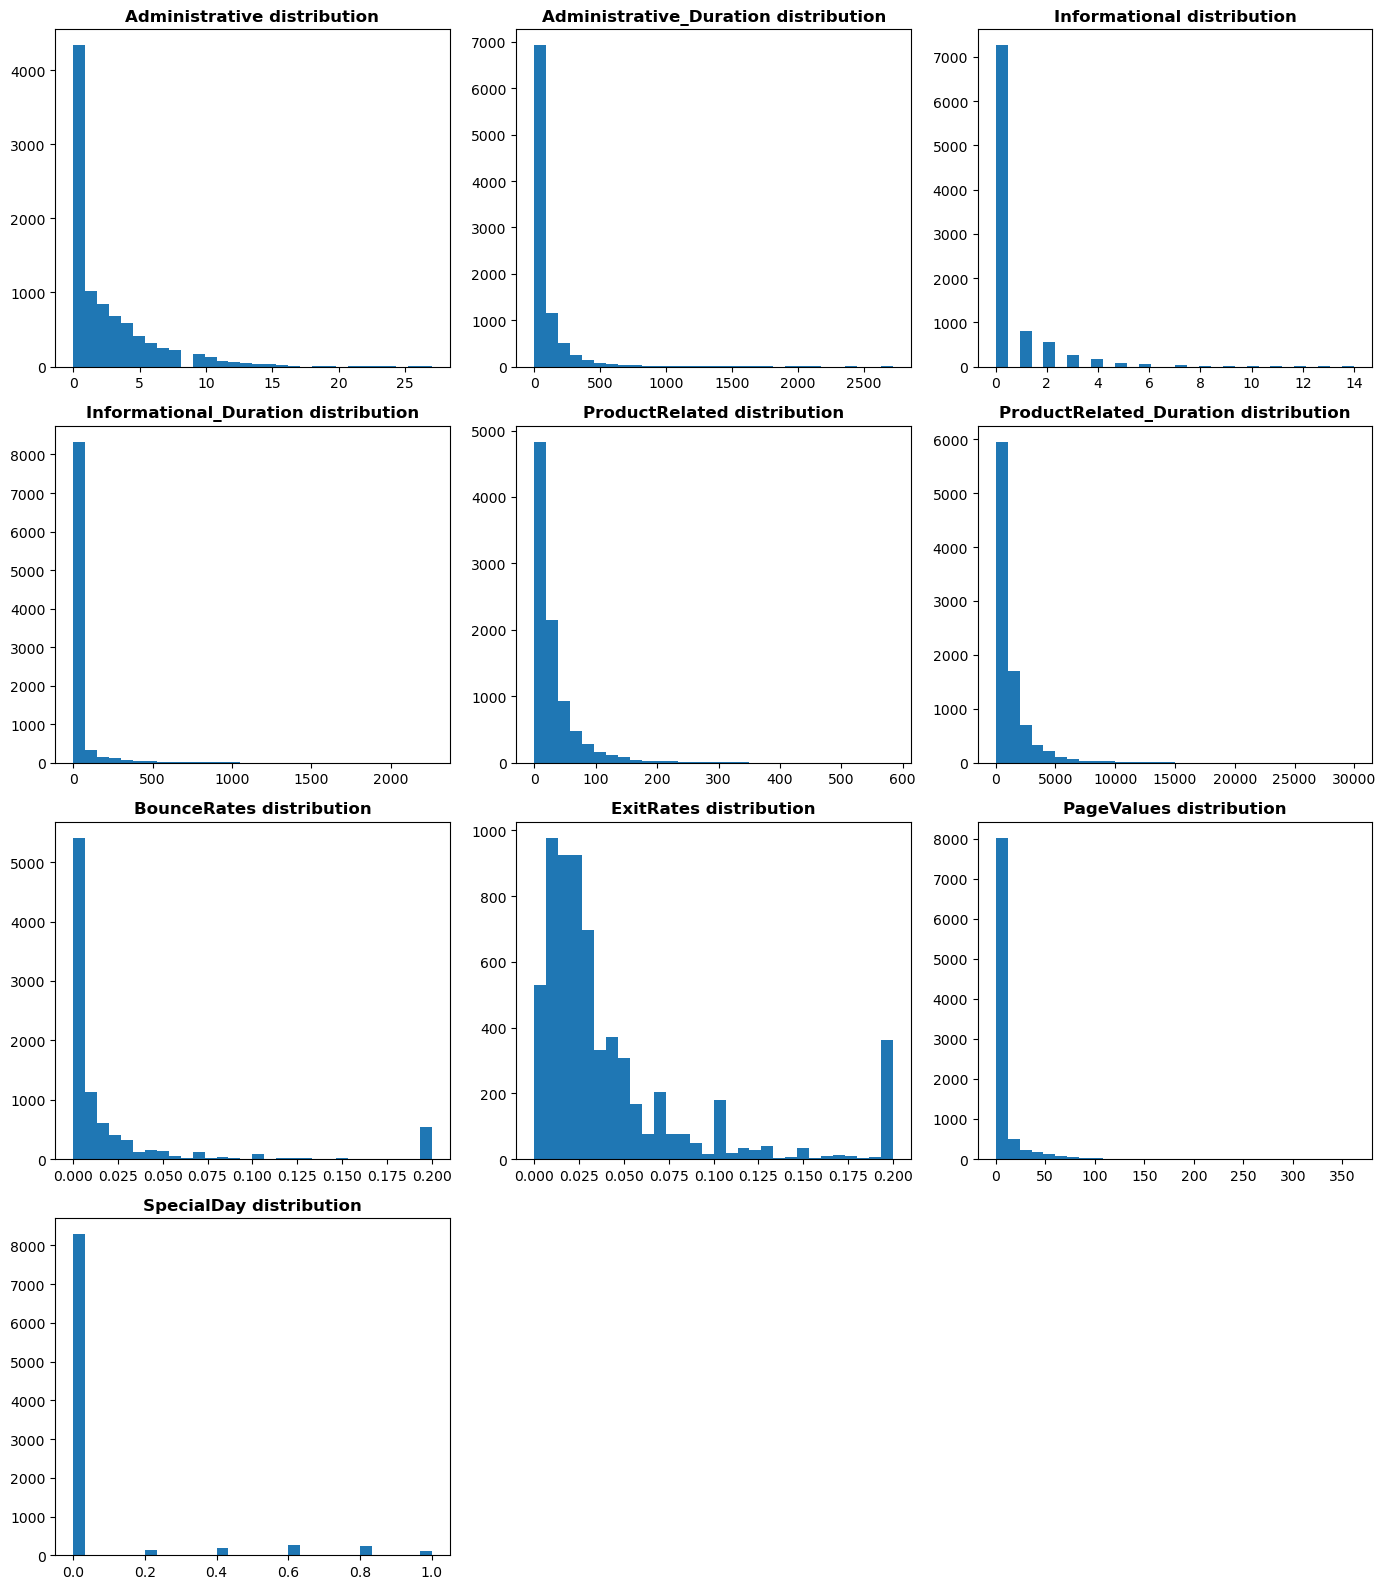

In [11]:
#Numerical variables
fig, axes = plt.subplots(4, 3, figsize=(14, 4*4))
axes = np.array(axes).ravel()
for ax, col in zip(axes, Numerical_columns):
    train_data[col].hist(ax=ax, bins=30, grid =False)
    ax.set_title(f"{col} distribution", weight = "bold", size=12)
for ax in axes[len(Numerical_columns):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Correlation Analysis
- __correlation matrix__ for numerical features: it measures the statistical relationship between pairs of variables, especially how strongly they are **linearly related**. <br>
We use Spearman's rank correlation because several numerical variables are strongly skewed. Unlike Pearson correlation, Spearman correlation does not require a linear relationship and is less sensitive to extreme values. Correlation should be interpreted as association rather than evidence of causality.
- __association matrix__ for categorical variable

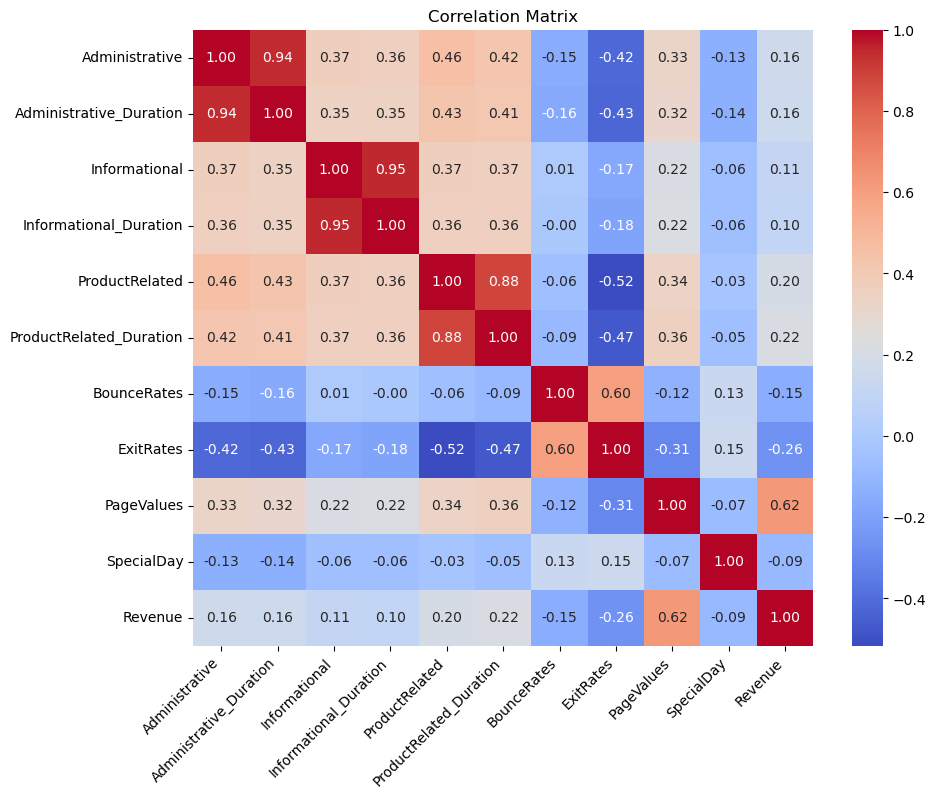

In [12]:
#Correlation matrix for numerical variables
corr_numeric = pd.concat([train_data[Numerical_columns], 
                          train_data["Revenue"]], 
                          axis = 1).corr(method='spearman') 

plt.figure(figsize=(10, 8))
sns.heatmap(corr_numeric, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Matrix")
plt.show()

The heatmap of the correlation matrix suggestes that there are some features highly correlated:
- Administrative/Administrative_Duration
- Informational/Informationa_Duration
- ProductRelated/ProductRelated_Duration

We have decide to keep them all, since we will later apply feature selection to determine the most significative


In [13]:
# Correlation between numerical features and target feature Revenue
print("Numerical features correlation with target variable Revenue:")
print(corr_numeric['Revenue'].sort_values(ascending=False))


Numerical features correlation with target variable Revenue:
Revenue                    1.000000
PageValues                 0.621472
ProductRelated_Duration    0.216546
ProductRelated             0.198903
Administrative             0.162048
Administrative_Duration    0.157420
Informational              0.106961
Informational_Duration     0.104869
SpecialDay                -0.086379
BounceRates               -0.147801
ExitRates                 -0.256284
Name: Revenue, dtype: float64


From these correlation coefficient, we see how the target variable "Revenue" is strongly positively correlated with the feature "PageValues". We will later use this information for answering to the second request.

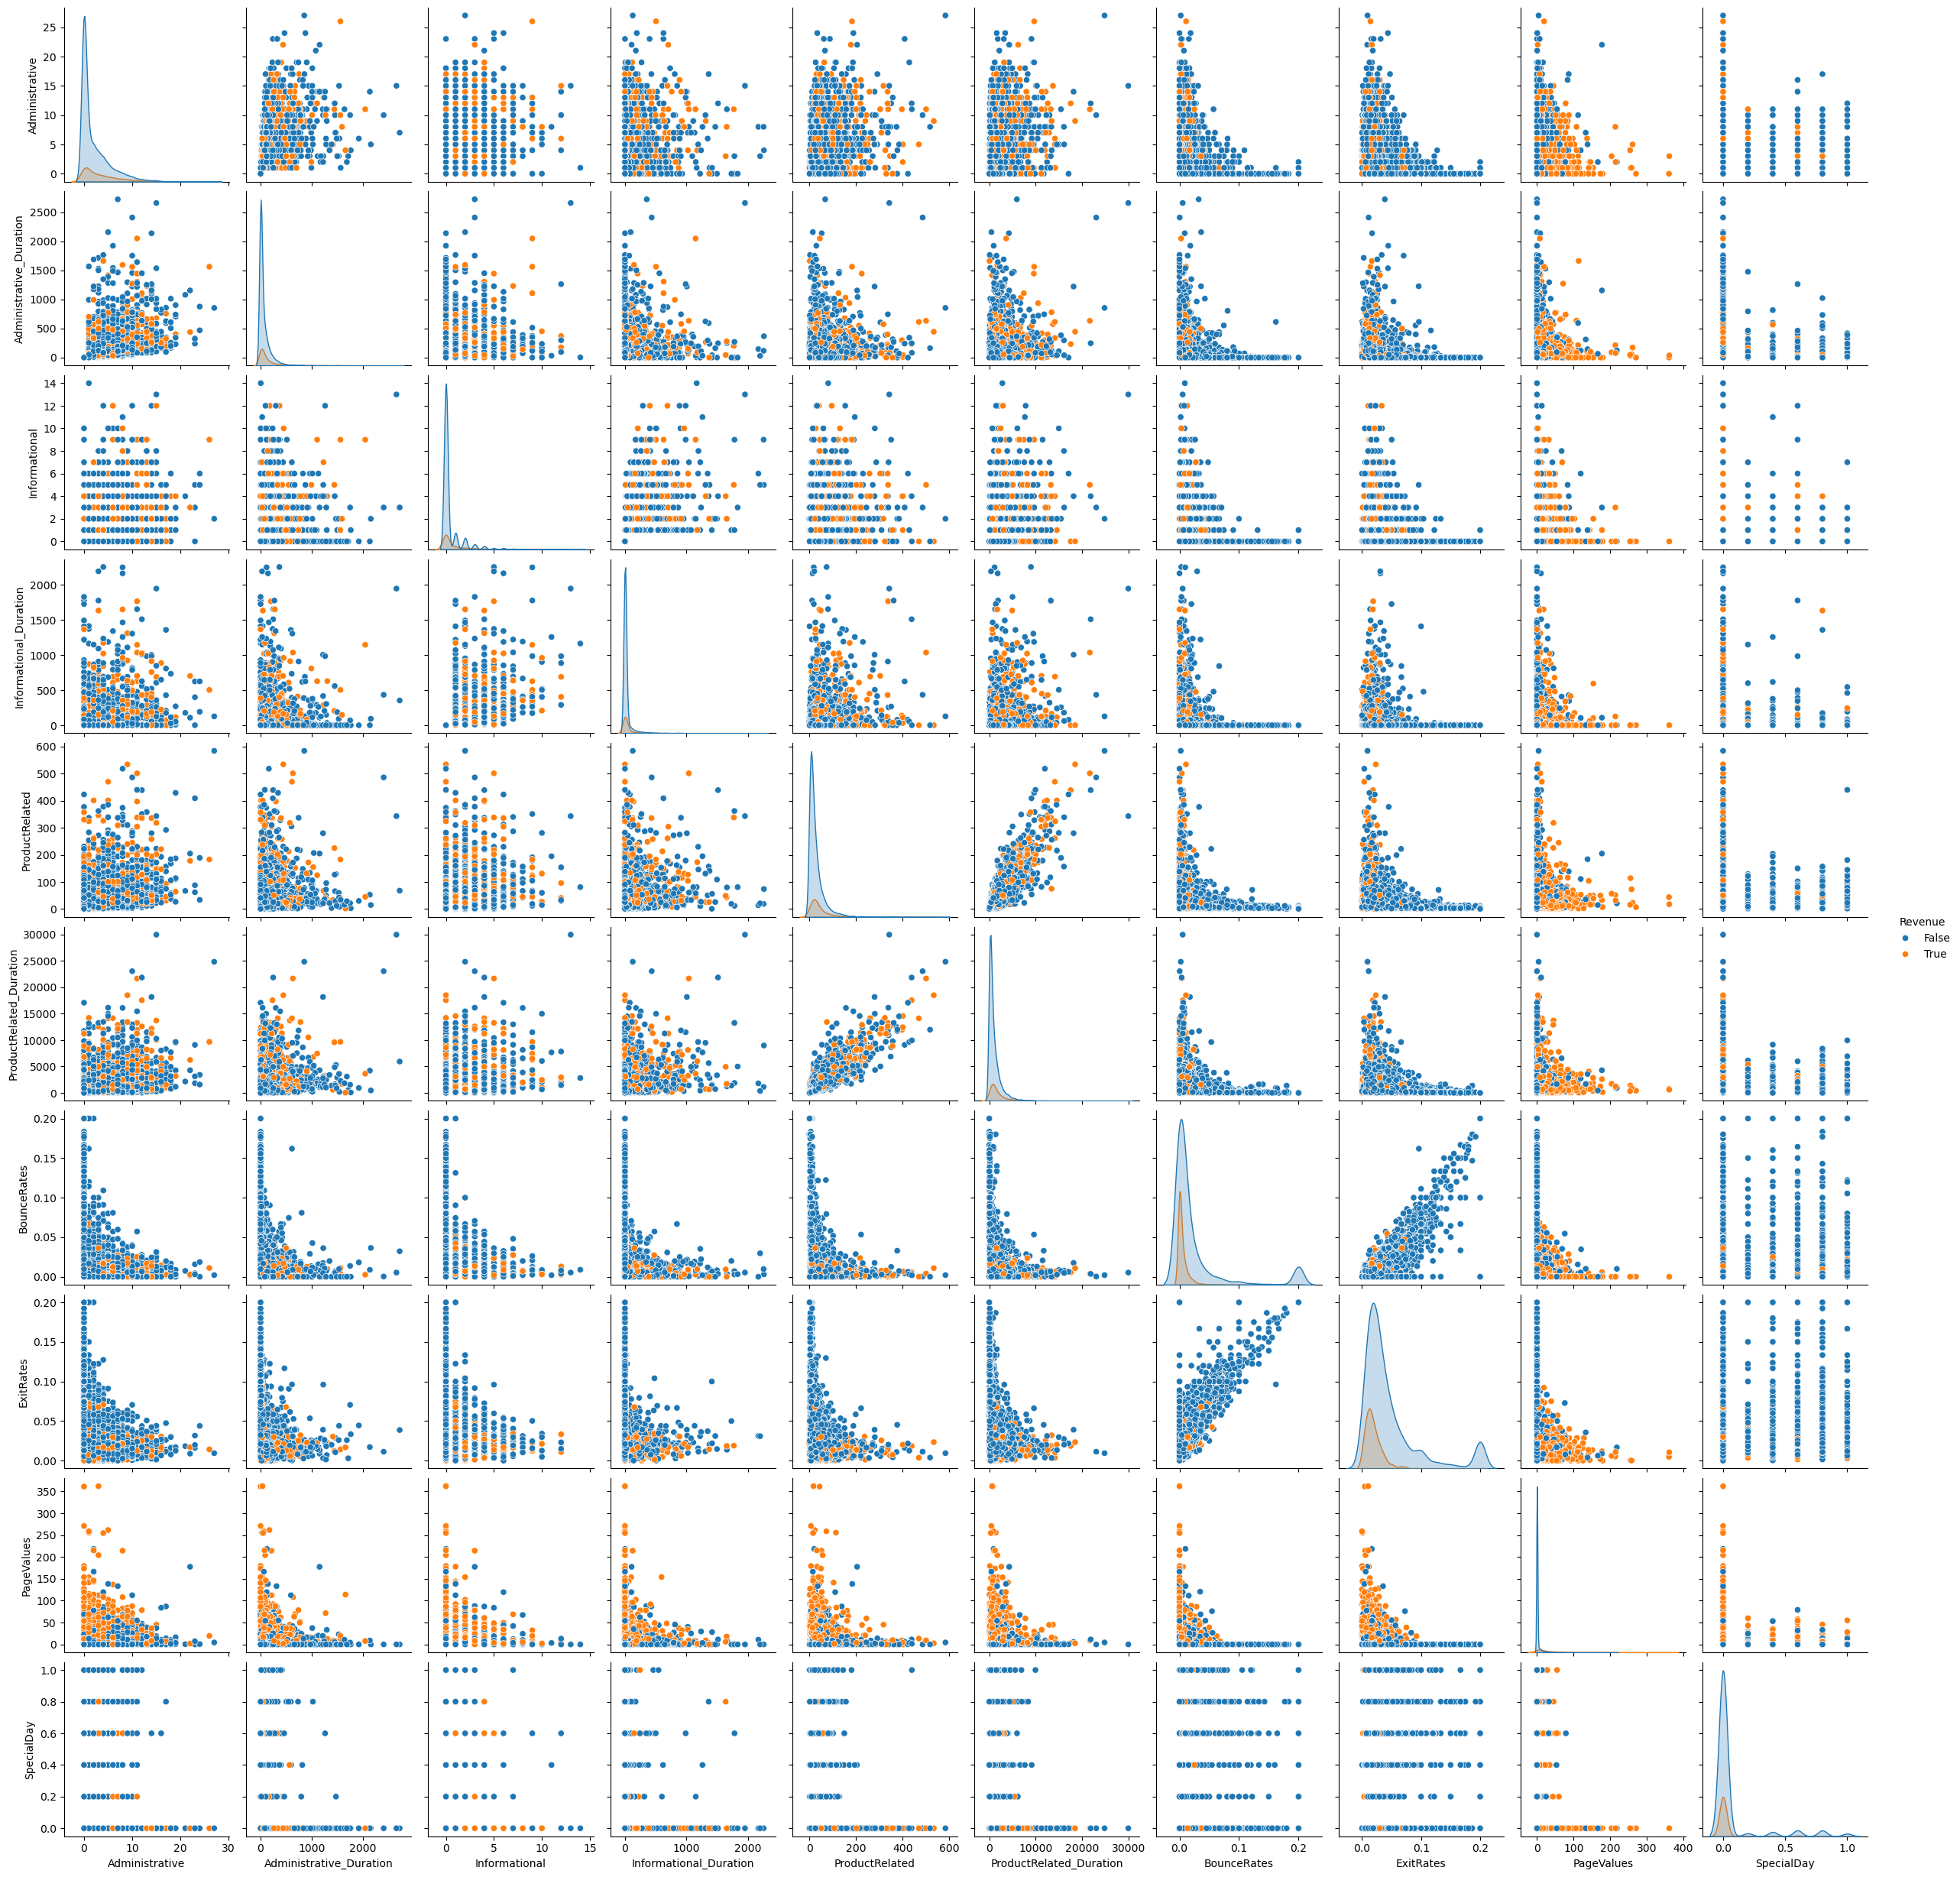

In [14]:
sns.pairplot(pd.concat([train_data[Numerical_columns], train_data["Revenue"]], axis = 1), hue='Revenue')

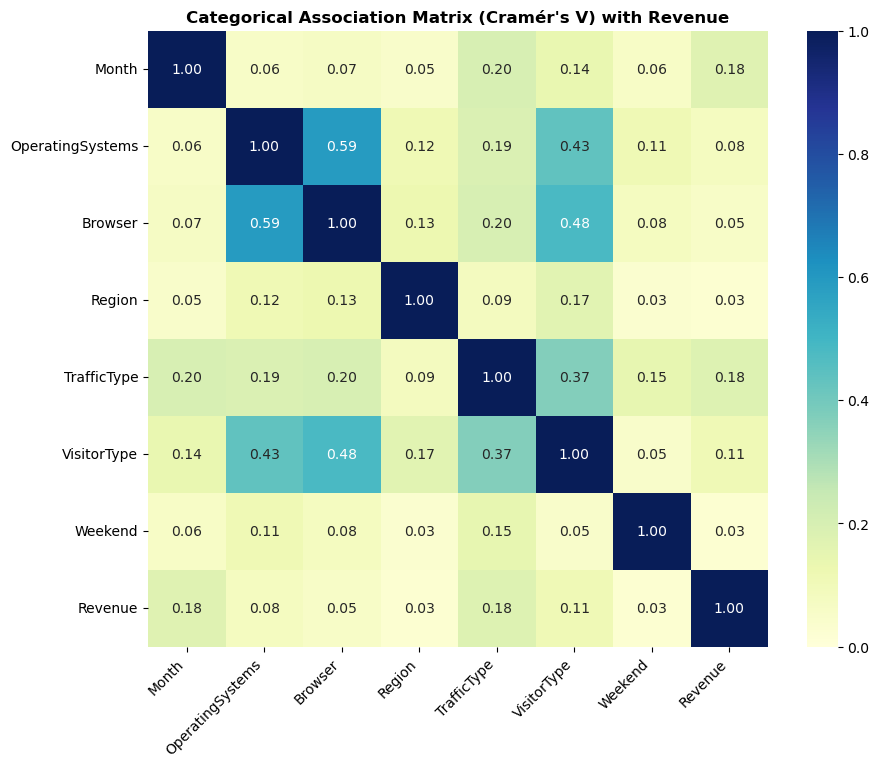

In [15]:
#Categorical association matrix

def cramers_v(x, y):
    """ Calculate Cramér's V statistic for two categorical variables """
    confusion_matrix = pd.crosstab(x, y)
    return contingency.association(confusion_matrix, method="cramer")

# 1. Compute the association matrix between Categorical Columns and Revenue
matrix_data = Categorical_columns + ['Revenue']
cv_matrix = pd.DataFrame(index=matrix_data, columns=matrix_data, dtype=float)

for col1 in matrix_data:
    for col2 in matrix_data:
        cv_matrix.loc[col1, col2] = cramers_v(train_data[col1], train_data[col2])

# 2. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cv_matrix, annot=True, cmap='YlGnBu', fmt=".2f", vmin=0, vmax=1)
plt.xticks(rotation=45, ha='right')
plt.title("Categorical Association Matrix (Cramér's V) with Revenue", weight='bold')
plt.show()


In [16]:
print("Categorical features association with target variable Revenue:")
print(cv_matrix["Revenue"].drop("Revenue").sort_values(ascending=False).to_frame())

Categorical features association with target variable Revenue:
                   Revenue
TrafficType       0.177473
Month             0.175780
VisitorType       0.111615
OperatingSystems  0.078593
Browser           0.054990
Region            0.026527
Weekend           0.026487


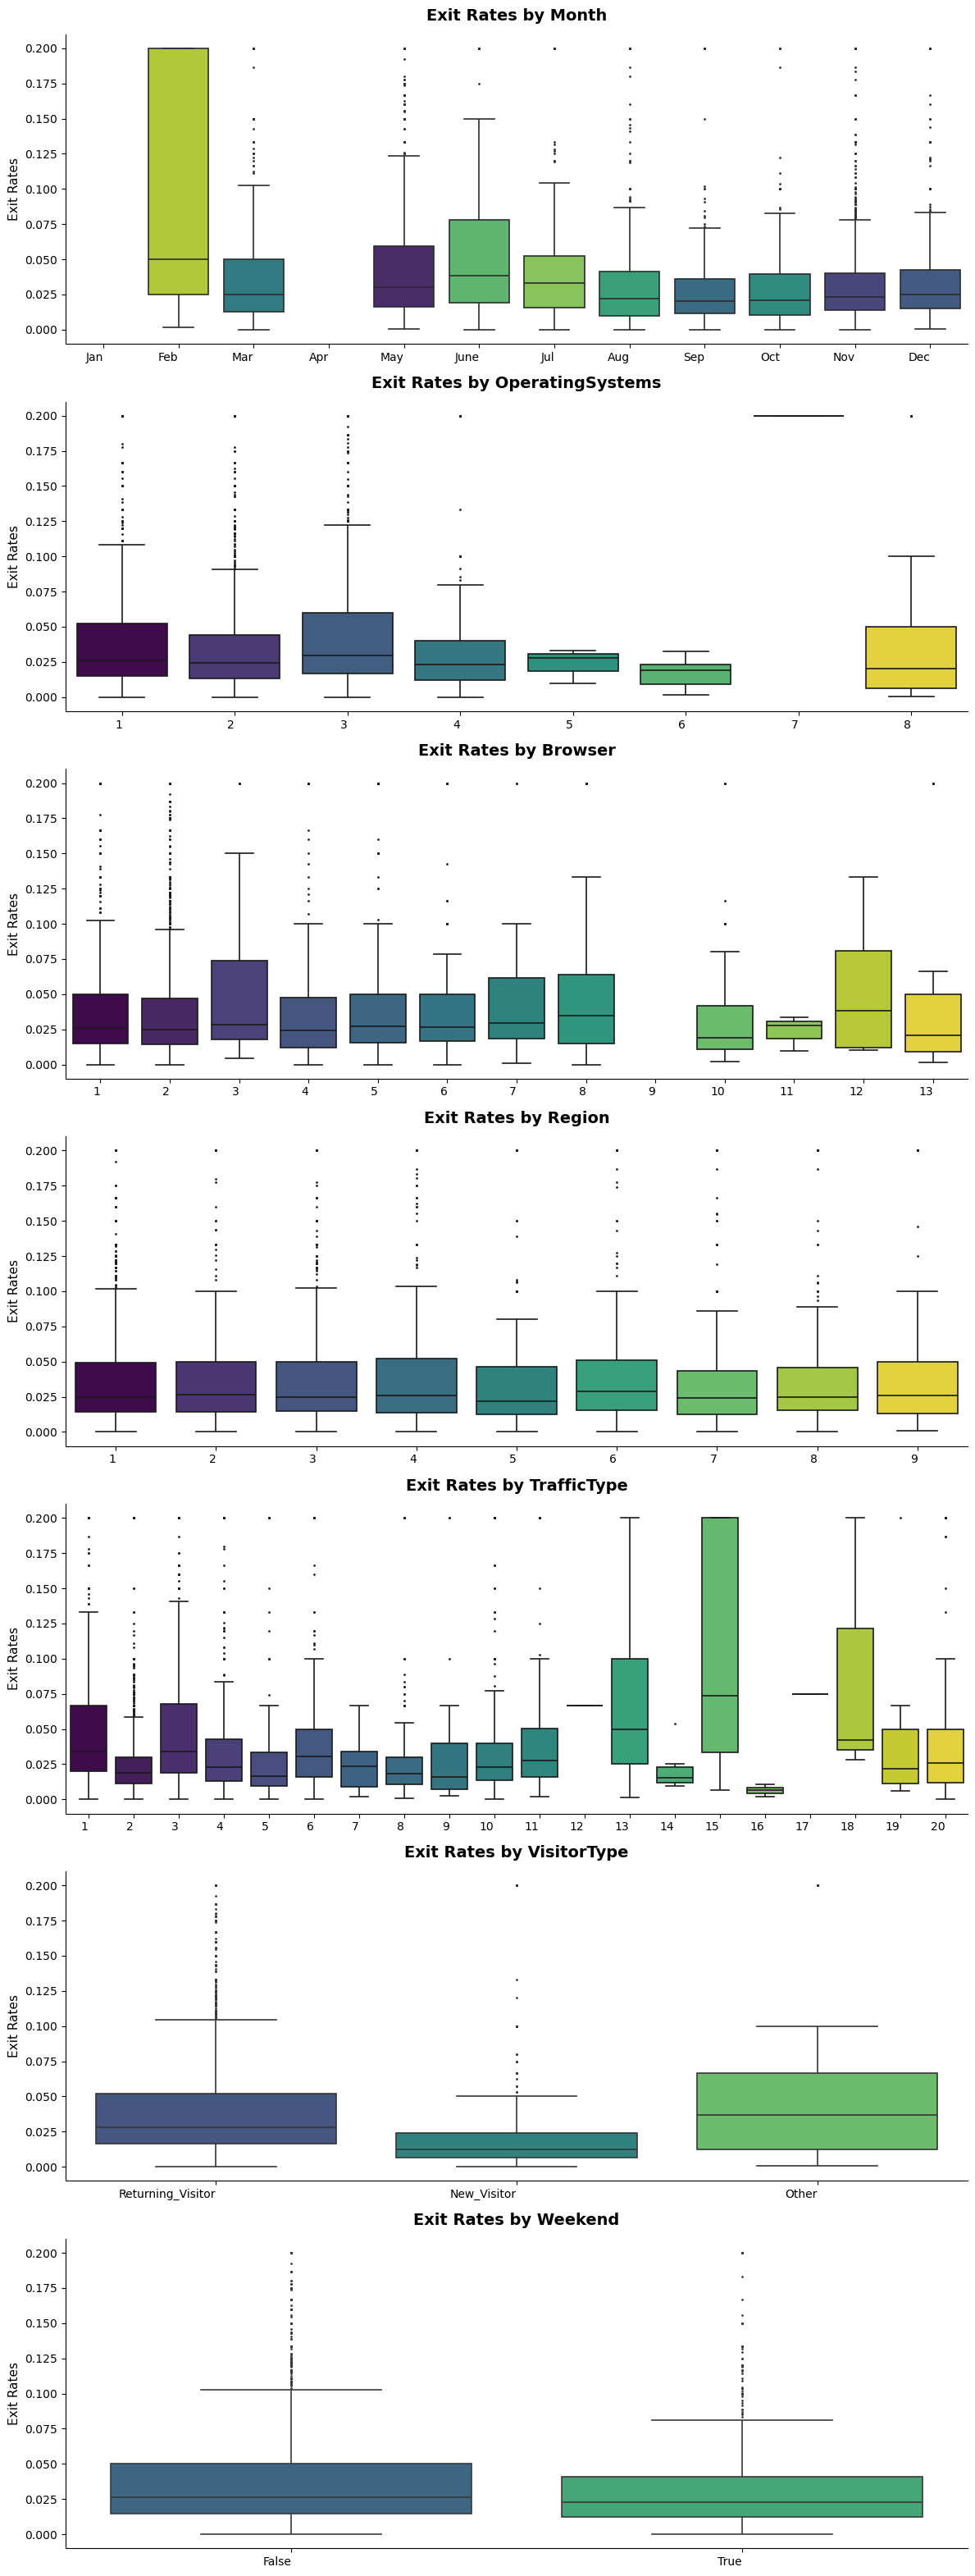

In [17]:
plt.figure(figsize=(12, 4.5 * len(Categorical_columns)))

for i, col in enumerate(Categorical_columns, 1):
    ax = plt.subplot(len(Categorical_columns), 1, i)

    sns.boxplot(
        data=train_data,
        x=col,
        y='ExitRates',
        order=category_orders.get(col),
        hue = col,
        legend = False,
        palette="viridis",
        fliersize=1,        
        linewidth=1.2,      
        ax=ax)

    ax.set_title(f'Exit Rates by {col}', fontsize=14, fontweight='bold', pad=12)
    ax.set_ylabel('Exit Rates', fontsize=11)
    ax.set_xlabel('') 
    plt.xticks(rotation=0, ha='right', fontsize=10)

    # Clean up borders without completely erasing the bottom scale line
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

## Regression analysis
Based on our preliminary data analysis, we identified missing values within the ExitRates feature. To address this, we will train a regression model to predict and impute these missing ExitRates values.

Because the model must be trained exclusively on complete data, we will first partition the dataset into two subsets based on the availability of the target variable:
- ER_known: Contains all observations where ExitRates is present (used for training and validation).
- ER_unknown: Contains the observations with missing ExitRates values (the target for our final predictions).

Then, we will select all available features except for ExitRates (our current target variable) and Revenue.
Excluding Revenue is a critical step to prevent data leakage. Since Revenue is the target variable the classification task, allowing the regression model to use it to predict ExitRates could bias our ultimate classification results.

In [18]:
#Partitioning the dataset
ER_known = train_data[train_data["ExitRates"].notna()]
ER_unknown = train_data[train_data["ExitRates"].isna()]
print("Training rows with known ExitRates:", len(ER_known))
print("Training rows requiring imputation:", len(ER_unknown))

Training rows with known ExitRates: 6466
Training rows requiring imputation: 2782


In [19]:
#Feature selection
features = [c for c in train_data.columns if c not in ["ExitRates", "Revenue"]]

X_raw = ER_known[features]
y = ER_known["ExitRates"]

### Preprocessing

1. __Partitioning the dataset ER_known into a training and a test set__: <br>
due to the project requirements, we will operate strictly within the provided training dataset; however, to ensure robust evaluation and prevent overfitting, we will further split this dataset to create an internal test set. This allows us to reliably measure model performance before final deployment.
2. __Encoding the categorical featues__: <br>
we chose the one-hot encoding approach, which allow us to not introduce any further structure on our data
3. __Standardization of numerical features__: <br>
Standardization places numerical variables on a comparable scale, which is particularly important for regularized regression models such as Ridge and Lasso.
4. __Cleaning the design matrix__: <br>
this step is crucial to avoid collinearity promblems

In [20]:
# Split known ExitRates dataset into training and internal test set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)
print(X_train_raw.shape, X_test_raw.shape)

(4526, 16) (1940, 16)


In [21]:
#Encoding categorical variables using one-hot encoding

categorical_features = [c for c in Categorical_columns if c in X_raw.columns]

X_train = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True, dtype=float)
X_test = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True, dtype=float)

#Align X_test to the training columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [22]:
#Standardization of numerical features

Numerical_features = [c for c in Numerical_columns if c in X_train.columns]

#We define a preprocessor
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), Numerical_features)],remainder="passthrough")

In [23]:
#Cleaning the design matrix

#1. Remove constant columns - they contain no useful information
constant_cols = X_train.columns[X_train.nunique(dropna=False) <= 1]

X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

#2. Remove duplicated columns - they introduce reduntant information and can lead to multicollinearity
duplicate_cols = X_train.columns[X_train.T.duplicated()]

X_train = X_train.drop(columns=duplicate_cols)
X_test = X_test.drop(columns=duplicate_cols)

### Multiple Linear Regression Model

Linear Regression assumes that there is approximately a linear relationship between $X$ and $Y$, where $X$ is the set of features of each sample, and $Y$ is the variable we want to predict. <br>
Mathematically we can write:  $Y \approx \beta_0 + \beta_1 X$

The most common method to find a solution for the linear regression problem is the least squares algorithm. 
We want to find the values for the models parameters that minimize the residual sum of squares. We consider the following model:

$\hat{y}=\hat{\beta}_{0}+\hat{\beta}_{1} x_{1}+\hat{\beta}_{2} x_{2}+\cdots+\hat{\beta}_{p} x_{p}$

The Least Squares solution to the problem, in matrix form, is:

$\hat{\beta}=\left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T} \mathbf{y} \quad\quad$  with $X$ a $N \times (p+1)$ matrix, $y$ a $N \times 1$ vector, $\hat{\beta}$ a $(p+1)\times 1$

$\hat{\mathbf{y}}=\mathbf{X} \hat{\beta}=\mathbf{X}\left(\mathbf{X}^{T} \mathbf{X}\right)^{-1} \mathbf{X}^{T} \mathbf{y} \quad\quad$  <br>
with $\hat{y}$ the predicted value for each sample (Matrix multiplication combines: all variables and all coefficients into predictions)


We will follow these steps:
1. __Definition of the hypothesis space__
2. __Model fitting on the train set__
3. __Computing training R2 score__
4. __Compute the statistics__

In [24]:
#Linear model pipeline
linear_model = Pipeline([("preprocessor", preprocessor),
                        ("regressor", LinearRegression())])

In [25]:
#Fitting the model on the training set
linear_model = linear_model.fit(X_train, y_train)


In [26]:
#Definition of validation metrics
r2_scorer = make_scorer(r2_score, greater_is_better=True)
mse_scorer = 'neg_mean_squared_error'

comparison_scoring = {
    "r2": r2_scorer,
    "neg_mse": mse_scorer}


In [27]:
#I will compute cross validation scores, rather than training scores, for a better comparison
#with other models

linear_full_cv_results = cross_validate(
    estimator=linear_model,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=comparison_scoring,
    return_train_score=False,
    n_jobs=-1)

linear_full_cv_r2 = linear_full_cv_results["test_r2"].mean()

linear_full_cv_mse = -linear_full_cv_results["test_neg_mse"].mean()

print("Linear Regression mean CV R2:", linear_full_cv_r2)
print("Linear Regression mean CV MSE:", linear_full_cv_mse)

Linear Regression mean CV R2: 0.857998242182249
Linear Regression mean CV MSE: 0.00032619194488447636


In [28]:
#Functions to compute statistics for the linear regression model

# ============================================================
# Helper functions for regression statistics
# ============================================================

def rss(y_true, y_pred):
    y_true = y_true.reshape(y_pred.shape)
    return np.sum((y_true - y_pred) ** 2)

def tss(y):
    return np.sum((y - y.mean()) ** 2)

def multiple_least_squares(X, y):
    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)
    y_pred = model.predict(X)
    betas = [model.intercept_, *model.coef_]
    return betas, y_pred

# ============================================================
# Individual coefficient statistics: t-tests
# ============================================================

def show_stats(X, y, betas, names, alpha=None):

    """
    For every coefficient, the function reports:
    - estimated coefficient;
    - standard error;
    - t-statistic;
    - p-value;
    - rejection of H0, when alpha is provided.
    """

    n_samples, n_features = X.shape
    deg = n_samples-n_features - 1
    
    # If the ones column has not been added
    if X.shape[1] + 1 == betas.shape[0]:
        X = np.concatenate([np.ones([X.shape[0], 1]), X], axis=-1)
    
    # Compute the prediction
    pred = X.dot(betas).reshape(-1)
    betas = betas.reshape(-1)
    y = y.reshape(-1)
    RSE = ((y-pred)**2).sum()/(n_samples - n_features - 1)

    # Compute the t statistics
    se2_b = RSE*(np.linalg.inv(np.dot(X.T, X)).diagonal())
    se_b = np.sqrt(se2_b)
    t_stat_b = (betas - 0) / se_b

    # Compute the p-value
    p_values = np.array([2*t.sf(np.abs(t_stat), deg) for t_stat in t_stat_b])
    
    df = pd.DataFrame()
    df["Name"] = names
    df["Coefficients"] = betas
    df["Standard Errors"] = se_b
    df["t-stat"] = t_stat_b
    df["p-value"] = p_values
    if alpha:
        rejectH0 = p_values < alpha
        df["reject H0"] = rejectH0    
    
    RSS = np.sum((y - pred)**2)
    MSE = RSS/y.shape[0]
    #print("RSS: {}".format(RSS))
    
    return df


In [29]:
#visualizing statistics

# linear_model is a Pipeline: coefficients are stored in the final estimator.
# Since the model was fitted after StandardScaler, show_stats must receive the
# same preprocessed design matrix used by the regressor.
fitted_preprocessor = linear_model.named_steps["preprocessor"]
fitted_regressor = linear_model.named_steps["regressor"]

X_train_processed = fitted_preprocessor.transform(X_train)

# ColumnTransformer returns the numerical columns first, then the remainder columns.
processed_feature_names = Numerical_features + [c for c in X_train.columns if c not in Numerical_features]

betas = np.array([fitted_regressor.intercept_, *fitted_regressor.coef_]).reshape(-1, 1)
stats = show_stats(X_train_processed, y_train.to_numpy(), betas, ['Intercept', *processed_feature_names], alpha=0.001)
stats

,Name,Coefficients,Standard Errors,t-stat,p-value,reject H0
0,Intercept,0.037727,0.001855,20.340127,4.984468e-88,True
1,Administrative,-0.002938,0.000382,-7.693992,1.743921e-14,True
2,Administrative_Duration,-0.000310,0.000347,-0.894176,3.712761e-01,False
3,Informational,-0.000080,0.000364,-0.219087,8.265925e-01,False
4,Informational_Duration,0.000331,0.000346,0.956751,3.387449e-01,False
...,...,...,...,...,...,...
59,TrafficType_19,-0.009437,0.007391,-1.276780,2.017462e-01,False
60,TrafficType_20,-0.002904,0.002657,-1.093031,2.744392e-01,False
61,VisitorType_Other,0.017160,0.004844,3.542511,4.003920e-04,True
62,VisitorType_Returning_Visitor,0.007591,0.000851,8.914828,6.992507e-19,True


In [30]:
#f-statistic
y_pred = linear_model.predict(X_train)

n = len(y_train)
p = linear_model[:-1].transform(X_train).shape[1]

RSS = rss(y_train.to_numpy(), y_pred)
TSS = tss(y_train.to_numpy())

F_statistic = ((TSS - RSS) / p) / (RSS / (n - p - 1))
p_value = f.sf(F_statistic, p, n - p - 1)

print("Full linear model")
print("F-statistic:", F_statistic)
print("p-value:", p_value)

Full linear model
F-statistic: 441.8397655503907
p-value: 0.0


### Forward Feature Selection with cross-validation
To identify the most predictive features, we employ Forward Feature Selection. To ensure generalizability and prevent overfitting during the selection process, we integrate k-fold cross-validation to evaluate feature subsets and optimize hyperparameters.

Forward Feature Selection performs the following steps:
1. Let $\mathcal{M}_0$ denote the *null* model, which contains no predictors.
2. For $k = 0, \dots, p - 1$:
    - **(a)** Consider all $p - k$ models that augment the predictors in $\mathcal{M}_k$ with one additional predictor.
    - **(b)** Choose the *best* among these $p - k$ models, and call it $\mathcal{M}_{k+1}$. Here *best* is defined as having the smallest $\text{RSS}$ or highest $R^2$.
3. Select a single best model from among $\mathcal{M}_0, \dots, \mathcal{M}_p$ using cross-validated prediction error, $C_p$ (AIC), BIC, or adjusted $R^2$.

In [31]:
def get_evaluator(scorer):

    """
    Create an evaluator that computes a score directly on the provided data.
    """

    def evaluator(model, X, y, trained=False):
        if not trained:
            model = model.fit(X, y)
        score = scorer(model, X, y)
        return model, score
    return evaluator   

def get_cv_evaluator(scorer, cv=3):

    """"
    Create an evaluator based on cross-validation.
    """

    def evaluator(model, X_train, y_train, trained=False):
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scorer)
        if not trained:
            model = model.fit(X_train, y_train)
        return model, np.mean(scores)
    return evaluator
        

In [32]:
def forward_selection(Xtrain_pd, ytrain,
                      candidates_evaluator, candidates_argbest, # Metric used to compare candidates at each step
                      subsets_evaluator, subsets_argbest,       # Metric used to select the final subset    
                      candidates_scorer_name=None,  
                      subsets_scorer_name=None,     
                      verbose=True, weight_step3=0):   
    
    # ============================================================
    # Initialization
    # ============================================================
    num_features = Xtrain_pd.shape[-1]
    best_candidate_metric = []
    subsets_test = []
    subsets_metric = []        # The best metric of each subset of dimension 'dim'
    subsets_best_features = [] # The best features combination in each subset of dimension 'dim'
    
    plt.figure()
    candidate_fig = plt.subplot(111) 
    num_evaluations = 0       
    
    selected_features = []  
    all_features = Xtrain_pd.columns
    
    
    # ============================================================
    # Step 1: train M0
    # ============================================================
    model = DummyRegressor()
    # Evaluate the model using the candidate_evaluator metric
    model, score = candidates_evaluator(model, Xtrain_pd[[]], ytrain)
    best_candidate_metric.append(score)
    subsets_best_features.append([])
    _ = candidate_fig.scatter([0], [score], color="b")
    # Cross validation score used to select subset size
    _, score = subsets_evaluator(model, Xtrain_pd[[]], ytrain, trained=True)
    subsets_metric.append(score)
    
    # ============================================================
    # Step 2: Construct subsets with increasing dimensionality
    # ============================================================
    for dim in range(num_features):
        candidate_metrics = [] 
        candidate_models = []  
        
        # ============================================================
        # Step 2.a: evaluate every remaining feature 
        # ============================================================
        remaining_features = Xtrain_pd.columns.difference(selected_features)
        
        for new_column in remaining_features:
            Xtrain_sub = Xtrain_pd[selected_features+[new_column]].to_numpy()
            model = LinearRegression(fit_intercept=True)
            model, score = candidates_evaluator(model, Xtrain_sub, ytrain)
            candidate_models.append(model)
            candidate_metrics.append(score)
            num_evaluations += 1
            
        _ = candidate_fig.scatter([Xtrain_sub.shape[-1]]*len(candidate_metrics), candidate_metrics,
                                  color="b")
            
        # --------------------------------------------------------
        # Step 2.b: Select the best candidate feature
        # --------------------------------------------------------

        idx_best_candidate = candidates_argbest(candidate_metrics)
        selected_features.append(remaining_features[idx_best_candidate])
        best_candidate_metric.append(candidate_metrics[idx_best_candidate])
        best_features = selected_features.copy()
        subsets_best_features.append(best_features)
        
        # --------------------------------------------------------
        # Evaluate the best subset of the current dimension
        # --------------------------------------------------------

        best_subset_model = candidate_models[idx_best_candidate]
        best_subset_Xtrain = Xtrain_pd[best_features].to_numpy()
        _, score = subsets_evaluator(best_subset_model, best_subset_Xtrain, ytrain, trained=True)
        subsets_metric.append(score)
        num_evaluations += weight_step3 
        
        k = dim + 1
        if verbose:
            print("............")
            print("Best model (M{}) with {} features: {}".format(k, k, best_features))
            print("M{} cross-validation score: {}".format(k, score))
        
    # --------------------------------------------------------
    # Step 3: select the best subset among all subset sizes
    # --------------------------------------------------------

    best_subset_idx = subsets_argbest(subsets_metric)
    best_features = subsets_best_features[best_subset_idx]
    
    if verbose:
        print("\n\nBest configuration has {} features".format(best_subset_idx))
        print("Features: {}".format(best_features))
        print("Total number of trained models:", num_evaluations)
    
    # --------------------------------------------------------
    # Candidare score plot
    # --------------------------------------------------------

    best_candidate_score_idx = candidates_argbest(best_candidate_metric)
    _ = candidate_fig.plot(range(len(best_candidate_metric)), best_candidate_metric)
    _ = candidate_fig.scatter(best_candidate_score_idx, best_candidate_metric[best_candidate_score_idx],
                              marker='X', label="Best", color="r")
    candidate_fig.set_title(candidates_scorer_name)
    candidate_fig.legend()
    
    # --------------------------------------------------------
    # Subset selection and test score plot
    # --------------------------------------------------------

    plt.figure()
    subsets_fig = plt.subplot(111)
    _ = subsets_fig.plot(range(len(subsets_metric)), subsets_metric, label="Cross-validation scores")
    _ = subsets_fig.scatter(best_subset_idx, subsets_metric[best_subset_idx],
                              marker='X', label="Selected subset", color="r")
    subsets_fig.set_title(subsets_scorer_name)
    subsets_fig.legend()

    return best_features

............
Best model (M1) with 1 features: ['BounceRates']
M1 cross-validation score: 0.8310095404527928
............
Best model (M2) with 2 features: ['BounceRates', 'Administrative']
M2 cross-validation score: 0.8435169172369111
............
Best model (M3) with 3 features: ['BounceRates', 'Administrative', 'ProductRelated']
M3 cross-validation score: 0.8478342951369496
............
Best model (M4) with 4 features: ['BounceRates', 'Administrative', 'ProductRelated', 'VisitorType_Returning_Visitor']
M4 cross-validation score: 0.8522113854126567
............
Best model (M5) with 5 features: ['BounceRates', 'Administrative', 'ProductRelated', 'VisitorType_Returning_Visitor', 'PageValues']
M5 cross-validation score: 0.8548838049068733
............
Best model (M6) with 6 features: ['BounceRates', 'Administrative', 'ProductRelated', 'VisitorType_Returning_Visitor', 'PageValues', 'TrafficType_2']
M6 cross-validation score: 0.8561209258716124
............
Best model (M7) with 7 features: 

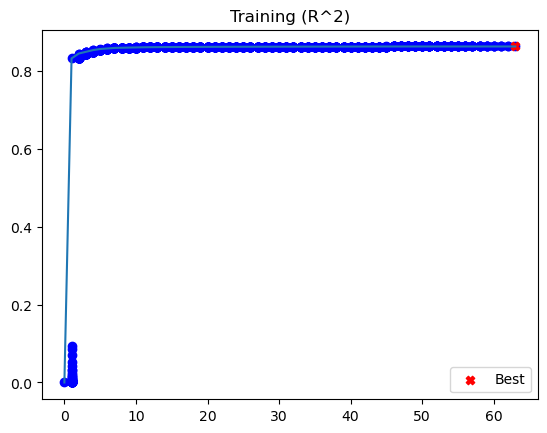

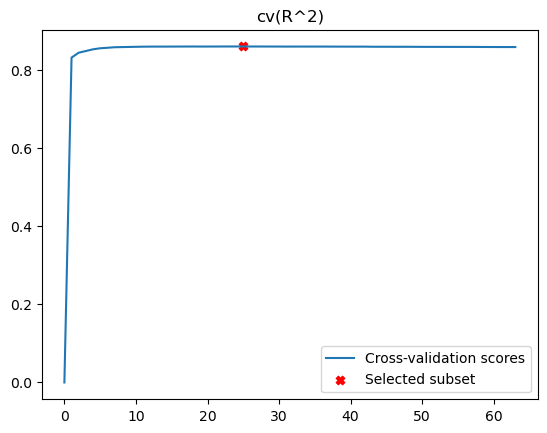

In [33]:
selected_features = forward_selection(X_train, y_train,
                    get_evaluator(make_scorer(r2_score)), np.argmax,
                    get_cv_evaluator(make_scorer(r2_score), cv=5), np.argmax, 
                    candidates_scorer_name="Training (R^2)",
                    subsets_scorer_name="cv(R^2)",
                    verbose=True, weight_step3=5)

In [34]:
# List of selected features using forward selection
print("Forward Feature Selection with CV selected features:")
print(*selected_features, sep="\n")

Forward Feature Selection with CV selected features:
BounceRates
Administrative
ProductRelated
VisitorType_Returning_Visitor
PageValues
TrafficType_2
OperatingSystems_2
VisitorType_Other
SpecialDay
TrafficType_4
Month_June
OperatingSystems_3
TrafficType_13
Month_Dec
Month_Jul
ProductRelated_Duration
TrafficType_3
Weekend_True
OperatingSystems_8
TrafficType_16
Region_7
OperatingSystems_6
TrafficType_19
Browser_4
TrafficType_9


### Generalized linear model
A common approach to increase the expressive power of a linear model is to transform the input features using non-linear functions. One highly effective method is to construct polynomial features from our original input variables.
For instance, by combining two features ($x_1, x_2$) into second-order polynomials, we can fit a multi-dimensional paraboloid to the data instead of a simple flat plane. Mathematically, this transformation maps the non-linear relationship into a linear space:

$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + w_3 x_1 x_2 + w_4 x_1^2 + w_5 x_2^2$

By defining new linear variables z, we can rewrite this as a standard multiple linear regression problem:

$\hat{y} = w_0 + w_1 z_1 + w_2 z_2 + w_3 z_3 + w_4 z_4 + w_5 z_5$

Since generating polynomial combinations exponentially increases the feature space, we used the most predictive features pre-select with Forward Feature Selection. In this way we significantly reduced the computational burden. <br>
We evaluated polynomial degrees from 1 to 4; including a degree of 1 allowed us to establish a baseline using standard linear regression on the selected feature subset.

Finally, we employ GridSearchCV to systematically tune our hyperparameters using cross-validation, ensuring our final model generalizes well without overfitting.

In [35]:
#Creating a subset with the selected features
X_train_subset = X_train[selected_features]
X_test_subset = X_test[selected_features]
print("X_train_subset dimension:", X_train_subset.shape)
print("X_test_subset dimension:", X_test_subset.shape)

X_train_subset dimension: (4526, 25)
X_test_subset dimension: (1940, 25)


In [36]:
# Generalized linear model pipeline
generalized_linear_model = Pipeline([('poly', PolynomialFeatures(degree=1, include_bias=False)),
                                     ('linear', LinearRegression(fit_intercept=True))])

# Polynomial degrees to test
parameters = {'poly__degree': list(range(1,5))}


generalized_linear_model_cv = GridSearchCV(generalized_linear_model, 
                                           parameters, 
                                           scoring=comparison_scoring, 
                                           cv=5, 
                                           refit="r2")
generalized_linear_model_cv.fit(X_train_subset, y_train)

# Print results
pd.DataFrame(generalized_linear_model_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly__degree,params,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,...,std_test_r2,rank_test_r2,split0_test_neg_mse,split1_test_neg_mse,split2_test_neg_mse,split3_test_neg_mse,split4_test_neg_mse,mean_test_neg_mse,std_test_neg_mse,rank_test_neg_mse
0,0.003179,0.000413,0.000854,0.000066,1,{'poly__degree': 1},0.836587,0.878634,0.853129,0.864235,...,0.014013,1,-0.000397,-0.000280,-0.000321,-0.000307,-0.000308,-0.000323,0.000039,1
1,0.047769,0.003395,0.001994,0.000093,2,{'poly__degree': 2},0.769782,0.873370,0.770915,0.657486,...,0.069938,2,-0.000559,-0.000293,-0.000501,-0.000775,-0.000615,-0.000548,0.000157,2
2,10.821154,0.461849,0.025425,0.003348,3,{'poly__degree': 3},-1938.811243,-8.656846,-2.230223,-4.936411,...,773.812186,4,-4.709744,-0.022311,-0.007066,-0.013430,-0.005338,-0.951578,1.879093,4
3,32.840007,2.649256,0.106292,0.012759,4,{'poly__degree': 4},-36.678090,-5.045164,-4.895369,-21.689154,...,12.218849,3,-0.091480,-0.013967,-0.012895,-0.051328,-0.023577,-0.038649,0.029838,3


In [37]:
# Retrieve the best trained estimator
best_model = generalized_linear_model_cv.best_estimator_

# Retrieve its parameters
best_params = generalized_linear_model_cv.best_params_

# Retrieve the best CV score
best_cv_score_r2 = generalized_linear_model_cv.best_score_

# Retrieve the best MSE score
best_subset_cv_mse = -generalized_linear_model_cv.cv_results_[
    "mean_test_neg_mse"
][generalized_linear_model_cv.best_index_]

print("Best trained estimator:")
print(best_model)

print("\nBest parameters:")
print(best_params)

print("\nBest mean CV R2 score:")
print(best_cv_score_r2)


print("\nBest mean CV MSE:")
print(best_subset_cv_mse)

Best trained estimator:
Pipeline(steps=[('poly', PolynomialFeatures(degree=1, include_bias=False)),
                ('linear', LinearRegression())])

Best parameters:
{'poly__degree': 1}

Best mean CV R2 score:
0.8594686414274599

Best mean CV MSE:
0.00032277700839616246


Cross-validation selected polynomial degree 1. Therefore, the polynomial expansion did not improve over a standard linear model on the selected features. Degrees 2, 3, and 4 produced considerably worse validation scores, with strongly negative scores for the higher degrees. This behavior is consistent with overfitting and numerical instability caused by the rapid increase in the number of polynomial features.

### LASSO
LASSO is a linear regression technique that introduces a penalty to prevent overfitting and perform automatic feature selection.
Unlike standard Ordinary Least Squares (OLS) regression, LASSO adds a penalty proportional to the absolute values of the model's coefficients.

__KEY PROPERTIES__:
- __Feature Selection__: it forces the coefficients of less important variables to become exactly zero. This automatically removes irrelevant features from the model.
- __Interpretability__: By producing a sparse model (fewer non-zero coefficients), LASSO creates simpler, more interpretable models
- __Handling Multicollinearity__: When features are highly correlated, LASSO tends to pick one representative feature from the group and set the others to zero.

Because LASSO relies on the absolute magnitude of the coefficients, it is critical to scale the features before training the model so that variables with larger raw scales aren't unfairly penalized. For this reason, we will use the previously defined preprocessor.

LASSO uses a parameter $ \lambda $ (for the purpose of the code, we will call it alpha) that controls the strength of the penalty:

$$
\text{Loss} = \text{Data Loss} + \lambda \|\beta\|_1
$$

- large $ \lambda $ → strong regularization → more coefficients shrink to zero  
- small $ \lambda $ → weak regularization → less shrinkage  

We employed GridSearchCV to find the best hyperparameter


In [38]:
#Lasso pipeline
lasso_model = Pipeline([("preprocessor", preprocessor),
                        ("regressor", Lasso(max_iter=100000, random_state=42))])

In [39]:
#Lasso parameters
lasso_parameters = {"regressor__alpha": np.logspace(-7, -3, 40)}

#Grid search for Lasso regression
lasso_cv = GridSearchCV(estimator=lasso_model, param_grid=lasso_parameters, scoring={"r2": r2_scorer, "neg_mse": mse_scorer}, refit="r2", cv=5, return_train_score=True)

In [40]:
#fitting the model on the training set
lasso_cv.fit(X_train, y_train)

# Retrieving best LASSO model and CV results
best_lasso_model = lasso_cv.best_estimator_
best_lasso_alpha = lasso_cv.best_params_["regressor__alpha"]
best_lasso_cv_r2 = lasso_cv.best_score_
best_lasso_cv_mse = -lasso_cv.cv_results_["mean_test_neg_mse"][lasso_cv.best_index_]

print("Best LASSO alpha:", best_lasso_alpha)
print("Best LASSO mean CV R2:", best_lasso_cv_r2)
print("Best LASSO mean CV MSE:", best_lasso_cv_mse)

Best LASSO alpha: 3.665241237079626e-05
Best LASSO mean CV R2: 0.8587909597420363
Best LASSO mean CV MSE: 0.00032432456268925074


In [41]:
# LASSO feature selection

lasso_feature_names = (Numerical_features + [c for c in X_train.columns if c not in Numerical_features])

lasso_coefficients = best_lasso_model.named_steps["regressor"].coef_

lasso_coef_table = pd.DataFrame({
    "Feature": lasso_feature_names,
    "Coefficient": lasso_coefficients,
    "Abs coefficient": np.abs(lasso_coefficients)
}).sort_values("Abs coefficient", ascending=False)

# Features with coefficient different from zero are selected by LASSO
selected_lasso_features = lasso_coef_table[lasso_coef_table["Abs coefficient"] > 1e-8]

print("Number of selected features:", len(selected_lasso_features))
display(selected_lasso_features)

Number of selected features: 35


,Feature,Coefficient,Abs coefficient
6,BounceRates,0.041067,0.041067
61,VisitorType_Returning_Visitor,0.007233,0.007233
4,ProductRelated,-0.005043,0.005043
60,VisitorType_Other,0.004658,0.004658
12,Month_June,0.004358,0.004358
42,TrafficType_2,-0.003757,0.003757
0,Administrative,-0.003029,0.003029
18,OperatingSystems_2,0.002600,0.002600
44,TrafficType_4,-0.002525,0.002525
7,PageValues,-0.002499,0.002499


### Ridge
Ridge regression is is a linear regression technique designed to prevent overfitting by penalizing the magnitude of the model's coefficients by adding a penalty proportional to the squared values of the coefficients.

__KEY PROPERTIES__
- __Coefficient Shrinkage__ (No Sparsity): The penalty shrinks the weights of less important features close to zero, but never sets them to exactly zero. Consequently, Ridge keeps all predictors in the model.
- __Handling Multicollinearity__
- __Computational Efficiency__: Unlike LASSO, the Ridge loss function is fully differentiable everywhere, which allows for a closed-form analytical solution that is computationally very efficient to solve.

Like LASSO, Ridge regression is highly sensitive to the scale of input variables. For this reason, we will use the previously defined preprocessor.

Like with LASSO, we employed GridSearchCV to find the best hyperparameter


In [42]:
#Ridge model pipeline
ridge_model = Pipeline([("preprocessor", preprocessor),("regressor", Ridge())])

In [43]:
#Ridge parameters
ridge_parameters = {"regressor__alpha": np.logspace(-7, 4, 60)}

#Grid search for Ridge regression
ridge_cv = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_parameters,
    scoring={
        "r2": r2_scorer,
        "neg_mse": mse_scorer},
    refit="r2",
    cv=5,
    return_train_score=True)

In [44]:
#fitting the model on the training set
ridge_cv.fit(X_train, y_train)

#Retrieving best RIDGE model and CV results
best_ridge_model = ridge_cv.best_estimator_
best_ridge_alpha = ridge_cv.best_params_["regressor__alpha"]
best_ridge_cv_r2 = ridge_cv.best_score_
best_ridge_cv_mse = -ridge_cv.cv_results_["mean_test_neg_mse"][ridge_cv.best_index_]

print("Best RIDGE alpha:", best_ridge_alpha)
print("Best RIDGE mean CV R2:", best_ridge_cv_r2)
print("Best RIDGE mean CV MSE:", best_ridge_cv_mse)

Best RIDGE alpha: 24.537511066398167
Best RIDGE mean CV R2: 0.8587458367613834
Best RIDGE mean CV MSE: 0.00032442957023723514


In [45]:
# RIDGE coefficients

ridge_feature_names = (Numerical_features + [c for c in X_train.columns if c not in Numerical_features])

ridge_coefficients = best_ridge_model.named_steps["regressor"].coef_

ridge_coef_table = pd.DataFrame({
    "Feature": ridge_feature_names,
    "Coefficient": ridge_coefficients,
    "Abs coefficient": np.abs(ridge_coefficients)
}).sort_values("Abs coefficient", ascending=False)

display(ridge_coef_table)

,Feature,Coefficient,Abs coefficient
6,BounceRates,0.040786,0.040786
61,VisitorType_Returning_Visitor,0.007188,0.007188
60,VisitorType_Other,0.005913,0.005913
4,ProductRelated,-0.005241,0.005241
12,Month_June,0.004575,0.004575
...,...,...,...
20,OperatingSystems_4,-0.000087,0.000087
2,Informational,-0.000066,0.000066
45,TrafficType_5,0.000061,0.000061
51,TrafficType_11,-0.000042,0.000042


## Models comparison
At this point we compared our models based on the cross-validation $R^2$ and MSE scores.

In [46]:
candidate_models = {
    "Linear Regression on full feature set": {
        "model": linear_model,
        "features": list(X_train.columns),
        "mean_cv_r2": linear_full_cv_r2,
        "mean_cv_mse": linear_full_cv_mse,
        "hyperparameters": "None"},

    "Linear Regression on selected features": {
        "model": best_model,
        "features": selected_features,
        "mean_cv_r2": best_cv_score_r2,
        "mean_cv_mse": best_subset_cv_mse,
        "hyperparameters": f"degree={best_params['poly__degree']}"
    },

    "LASSO Regression": {
        "model": best_lasso_model,
        "features": selected_lasso_features,
        "mean_cv_r2": best_lasso_cv_r2,
        "mean_cv_mse": best_lasso_cv_mse,
        "hyperparameters": f"alpha={best_lasso_alpha:.6g}"
    },

    "Ridge Regression": {
        "model": best_ridge_model,
        "features": list(X_train.columns),
        "mean_cv_r2": best_ridge_cv_r2,
        "mean_cv_mse": best_ridge_cv_mse,
        "hyperparameters": f"alpha={best_ridge_alpha:.6g}"}}

results = []

for name, configuration in candidate_models.items():
    results.append({
        "Model": name,
        "Number of features": len(configuration["features"]),
        "Hyperparameters": configuration["hyperparameters"],
        "Mean CV R2": configuration["mean_cv_r2"],
        "Mean CV MSE": configuration["mean_cv_mse"],
    })

comparison_results = (
    pd.DataFrame(results)
    .sort_values(
        by=["Mean CV R2", "Mean CV MSE"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(comparison_results)

,Model,Number of features,Hyperparameters,Mean CV R2,Mean CV MSE
0,Linear Regression on selected features,25,degree=1,0.859469,0.000323
1,LASSO Regression,35,alpha=3.66524e-05,0.858791,0.000324
2,Ridge Regression,63,alpha=24.5375,0.858746,0.000324
3,Linear Regression on full feature set,63,None,0.857998,0.000326


The linear regression model fitted on the forward-selected feature subset achieved the highest cross validation R² and the lowest MSE. However, its performance was very close to that of Ridge and LASSO regression. We therefore do not claim a substantial predictive advantage. We select the subset model because it combines slightly better predictive performance with a smaller and more interpretable set of features. 

At this point, we evaluate the selected model on the internal test set.

The selected model is then retrained on all training observations with known ExitRates before imputing the missing values.

In [47]:
# Model testing on the internal test set.
# The model was trained only on the selected features,
# so the same subset must also be used during prediction.
y_predict = best_model.predict(X_test_subset)
print("Test R2 score ", r2_score(y_test, y_predict))
print("Test MSE score ", mean_squared_error(y_test, y_predict))


Test R2 score  0.8658211272624681
Test MSE score  0.0003185645107782122


# Request 2

Use the regression model trained at the previous step to recover the Exit
Rate by predicting its value for each missing sample on the train and test
set. 
- Build a classification model to predict whether an online shopper is
likely to make a purchase 
- Perform feature selection
- Compare different algorithms and identify the one that works the best on this dataset. 
- Test the best algorithm’s performance on the provided test set.
- Determine whether a model built using the Exit Rate information is better than a
model built using the remaining features.

In [48]:
#extablishing the ExitRates value range
ER_min = y_train.min()
ER_max = y_train.max()
print("Minimum ExitRates value:", ER_min)
print("Maximum ExitRates value:", ER_max)

Minimum ExitRates value: 0.0
Maximum ExitRates value: 0.2


In [49]:
#Load test set
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")
test_data = test_data.drop(test_data.columns[0], axis=1)

In [50]:
# Identify rows with missing ExitRates
missing_ER_train = train_data["ExitRates"].isna()
missing_ER_test = test_data["ExitRates"].isna()

In [51]:
# Encode all predictors in the complete train and test sets
X_train_complete = pd.get_dummies(train_data[features], columns=categorical_features, drop_first=True, dtype=float)
X_test_complete = pd.get_dummies(test_data[features], columns=categorical_features, drop_first=True, dtype=float)

X_train_complete.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,PageValues,SpecialDay,Month_Dec,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.000000,0.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,7,87.916667,1,0.0,46,1621.025379,0.004082,6.023523,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,4.000000,0,0.0,37,1296.942857,0.013889,0.000000,0.8,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,132.400000,0,0.0,11,296.300000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
# Keep the features selected with Forward Feature Selection with cross validation
X_train_complete = X_train_complete.reindex(columns=selected_features,fill_value=0)

X_test_complete = X_test_complete.reindex(columns=selected_features, fill_value=0)

In [53]:
# Train the selected model again using all rows for which ExitRates is known
final_model = clone(best_model)

final_model.fit(
    X_train_complete.loc[~missing_ER_train],
    train_data.loc[~missing_ER_train, "ExitRates"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('linear', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [54]:
# Predict the missing ExitRates values
train_predictions = final_model.predict(X_train_complete.loc[missing_ER_train])
test_predictions = final_model.predict(X_test_complete.loc[missing_ER_test])

In [55]:
# ExitRates must be between 0 and 0.2
train_predictions = np.clip(train_predictions, 0, 0.2)
test_predictions = np.clip(test_predictions, 0, 0.2)

In [56]:
# Insert the predictions into the datasets
train_data.loc[missing_ER_train, "ExitRates"] = train_predictions
test_data.loc[missing_ER_test, "ExitRates"] = test_predictions

print("Missing ExitRates in train:", train_data["ExitRates"].isna().sum())
print("Missing ExitRates in test:", test_data["ExitRates"].isna().sum())

Missing ExitRates in train: 0
Missing ExitRates in test: 0


In [57]:
train_data.to_csv(
    "training_set_online_shoppers_intention_imputed.csv",
    index=False)

test_data.to_csv(
    "test_set_online_shoppers_intention_imputed.csv",
    index=False)

## Load Data
We load the training and test sets obtained from the previous preprocessing and imputation stage. In that stage, the corrupted values of the `ExitRates` feature were restored using a predictive regression model to prevent biased evaluations. 

We inspect the first few rows of the training dataset to ensure the integrity of the data and verify that all features are loaded correctly.

In [58]:
train_data = pd.read_csv("training_set_online_shoppers_intention_imputed.csv")
test_data = pd.read_csv("test_set_online_shoppers_intention_imputed.csv")
train_data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,0.041911,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,0.018802,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9243,10,130.550000,1,23.2,7,128.233333,0.006667,0.015238,0.000000,0.0,Oct,2,2,6,5,New_Visitor,False,False
9244,14,260.736111,3,186.5,51,2921.902778,0.013661,0.029891,8.339172,0.0,Nov,4,2,7,1,Returning_Visitor,True,True
9245,7,109.500000,0,0.0,25,349.696970,0.000000,0.019048,0.000000,0.0,Oct,1,1,1,2,Returning_Visitor,False,False
9246,4,82.700000,0,0.0,26,405.283333,0.000000,0.014602,0.000000,0.0,Nov,2,2,1,2,New_Visitor,False,False


In [59]:
train_data.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [60]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9248 entries, 0 to 9247
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9248 non-null   int64  
 1   Administrative_Duration  9248 non-null   float64
 2   Informational            9248 non-null   int64  
 3   Informational_Duration   9248 non-null   float64
 4   ProductRelated           9248 non-null   int64  
 5   ProductRelated_Duration  9248 non-null   float64
 6   BounceRates              9248 non-null   float64
 7   ExitRates                9248 non-null   float64
 8   PageValues               9248 non-null   float64
 9   SpecialDay               9248 non-null   float64
 10  Month                    9248 non-null   object 
 11  OperatingSystems         9248 non-null   int64  
 12  Browser                  9248 non-null   int64  
 13  Region                   9248 non-null   int64  
 14  TrafficType             

## Feature-Target Separation and Label Conversion

To prepare the dataset for our classification models, we separate the predictor features ($X$) from the target label ($y$, representing the `Revenue` variable), ensuring that it doesn't contain NA values.

In [61]:
Categorical_columns = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend'] #revenue exluded because it is the target variable
Numerical_columns = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration','ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

ER_known = train_data[train_data["ExitRates"].notna()]
ER_known.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9248 entries, 0 to 9247
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9248 non-null   int64  
 1   Administrative_Duration  9248 non-null   float64
 2   Informational            9248 non-null   int64  
 3   Informational_Duration   9248 non-null   float64
 4   ProductRelated           9248 non-null   int64  
 5   ProductRelated_Duration  9248 non-null   float64
 6   BounceRates              9248 non-null   float64
 7   ExitRates                9248 non-null   float64
 8   PageValues               9248 non-null   float64
 9   SpecialDay               9248 non-null   float64
 10  Month                    9248 non-null   object 
 11  OperatingSystems         9248 non-null   int64  
 12  Browser                  9248 non-null   int64  
 13  Region                   9248 non-null   int64  
 14  TrafficType             

As said before, in order to encode the categorical featues we chose the one-hot encoding approach, which allow us to not introduce any further structure on our data. After that, we remove the constant and duplicated columns that can unbalance the entire dataset.

In [62]:
#Create dummy variables: ER_known is the train_data with known ExitRates, test_data is the test set
categorical_cols = [c for c in Categorical_columns if c in ER_known.columns]
ER_known = pd.get_dummies(ER_known, columns=categorical_cols, drop_first=True, dtype=float)
test_data = pd.get_dummies(test_data, columns=categorical_cols, drop_first=True, dtype=float)
ER_known.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,4.000000,0,0.0,37,1296.942857,0.013889,0.041911,0.000000,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,132.400000,0,0.0,11,296.300000,0.000000,0.018802,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
#Cleaning the design matrix
#1. Remove constant columns
constant_cols = ER_known.columns[ER_known.nunique(dropna=False) <= 1]
ER_known = ER_known.drop(columns=constant_cols)

#2. Remove duplicated columns
duplicate_cols = ER_known.columns[ER_known.T.duplicated()]
ER_known = ER_known.drop(columns=duplicate_cols)

ER_known.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9248 entries, 0 to 9247
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 9248 non-null   int64  
 1   Administrative_Duration        9248 non-null   float64
 2   Informational                  9248 non-null   int64  
 3   Informational_Duration         9248 non-null   float64
 4   ProductRelated                 9248 non-null   int64  
 5   ProductRelated_Duration        9248 non-null   float64
 6   BounceRates                    9248 non-null   float64
 7   ExitRates                      9248 non-null   float64
 8   PageValues                     9248 non-null   float64
 9   SpecialDay                     9248 non-null   float64
 10  Revenue                        9248 non-null   bool   
 11  Month_Dec                      9248 non-null   float64
 12  Month_Feb                      9248 non-null   f

## Note: Exclusion of Single-Feature Regression Models

We explicitly excluded single-feature regression models (linear and logistic) from the classification pipeline for the following theoretical and practical reasons:

1. **Inadequacy of Linear Regression for Binary Classification:** The target variable `Revenue` is strictly binary ($Y \in \{0, 1\}$). Linear Regression assumes a continuous target and can output uninterpretable values outside the $[0, 1]$ range. It lacks a probabilistic mapping function (such as the sigmoid link function in Logistic Regression), making it mathematically unsuited for a classification task.

2. **Insufficiency of Single-Feature Predictors:** Online purchasing behavior is driven by complex, multi-dimensional interactions between user engagement, time constraints, and temporal factors (e.g., `PageValues`, `ExitRates`, and `ProductRelated_Duration`). A single-feature model cannot capture enough variance to separate the classes, leading to severe underfitting.

3. **Class Imbalance Vulnerability:** Given the high imbalance of the `Revenue` target (where `False` samples heavily outnumber `True` samples) - as seen in the prevous exploratory analysis -, a single-feature linear classifier lacks the mathematical complexity to establish a robust decision boundary. It would trivially default to predicting the majority class (`False`) for all observations, yielding an F1-Score of 0.


<a id="logistic-regression"></a>

## Classification with Multiple Logistic Regression

### Motivation and Theoretical Foundation

As said before, in supervised learning, traditional linear regression is ill-suited for binary classification tasks. Applying ordinary least squares (OLS) to a binary target can yield predicted values outside the strictly bounded $[0, 1]$ probability interval, and the resulting linear decision boundary is highly sensitive to unbalanced data and outliers. 

To address these limitations, we require a probabilistic framework that:
1. Constrains the model outputs to represent **valid posterior probabilities** $P(Y=1 \mid \mathbf{X}) \in [0, 1]$.
2. Formulates an mathematically sound decision rule for binary classification.

---

### The Logistic (Sigmoid) Function

Logistic regression achieves these requirements by applying a non-linear mapping—the logistic (or sigmoid) function—to a linear combination of the input features. For a single predictor $X$, the conditional probability of the positive class ($Y=1$, indicating `Revenue = True`) is formulated as:

$$
P(Y=1 \mid X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}
$$

By design, this curve asymptotically approaches $0$ as the linear predictor tends to $-\infty$, and approaches $1$ as it tends to $+\infty$. 

While the relationship between the raw predictor $X$ and the probability $P(Y=1 \mid X)$ is non-linear, the model remains **linear in its parameters** under the **logit transformation**. The logit function is defined as the logarithm of the odds ratio:

$$
\log\left( \frac{P(Y=1 \mid X)}{1 - P(Y=1 \mid X)} \right) = \beta_0 + \beta_1 X
$$

Thus, logistic regression models the **log-odds** of the target event as a linear function of the input space.

---

### Generalization to Multiple Logistic Regression

A single-feature model is inherently limited: it cannot capture complex, multi-dimensional decision boundaries, nor can it account for joint feature interactions or potential confounding variables present in the *Online Shoppers Purchasing Intention* dataset. 

To leverage the rich set of behavioral and temporal features at our disposal, we extend the framework to a **Multiple Logistic Regression** model. Given a vector of $p$ predictors $\mathbf{X} = (X_1, X_2, \dots, X_p)$, the logit model generalizes to:

$$
\log\left( \frac{P(Y=1 \mid \mathbf{X})}{1 - P(Y=1 \mid \mathbf{X}} \right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p
$$

Under this formulation, each coefficient $\beta_j$ represents the expected change in the log-odds of making a purchase ($Y=1$) per unit increase in the feature $X_j$, holding all other predictors constant. By exponentiating the coefficient ($e^{\beta_j}$), we obtain the **Odds Ratio (OR)**, which provides an intuitive, multiplicative measure of the effect size of each feature.

Since our target variable `Revenue` is binary, the mapped output of this multiple linear combination represents the estimated probability $\hat{p}$ that a given browsing session will culminate in a purchase.

---

### Parameter Estimation via Maximum Likelihood (MLE)

Unlike linear regression, which admits a closed-form analytical solution via OLS, the parameter vector $\boldsymbol{\beta} = (\beta_0, \beta_1, \dots, \beta_p)$ in logistic regression must be estimated numerically. 

Assuming that the binary outcomes $y_i$ are independent realizations of a Bernoulli trial, we employ **Maximum Likelihood Estimation (MLE)**. The objective of MLE is to find the parameter estimates that maximize the likelihood function that describe the probability of observing the actual training labels given the predictors. In practice, the method tries to minimize the negative log-likelihood using iterative optimization algorithms.

In [64]:
# Train a logistic regression model using multiple features

#reminder: we excluded the target variable 'Revenue' from the features
feature_names = [c for c in ER_known.columns if c not in ["Revenue"]]

#create missing columns in test_data that are present in ER_known
for col in feature_names:
    if col not in test_data.columns:
        test_data[col] = 0.0

#extract train and test data
X_full_train = ER_known[feature_names].astype(np.float32)
y_train = ER_known['Revenue'].astype(np.float32)

X_full_test = test_data[feature_names].astype(np.float32)
y_test = test_data['Revenue'].astype(np.float32)

#compare the dimensions
X_full_train.shape, X_full_test.shape, y_train.shape, y_test.shape

((9248, 66), (3082, 66), (9248,), (3082,))

### Accuracy: a not-valid metrics

At this point we created the first model. The Multiple Logistic Regression Model, and we trained on the train set. After the training we tested, only with an explorative goal, on the test set. For this model and all the other, the measure of the accuracy can't be considered as a solid value. 

Accuracy is not a particularly meaningful metric in this context because the class distribution is highly imbalanced. A model that always predicts the majority class could achieve a high accuracy while failing to correctly identify the minority class, which is the class of greatest interest. For this reason, the comparison of the models is based primarily on metrics that account for the trade-off between false positives and false negatives, such as the F1-score, precision, and recall.

In [65]:
#create and fit the model
model_log_full = LogisticRegression(solver="lbfgs", penalty=None, max_iter=1000)
model_log_full.fit(X_full_train, y_train)

/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

Although accuracy is not considered a reliable metric for comparing model performance due to the highly imbalanced class distribution, it is still reported to have an idea of the model’s performance between the training and test sets. Similar accuracy values across the two datasets provide an indication that the model generalizes well and is not substantially overfitting, whereas large discrepancies may suggest overfitting or poor generalization.

In [66]:
# Predictions
y_pred_train = model_log_full.predict(X_full_train)
y_pred_test = model_log_full.predict(X_full_test)

#calculate accuracy
print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))

Train accuracy: 0.8820285467128027
Test accuracy: 0.8887086307592472


### Hypothesis Testing for Coefficients: The Z-Test

After estimating the parameters $\boldsymbol{\beta}$ via Maximum Likelihood Estimation (MLE), we perform a **Wald $z$-test** on each coefficient $\beta_j$ to evaluate its individual statistical significance. This determines whether the association between a predictor $X_j$ and the target variable (`Revenue`) is statistically meaningful or merely due to random variation.

For each coefficient, we set up the following hypotheses:
* **Null Hypothesis ($H_0$):** $\beta_j = 0$  
    *(The predictor $X_j$ has no linear effect on the log-odds of the target, holding all other variables constant).*
* **Alternative Hypothesis ($H_1$):** $\beta_j \neq 0$  
    *(The predictor $X_j$ has a statistically significant effect on the log-odds of the target).*

Under $H_0$, the test statistic $z$ asymptotically follows a Standard Normal distribution:

$$
z = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} \sim N(0, 1)
$$

Where $\hat{\beta}_j$ is the estimated coefficient and $\text{SE}(\hat{\beta}_j)$ is its standard error. If the resulting $p$-value is lower than the significance level $\alpha$ (typically $0.05$), we reject $H_0$ and conclude that the feature $X_j$ is a significant predictor.

In [67]:
# describe a z-test logistic function
def z_test_logistic(X, y, model, feature_names, alpha=0.05):
    X_design = np.column_stack([np.ones(X.shape[0]), X])
    betas = np.concatenate([model.intercept_, model.coef_.ravel()])

    # Predicted probabilities for class 1
    p = model.predict_proba(X)[:, 1]

    # Diagonal weight matrix: p(1-p)
    V = np.diag(p * (1 - p))

    # Covariance matrix
    cov = np.linalg.inv(X_design.T @ V @ X_design)

    se = np.sqrt(np.diag(cov))
    z_stats = betas / se
    p_values = 2 * norm.sf(np.abs(z_stats))

    # Results table
    results = pd.DataFrame({
        "Name": ["Intercept"] + feature_names,
        "Coefficient": betas,
        "Std. Error": se,
        "Z-stat": z_stats,
        "p-value": p_values
    })

    results["Reject H0"] = results["p-value"] < alpha
    return results

In [68]:
z_test_logistic(
    X_full_train,
    y_train,
    model_log_full,
    feature_names=feature_names,
    alpha=0.005
)

,Name,Coefficient,Std. Error,Z-stat,p-value,Reject H0
0,Intercept,-2.006774,0.247750,-8.099995,5.496158e-16,True
1,Administrative,-0.009058,0.013206,-0.685857,4.928035e-01,False
2,Administrative_Duration,0.000240,0.000219,1.093073,2.743617e-01,False
3,Informational,0.049539,0.031710,1.562258,1.182271e-01,False
4,Informational_Duration,-0.000062,0.000264,-0.233278,8.155453e-01,False
...,...,...,...,...,...,...
62,TrafficType_19,-0.028074,1.165589,-0.024086,9.807843e-01,False
63,TrafficType_20,0.129531,0.326064,0.397258,6.911771e-01,False
64,VisitorType_Other,-0.214531,0.593349,-0.361560,7.176812e-01,False
65,VisitorType_Returning_Visitor,-0.531895,0.106216,-5.007676,5.509121e-07,True


## Feature Selection with LASSO

We perform feature selection to mitigate the risk of overfitting—addressing the curse of dimensionality—by eliminating redundant or non-informative variables. This process significantly enhances model interpretability, reduces computational complexity, and improves the model's generalization performance on unseen data. We choose LASSO (L1 regularization) for Logistic Regression as feature selection method instead of Forward Selection because:
1. It is computationally efficient and computationally cheaper, solving the selection problem in a single optimization step rather than iteratively training hundreds of sub-models.
2. It mathematically mitigates overfitting by shrinking the coefficients of non-informative variables strictly to zero.
3. It handles multicollinearity between browsing behavior features (e.g., Exit Rates and Bounce Rates) more robustly than greedy search algorithms like Forward Selection.

Recall: **L1 regularization (LASSO)** in logistic regression adds a penalty term to the loss function. 
The objectives:
- Fit the data well  
- Keep the model **simple** by penalizing large coefficients  

In **scikit-learn**, instead of $\lambda $, the parameter that controls the strength of the penalty, we use the parameter:
$$
C = \frac{1}{\lambda}
$$
Therefore:
- **small $ C $** → strong regularization → more sparsity  
- **large $ C $** → weak regularization → less sparsity  

/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

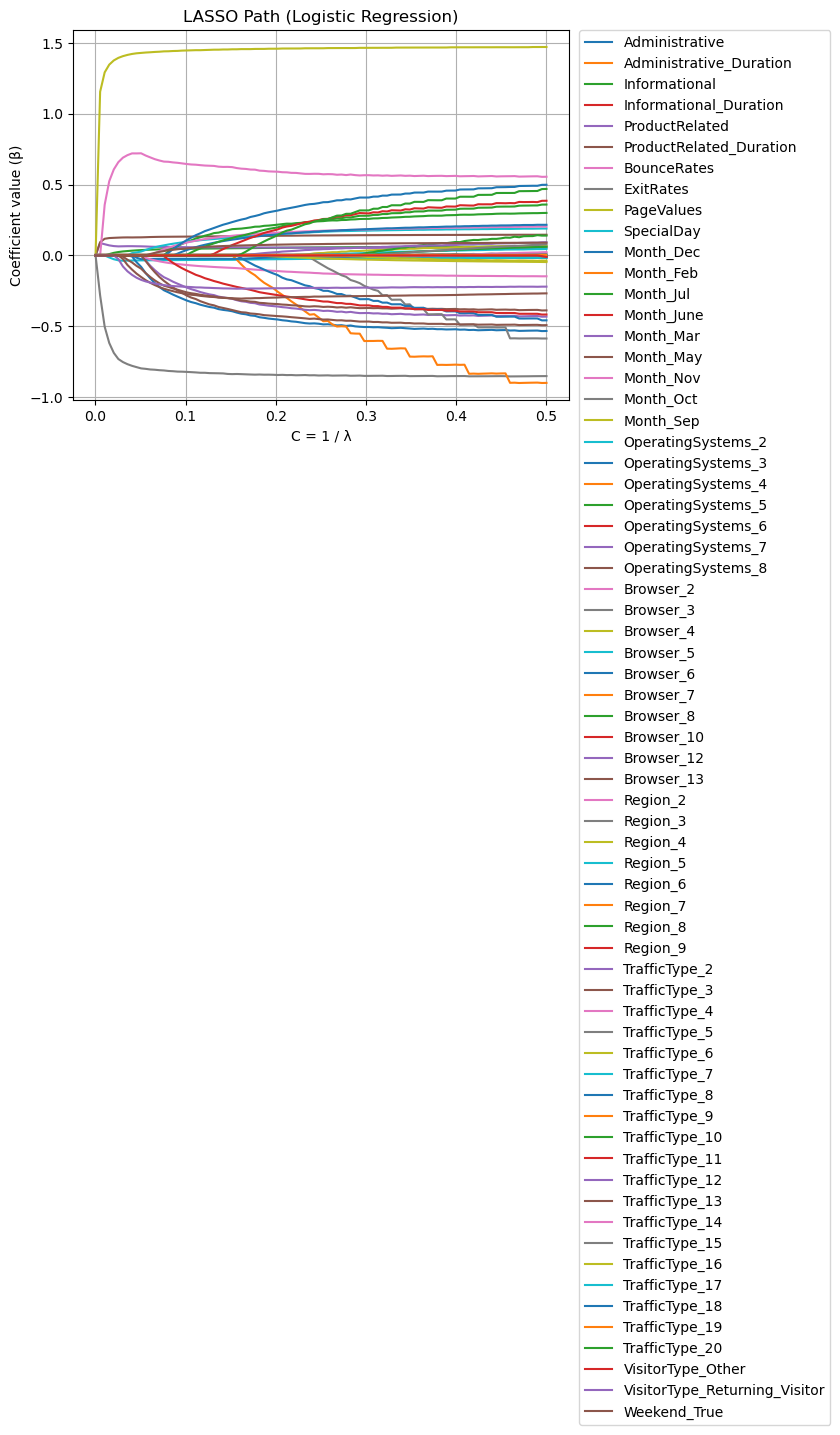

In [69]:
# LASSO path for Logistic Regression 
#we explored C values from 1*10^-4 to 1*10^0.5
C_vals = np.linspace(1e-4, 0.5, 100) 
betas = [] 

# Feature scaling (IMPORTANT for LASSO) 
# Without scaling, features with larger magnitude may dominate the penalty. 
Numerical_features = [c for c in Numerical_columns if c in X_full_train.columns] 
lasso_preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), Numerical_features)], 
    remainder="passthrough"
) 
X_processed = lasso_preprocessor.fit_transform(X_full_train)

# Train models for different C values 
for C in C_vals: 
    # Logistic regression with L1 penalty (LASSO) 
    # 'saga' solver is required for L1 regularization 
    model = LogisticRegression( 
        solver='saga', 
        penalty='l1', 
        C=C, 
        max_iter=4000,
        random_state=42 
    ) 
    model.fit(X_processed, y_train) 
    
    # Store coefficients (flatten to 1D) 
    beta = model.coef_.ravel() 
    betas.append(beta) 

# Convert list → array of shape [n_features, n_C_values] 
betas = np.stack(betas, axis=1) 

# Plot coefficient paths 
categorical_features = [c for c in X_full_train.columns if c not in Numerical_features]
lasso_feature_names_coerenti = Numerical_features + categorical_features

for beta, name in zip(betas, lasso_feature_names_coerenti): 
    plt.plot(C_vals, beta, label=name) 

plt.xlabel("C = 1 / λ") 
plt.ylabel("Coefficient value (β)") 
plt.title("LASSO Path (Logistic Regression)") 
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.) 
plt.grid(True) 
plt.show() 

After plotting the LASSO path for each feature in the Multiple Logistic Regression, we evaluated a model trained on the selected features, identified on the best possible C_values and number of features (55 - as reported below).

In [70]:
# preprocessing: standardize numerical features, pass through categorical features 
Numerical_features = [c for c in Numerical_columns if c in X_full_train.columns] 
lasso_preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), Numerical_features)], remainder="passthrough") 

#lasso pipeline for Logistic Regression with L1 penalty 
lasso_model = Pipeline([ 
("preprocessor", lasso_preprocessor), 
("regressor", LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000, random_state=42)) 
]) 

#lasso parameters 
lasso_parameters = {"regressor__C": np.logspace(-4, 2, 40)} 

#grid search with F1-score 
lasso_cv = GridSearchCV( 
estimator=lasso_model, 
param_grid=lasso_parameters, 
scoring="f1", 
cv=3, #cross validation with 3 folds
return_train_score=True 
) 

# Fitting the model to the training data 
lasso_cv.fit(X_full_train, y_train) 

#results 
best_lasso_model = lasso_cv.best_estimator_ 
best_lasso_C = lasso_cv.best_params_["regressor__C"] 
best_lasso_cv_f1 = lasso_cv.best_score_ 

print(f"Best C: {best_lasso_C}") 
print(f"Best F1-Score in Cross-Validation: {best_lasso_cv_f1:.4f}\n") 

#feature selection 
lasso_feature_names = lasso_feature_names_coerenti
lasso_coefficients = best_lasso_model.named_steps["regressor"].coef_[0] 

lasso_coef_table = pd.DataFrame({ 
"Feature": lasso_feature_names, 
"Coefficient": lasso_coefficients, 
"Abs coefficient": np.abs(lasso_coefficients) 
}).sort_values("Abs coefficient", ascending=False) 

selected_lasso_features_df = lasso_coef_table[lasso_coef_table["Abs coefficient"] > 1e-5] 
selected_feature_names = selected_lasso_features_df["Feature"].tolist() 

print(f"number of selected features: {len(selected_feature_names)}") 
display(selected_lasso_features_df)

/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and

Best C: 2.8942661247167516
Best F1-Score in Cross-Validation: 0.5025

number of selected features: 55


,Feature,Coefficient,Abs coefficient
11,Month_Feb,-1.632965,1.632965
27,Browser_3,-1.567707,1.567707
8,PageValues,1.481221,1.481221
57,TrafficType_15,-1.188087,1.188087
7,ExitRates,-0.889107,0.889107
62,TrafficType_20,0.728160,0.728160
30,Browser_6,-0.714773,0.714773
34,Browser_12,0.706873,0.706873
56,TrafficType_14,-0.696051,0.696051
50,TrafficType_8,0.606667,0.606667


As said before, for this model and for all the others below,  we keep as informative metrics the F1 Score cross-validated on multiple parameters setting. 

In [71]:
# BASELINE EVALUATION (ALL FEATURES)
# Define baseline model without L1 penalty restriction
baseline_model = Pipeline([
    ("preprocessor", lasso_preprocessor),
    ("regressor", LogisticRegression(penalty=None, max_iter=10000, random_state=42))
])

# Compute baseline F1-Score via 3-Fold Cross-Validation
baseline_cv_scores = cross_val_score(baseline_model, X_full_train, y_train, cv=3, scoring='f1')
baseline_mean_f1 = np.mean(baseline_cv_scores)

print(f"Baseline Mean CV F1-Score (All Features):  {baseline_mean_f1:.4f}")
print(f"LASSO Selected Mean CV F1-Score:           {best_lasso_cv_f1:.4f}")

Baseline Mean CV F1-Score (All Features):  0.5007
LASSO Selected Mean CV F1-Score:           0.5025


/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 

## Classification with Linear Discriminant Analysis (LDA)

### Theoretical Framework
While Multiple Logistic Regression is a **discriminative** classifier that directly models the posterior probability $P(Y=k \mid \mathbf{X})$ using the logistic link function, Linear Discriminant Analysis (LDA) adopts a **generative** approach. Instead of modeling the decision boundary directly, LDA models the distribution of the predictor variables $\mathbf{X}$ separately within each target class (the class-conditional density, $P(\mathbf{X} \mid Y=k)$), alongside the prior probability of each class ($P(Y=k)$). By estimating these individual distributions, we use **Bayes' theorem** to compute the posterior probability that a given observation $\mathbf{x}$ belongs to class $k$:

$$P(Y=k \mid \mathbf{X} = \mathbf{x}) = \frac{f_k(\mathbf{x}) \pi_k}{\sum_{l=1}^{K} f_l(\mathbf{x}) \pi_l}$$

Where:
* $\pi_k = P(Y=k)$ represents the **prior probability** of class $k$ (estimated as the proportion of training samples belonging to that class).
* $f_k(\mathbf{x}) = P(\mathbf{X} = \mathbf{x} \mid Y=k)$ is the **class-conditional density function** of the predictors.
* The denominator acts as a normalizing constant representing the marginal probability of the data.

---

### Model Assumptions
To make the estimation of $f_k(\mathbf{x})$ mathematically tractable, LDA introduces two strict structural assumptions:
1.  **Multivariate Normality:** Within each class $k$, the joint distribution of the continuous predictors is assumed to follow a multivariate Gaussian (Normal) distribution.
2.  **Homoscedasticity (Shared Covariance):** All classes are assumed to share a common covariance matrix ($\boldsymbol{\Sigma}$). This implies that while each class is centered around a different mean vector (representing different prototypes), the overall shape, dispersion, and correlation structure of the features remain identical across all classes.

---

### Critical Reflection on Assumption Violations in our Dataset
Our Exploratory Data Analysis indicates that the core assumptions of LDA are violated in our dataset:
* The continuous features exhibit high skewness, violating **multivariate normality**.
* The presence of categorical dummy variables contradicts the assumption of continuous Gaussian predictors.
* Class variances are visibly asymmetric, violating the **homoscedasticity** assumption.

Despite these violations, we proceed with training the LDA model for three key methodological reasons:
1.  **Baseline Benchmark:** LDA is historically robust to moderate violations of normality and homoscedasticity, serving as an essential linear baseline classifier.
2.  **Model Comparison:** Comparing LDA against Quadratic Discriminant Analysis (QDA)—which relaxes the shared covariance assumption—allows us to test whether modeling class-specific variances justifies the additional parameter estimation and risk of overfitting.
3.  **Comparison with Logistic Regression:** Comparing LDA to Logistic Regression helps us analyze how a generative classifier handles these data anomalies compared to a purely discriminative approach.

In [72]:
# Initialize the model
lda = LDA(solver='lsqr')

# Fit the model on training dataset
lda.fit(X_full_train, y_train)

# Predictions
y_train_pred = lda.predict(X_full_train)
y_test_pred = lda.predict(X_full_test)

def accuracy(y_true, y_pred):
    return (y_pred == y_true).mean()

# Evaluate
print("Train accuracy:", accuracy(y_train, y_train_pred))
print("Test accuracy:", accuracy(y_test, y_test_pred))

Train accuracy: 0.8799740484429066
Test accuracy: 0.8854639844256976


In [73]:
# LDA CROSS-VALIDATION F1-SCORE
# Define the LDA pipeline (using the same preprocessor as LASSO)
lda_pipeline = Pipeline([("preprocessor", lasso_preprocessor),("regressor", LDA())])

# Compute 3-Fold CV F1-scores
lda_cv_scores = cross_val_score(lda_pipeline, X_full_train, y_train, cv=3, scoring='f1')
lda_mean_f1 = np.mean(lda_cv_scores)

print(f"LDA Mean CV F1-Score: {lda_mean_f1:.4f}")

LDA Mean CV F1-Score: 0.4661


## Classification with Quadratic Discriminant Analysis

We introduce Quadratic Discriminant Analysis (QDA) as a more flexible parametric alternative to LDA. Like LDA, QDA models the distribution of the predictors $X$ for each class $Y$ and applies Bayes' theorem to perform classification. However, QDA relaxes one crucial restriction: it allows each class to have its own **distinct covariance matrix**. This enables the model to capture more complex, non-linear relationships and separates the classes using a **quadratic decision boundary** rather than a rigid linear one.

---
### Advantages:
* **Non-Linear Flexibility:** By estimating individual covariance matrices for each class, QDA can easily model curved or non-linear decision boundaries, leading to better fit when the underlying geometry of the data is complex.
* **Relaxed Assumptions:** It does not require homoscedasticity (equal variance/covariance across all classes), making it mathematically sound even when different groups exhibit completely different internal variances.
* **Strong Performance on Large Datasets:** When the sample size ($n$) is sufficiently large, QDA tends to outperform LDA because the variance introduced by estimating more parameters is mitigated by the abundance of data.
---
### Disadvantages & Assumptions:
* **High Parameter Count (Risk of Overfitting):** Because QDA estimates a separate covariance matrix for each class, the number of parameters grows quadratically with the number of features. On small datasets, this drastically increases the variance of the model and can lead to severe overfitting.
* **Distributional Assumptions:** Like LDA, QDA still assumes that the features within each class follow a multivariate normal distribution.
* **Sensitivity to Rare Classes:** If a specific class has very few observations, it becomes impossible to accurately estimate its unique covariance matrix, leading to unstable predictions.

In [74]:
# Initialize QDA
qda = QDA(store_covariance=True, reg_param=0.01)  # reg_param to avoid singular covariance

# Fit the model
qda.fit(X_full_train, y_train)

# Predictions
y_train_pred = qda.predict(X_full_train)
y_test_pred = qda.predict(X_full_test)

# Accuracy
print("Train accuracy:", accuracy(y_train, y_train_pred))
print("Test accuracy:", accuracy(y_test, y_test_pred))

Train accuracy: 0.8001730103806228
Test accuracy: 0.799480856586632


In [75]:
#from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
#from sklearn.model_selection import cross_val_score
#import numpy as np

# QDA EVALUATION (WITH CROSS-VALIDATION)

# Define QDA pipeline using the same preprocessor
#qda_pipeline = Pipeline([("preprocessor", lasso_preprocessor), ("regressor", QuadraticDiscriminantAnalysis())])

# Compute QDA F1-Score via Stratified 3-Fold Cross-Validation
#qda_cv_scores = cross_val_score(qda_pipeline, X_full_train, y_train, cv=3, scoring='f1')
#qda_mean_f1 = np.mean(qda_cv_scores)

#print(f"QDA Mean CV F1-Score: {qda_mean_f1:.4f}")

### Methodological Exclusion of Quadratic Discriminant Analysis (QDA)

We deliberately decided to exclude Quadratic Discriminant Analysis (QDA) from the final model F1-score evaluation due to structural limitations of the algorithm on this specific dataset:

1. **Strict Collinearity and Singularity:** Due to the severe class imbalance of the target variable (`Revenue`), partitioning the data to estimate a separate covariance matrix for the purchasing class (`Class 1.0`) isolates groups with zero variance or perfect multicollinearity among sparse one-hot encoded dummy variables. This triggers a fatal mathematical error (`LinAlgError: covariance matrix is not full rank`), as the matrix cannot be inverted.
2. **High Dimensional Space:** QDA requires estimating a number of parameters that grows quadratically with the number of features ($O(p^2)$). Given our high-dimensional space generated by categorical encodings, QDA suffers heavily from the curse of dimensionality, leading to extreme numerical instability.
3. **Violation of Distributional Assumptions:** QDA strictly assumes multivariate normality. The binary, sparse nature of our dummy variables fundamentally contradicts this assumption.

Consequently, attempting to force QDA convergence via heavy regularization would distort the model to the point of rendering its F1-score meaningless. We therefore proceed by evaluating only robust alternative classifiers (such as Logistic Regression, LASSO, and LDA).

---

### IMPORTANT NOTE: Methodological choice about Feature Selection in LDA and QDA

Due to the foundamental contraddictions of the basics assumptions and due to the structural limitations of the algorithms on our dataset, we consciously decided to avoid a feature selection step in this couple of model (LDA and QDA).

---

## Classification with K-Nearest Neighbors

We implement K-Nearest Neighbors (KNN) as a non-parametric, memory-based baseline. Unlike LDA and QDA, which assume specific data distributions (like multivariate normality), KNN makes zero assumptions about the underlying data structure. It classifies a new observation by identifying the $K$ closest points in the feature space and assigning the most frequent class label among them.

---
### Advantages:
* **Distribution-Free:** No assumptions about data distributions or linear/quadratic boundaries.
* **Intuitive & Flexible:** Highly adaptable to complex, localized patterns in the data that parametric models might miss.

---
### Disadvantages & Assumptions:
* **Sensitivity to Scale:** Distances are highly distorted if features are not properly normalized/scaled before training.
* **The Curse of Dimensionality:** Performance degrades heavily as the number of features increases, making rigorous feature selection essential.
* **Computationally Heavy:** It does not "learn" a compact formula; it stores all data points, making predictions slow on large datasets.

In [76]:
#lookking for conflicting duplicates in the training set
dup_mask = X_full_train.duplicated(keep=False)
print(X_full_train[dup_mask])
print(X_full_train[dup_mask].shape)

      Administrative  Administrative_Duration  Informational  \
10               0.0                      0.0            0.0   
118              0.0                      0.0            0.0   
184              0.0                      0.0            0.0   
194              0.0                      0.0            0.0   
289              0.0                      0.0            0.0   
...              ...                      ...            ...   
8996             0.0                      0.0            0.0   
9009             0.0                      0.0            0.0   
9181             0.0                      0.0            0.0   
9200             0.0                      0.0            0.0   
9240             0.0                      0.0            0.0   

      Informational_Duration  ProductRelated  ProductRelated_Duration  \
10                       0.0             1.0                      0.0   
118                      0.0             1.0                      0.0   
184         

In [77]:
#1. Group by feature and check label consistency: Combine X and y
df = X_full_train.copy()
df["Revenue"] = y_train

# Keep only rows where each X maps to a single y
df_clean = df.groupby(list(X_full_train.columns)).filter(lambda g: g["Revenue"].nunique() == 1)

X_train_unique = df_clean[X_full_train.columns]
y_train_unique = df_clean["Revenue"]

knn_unique = KNeighborsClassifier(n_neighbors=1)

# Fit on the cleaned training set
knn_unique.fit(X_train_unique, y_train_unique)

# Predictions
y_train_unique_pred = knn_unique.predict(X_train_unique)
y_test_pred = knn_unique.predict(X_full_test)

# Accuracy
print("Train accuracy:", accuracy(y_train_unique, y_train_unique_pred))
print("Test accuracy:", accuracy(y_test, y_test_pred))

Train accuracy: 1.0
Test accuracy: 0.836469824789098


In [78]:
X_train_unique.shape, X_full_train.shape

((9248, 66), (9248, 66))

There are no conflincting duplicates as we can se from the dimension of the dataset before and after the filtering step, so we can proceed easily.

In KNN the most important hyperparameter in KNN is **K**, the number of neighbors from which each distance is computed: we can select the best value of K using **grid search and cross-validation**.
However, before starting with the KNN algorithm, we must observe that our dataset is really rich of dummy variables. These can't be computed in the same way as the continuous variables when the distance from each centroid is calculated. For this reason we apply a Normalization on the numerical features (ColumnTransformer) in order to reduce thei impact.

In [79]:
#this foundamental step is needed to scale the numerical features before applying KNN, as KNN is sensitive to the scale of the data. 
#The ColumnTransformer allows us to apply different preprocessing steps to different columns of the dataset. 
#In this case, we are scaling only the numerical columns while leaving the categorical columns unchanged (passthrough).
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), Numerical_columns)
], remainder='passthrough')

knn_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('knn', KNeighborsClassifier(weights='distance'))  # 'distance' helps with class imbalance
])
param_grid = {'knn__n_neighbors': range(1, 20)}

#GridSearchCV
cv = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=10,
    scoring='f1' 
)
cv.fit(X_full_train, y_train)

print("Best k with StandardScaler:", cv.best_params_['knn__n_neighbors'])
print("Best F1-score with StandardScaler:", cv.best_score_)

Best k with StandardScaler: 5
Best F1-score with StandardScaler: 0.47804065852665073


For each k value we computed the mean F1 Score, in order to identify the best hypermarameter settings, and so, the best knn model version. You can observe below the value of k=5 highlighted the highest F1 Score. 

In [80]:
results = pd.DataFrame(cv.cv_results_)
print(results[['param_knn__n_neighbors', 'mean_test_score']])

    param_knn__n_neighbors  mean_test_score
0                        1         0.447959
1                        2         0.447959
2                        3         0.467283
3                        4         0.469444
4                        5         0.478041
5                        6         0.475239
6                        7         0.469444
7                        8         0.470919
8                        9         0.475105
9                       10         0.472219
10                      11         0.468521
11                      12         0.470298
12                      13         0.463250
13                      14         0.464624
14                      15         0.459109
15                      16         0.457568
16                      17         0.450825
17                      18         0.453196
18                      19         0.451143


Cross-validation F1-score versus the number of neighbors (K) for the KNN classifier: the plot is used to select the optimal value of K during hyperparameter tuning. The best performance is obtained with K = 5, which maximizes the cross-validation F1-score. Beyond this point, the F1-score gradually declines, indicating that increasing the number of neighbors reduces the model’s ability to correctly distinguish between classes.

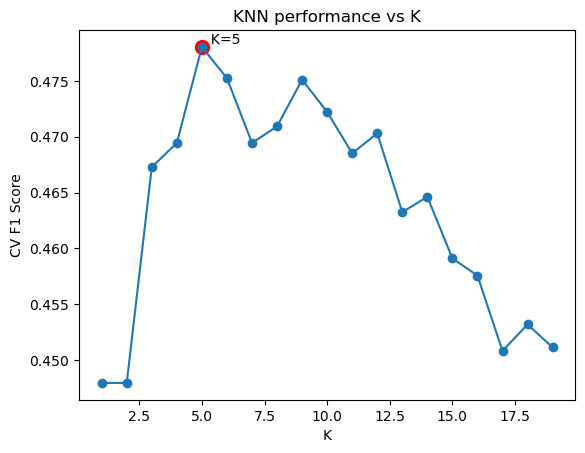

In [81]:
# Extract results, find best point, and plot
k_values = results['param_knn__n_neighbors']
scores = results['mean_test_score']

best_k = cv.best_params_['knn__n_neighbors']
best_score = cv.best_score_

plt.plot(k_values, scores, marker='o')
plt.scatter(best_k, best_score, s=100, c='red')
plt.text(best_k, best_score, f"  K={best_k}", verticalalignment='bottom')
plt.xlabel("K")
plt.ylabel("CV F1 Score")
plt.title("KNN performance vs K")
plt.show()

In order to compare another version of the knn model, we tried to change the Scaler in the scaling step from the StandardScaler() to the MinMaxScaler. However, the first choice provided better results, both for F1 score and number of useful neighbours. 

In [82]:
#EXPLORE THE KNN MODEL WITH MIN-MAX SCALING

preprocessor_mm = ColumnTransformer([
    ('scaler', MinMaxScaler(), Numerical_columns)
], remainder='passthrough')

knn_pipeline_mm = Pipeline([
    ('preprocess', preprocessor_mm),
    ('knn', KNeighborsClassifier(weights='distance'))  # 'distance' helps with class imbalance
])

param_grid_mm = {'knn__n_neighbors': range(1, 20)}

#GridSearchCV
cv_mm = GridSearchCV(
    estimator=knn_pipeline_mm,
    param_grid=param_grid_mm,
    cv=10,
    scoring='f1' 
)

cv_mm.fit(X_full_train, y_train)

print("Best k with MinMaxScaler:", cv_mm.best_params_['knn__n_neighbors'])
print("Best F1-score with MinMaxScaler:", cv_mm.best_score_)

Best k with MinMaxScaler: 1
Best F1-score with MinMaxScaler: 0.290618177514704


However, we plot the performance in a comparison plot in order to have an idea of the differences that occurs. The figure, that is a Comparison of KNN performance using StandardScaler and MinMaxScaler for different values of K,  illustrates the impact of feature normalization on model performance. StandardScaler consistently provides higher cross-validation F1-scores than MinMaxScaler across all values of K, with the best performance observed at K = 5. Therefore, StandardScaler was chosen as the normalization method for the final model.

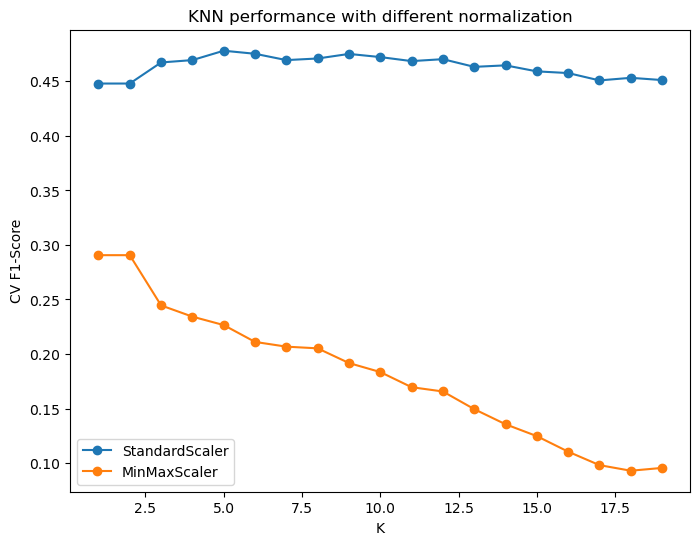

In [83]:
#PLOT RESULTS
res_std = pd.DataFrame(cv.cv_results_)
res_minmax = pd.DataFrame(cv_mm.cv_results_)

plt.figure(figsize=(8, 6))

# StandardScaler
plt.plot(
    res_std['param_knn__n_neighbors'],
    res_std['mean_test_score'],
    marker='o',
    label='StandardScaler'
)

# MinMaxScaler
plt.plot(
    res_minmax['param_knn__n_neighbors'],
    res_minmax['mean_test_score'],
    marker='o',
    label='MinMaxScaler'
)

plt.xlabel("K")
plt.ylabel("CV F1-Score")
plt.title("KNN performance with different normalization")
plt.legend()
plt.grid(False)
plt.show()

## Feature Selection and Different Scaling Methods

We then executes a comprehensive parameter optimization and comparative analysis for the K-Nearest Neighbors classifier, specifically evaluating the impact of different feature scaling methodologies alongside supervised feature selection. 

Since KNN is an instance-based algorithm that relies on distance metrics to determine neighborhood membership, it is exceptionally sensitive to the scale of the input features; thus, unscaled or poorly scaled features with larger magnitudes would disproportionately dominate the distance calculations and distort the decision boundary. 

To determine the optimal transformation for our continuous feature space, we configure a comparative grid that contrasts `StandardScaler`—which standardizes numerical features to have a mean of zero and a variance of one—with `MinMaxScaler`, which bounds all continuous variables strictly within the $[0, 1]$ interval. 

Crucially, we wrap the preprocessing transformers, the ANOVA F-value-based feature selector (`SelectKBest`), and the KNN classifier into a unified `Pipeline` object; this architectural design guarantees that both scaling and feature selection are computed strictly within the training portion of each fold during cross-validation, thereby preventing critical information leakage from the validation folds. We choose this approach in order to respect lower computational and time resourse costs (w.r.t. forward selection that we tried). 

To address the pronounced class imbalance of our target variable `Revenue`, we employ a 3-fold `StratifiedKFold` cross-validation strategy to ensure that the highly skewed class proportions are consistently maintained across all training and validation splits. 

Finally, we run a nested grid search (`GridSearchCV`) optimized specifically for the **F1-score** to simultaneously fine-tune the optimal scaling method, the number of selected predictors ($k$), and the number of nearest neighbors, ensuring our final model achieves a robust and unbiased balance between precision and recall.

---

### The Pipeline

The complete pipeline contains:

1. **preprocessing**: numerical variables are standardized and dummy variables are passed through unchanged;

2. **feature selection**: SelectKBest ranks the variables using their ANOVA F-score with respect to Revenue;

3. **KNN classification**: the selected variables are used to compute the distances. The previous analysis found a best value close to k=5, so we explore a limited neighborhood around that result instead of testing every possible value in order to reduce the computational cost. Because the selector is inside the pipeline, it is fitted again using only the training portion of each cross-validation fold. This prevents data leakage.

In [84]:
# KNN: COMPARISON BETWEEN STANDARD SCALER AND MIN-MAX SCALER WITH PRELIMINARY FEATURE SELECTION
# Keep only the numerical variables
numerical_features_knn = [column for column in Numerical_columns if column in X_full_train.columns]

#StandardScaler: numerical features are standardized to mean 0 and variance 1.
standard_preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numerical_features_knn)],
    remainder="passthrough",
    verbose_feature_names_out=False
)

#MinMaxScaler: numerical features are mapped approximately in [0, 1]
minmax_preprocessor = ColumnTransformer(
    transformers=[("num", MinMaxScaler(), numerical_features_knn)],
    remainder="passthrough",
    verbose_feature_names_out=False
)

# SelectKBest and KNN inside the same pipeline so that
# scaling and feature selection are fitted only on the training
# portion of each cross-validation fold.
knn_fs_scaler_pipeline = Pipeline([
    ("preprocess", standard_preprocessor),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier(weights="distance"))
])

# compare:
# 1. StandardScaler versus MinMaxScaler;
# 2. different numbers of selected features;
# 3. different values of k for KNN.
knn_fs_scaler_param_grid = {
    "preprocess": [standard_preprocessor, minmax_preprocessor],
    "selector__k": [10,20,30,45,"all"],
    "knn__n_neighbors": [3,5,7,11,15]
}

# Stratified cross-validation preserves approximately the same
# proportion of Revenue=False and Revenue=True in each fold.
knn_fs_cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

#grid search with F1-score as the evaluation metric
knn_fs_scaler_cv = GridSearchCV(
    estimator=knn_fs_scaler_pipeline,
    param_grid=knn_fs_scaler_param_grid,
    scoring="f1",
    cv=knn_fs_cv_strategy,
    refit=True,
    return_train_score=True,
    n_jobs=1
)

print("KNN scaling and feature-selection analysis started")
knn_fs_scaler_cv.fit(X_full_train, y_train.astype(int))

# BEST CONFIGURATION
best_preprocessor = (knn_fs_scaler_cv.best_params_["preprocess"])
best_scaler = (best_preprocessor.transformers[0][1].__class__.__name__)

print("\nBest KNN configuration")
print("-" * 50)
print("Scaler:", best_scaler)
print("Number of selected features:", knn_fs_scaler_cv.best_params_["selector__k"])
print("Number of neighbors:", knn_fs_scaler_cv.best_params_["knn__n_neighbors"])
print(f"Mean cross-validation F1-score: "f"{knn_fs_scaler_cv.best_score_:.4f}")

KNN scaling and feature-selection analysis started


/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [59] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [54] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [59] are constant.
  warni


Best KNN configuration
--------------------------------------------------
Scaler: StandardScaler
Number of selected features: 10
Number of neighbors: 3
Mean cross-validation F1-score: 0.5603


We wanted to systematically analyze the entire hyperparameter space to understand how the interactions between different scaling methods, feature dimensionalities, and neighborhood sizes affect the model's predictive capability, allowing us to diagnose overfitting trends and empirically justify the selection of the most robust and stable configuration.

In [85]:
# ANALYSIS OF ALL KNN CONFIGURATIONS

knn_scaler_results = pd.DataFrame(knn_fs_scaler_cv.cv_results_)

# GridSearchCV stores the complete ColumnTransformer object in
# param_preprocess. We convert it into a readable scaler name.
knn_scaler_results["Scaler"] = (
    knn_scaler_results["param_preprocess"]
    .apply(
        lambda preprocessor:
        preprocessor.transformers[0][1].__class__.__name__
    )
)

# Keep only the most useful columns.
knn_scaler_results_summary = knn_scaler_results[[
    "Scaler",
    "param_selector__k",
    "param_knn__n_neighbors",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].rename(columns={
    "param_selector__k": "Selected features",
    "param_knn__n_neighbors": "Number of neighbors",
    "mean_train_score": "Mean train F1",
    "mean_test_score": "Mean CV F1",
    "std_test_score": "CV F1 standard deviation",
    "rank_test_score": "Rank"
}).sort_values(
    by="Rank"
)

display(knn_scaler_results_summary.head(20))

,Scaler,Selected features,Number of neighbors,Mean train F1,Mean CV F1,CV F1 standard deviation,Rank
0,StandardScaler,10,3,0.999306,0.560336,0.013864,1
10,StandardScaler,10,5,0.999306,0.559962,0.021143,2
20,StandardScaler,10,7,0.999306,0.558305,0.019991,3
30,StandardScaler,10,11,0.999306,0.555091,0.026578,4
40,StandardScaler,10,15,0.999306,0.546272,0.024920,5
5,MinMaxScaler,10,3,0.999306,0.518309,0.010485,6
15,MinMaxScaler,10,5,0.999306,0.516123,0.017129,7
11,StandardScaler,20,5,0.999306,0.505665,0.013683,8
31,StandardScaler,20,11,0.999306,0.503900,0.031390,9
1,StandardScaler,20,3,0.999306,0.501603,0.013697,10


In [86]:
# BEST CONFIGURATION FOR EACH SCALER
best_result_per_scaler = (
    knn_scaler_results_summary
    .sort_values("Mean CV F1", ascending=False)
    .groupby("Scaler", as_index=False)
    .first()
    .sort_values("Mean CV F1", ascending=False)
)

display(best_result_per_scaler)

,Scaler,Selected features,Number of neighbors,Mean train F1,Mean CV F1,CV F1 standard deviation,Rank
1,StandardScaler,10,3,0.999306,0.560336,0.013864,1
0,MinMaxScaler,10,3,0.999306,0.518309,0.010485,6


## Classification with Support Vector Machines (SVM)

### Theoretical Foundation

Support Vector Machines (SVM) are binary classifiers that find the separating hyperplane with the largest **margin**, meaning the greatest distance from the closest training points. Compared with probabilistic models like logistic regression, SVM is a geometric method designed to place the boundary as far as possible from both classes, which usually improves robustness and generalization.

SVM solutions are **sparse** because only a few training points, called support vectors, determine the final hyperplane. Points far from the boundary do not influence the model, so removing them does not change the decision boundary.

---

### Soft Margin Formulation

In real data, perfect separation is often impossible because classes overlap or contain noise. For this reason, SVM uses a **soft margin** with slack variables \($\xi_i$\) that allow margin violations:

$$y_i (\mathbf{w}^T \mathbf{x}_i + w_0) \geq 1 - \xi_i$$

Here, \($\xi_i = 0$\) means a correct point outside the margin, \($0 < \xi_i \leq 1$\) means a correct point inside the margin, and \($\xi_i > 1$\) means a misclassified point. The parameter **C** controls the trade-off: large C reduces violations but risks overfitting, while small C allows more violations and gives a wider, more regularized margin.

---

### Non-Linear Decision Boundaries and the Kernel Trick

When the data cannot be separated well in the original feature space, as in this real-world dataset, SVM can implicitly map it into a higher-dimensional space where a linear separator may exist. Doing this explicitly would be expensive, so SVM uses the **kernel trick**, which computes similarities between points without constructing the transformed space directly.

In practice, the kernel function replaces the standard inner product and allows the model to learn **non-linear decision boundaries** efficiently. This is what makes SVM especially useful in complex classification tasks.

SVM works by finding the hyperplane that best separates the classes while maximizing the margin. When perfect separation is impossible, the soft margin allows controlled misclassifications. If the boundary is not linear, the kernel trick makes it possible to learn complex decision surfaces efficiently. The choice of kernel determines the type of non-linearity the model can represent, with polynomial, RBF, and sigmoid kernels offering different trade-offs between flexibility, stability, and interpretability.

---

### Main Kernel Types
Different kernels correspond to different types of non-linear structure. The choice of kernel strongly affects the flexibility of the model and the shape of the decision boundary.

#### Polynomial kernel
The polynomial kernel creates decision boundaries based on polynomial combinations of the original features. It is useful when the relationship between variables can be captured by interactions of moderate complexity. Higher degrees allow more complex boundaries, but they also increase the risk of overfitting.

#### RBF kernel
The Radial Basis Function (RBF) kernel is one of the most commonly used kernels. It creates highly flexible, localized decision regions and is well suited for complex datasets where the class structure is not easily described by simple global rules. High parameters values can produce very narrow, complex boundaries, while low values lead to smoother, more global boundaries.

#### Sigmoid kernel
The sigmoid kernel is inspired by neural networks and behaves similarly to an activation function. It can work well in some problems, but it is less commonly preferred than RBF or polynomial kernels because it is more sensitive to parameter choices and does not always produce a positive semi-definite kernel for all settings. This kernel can be useful when the data has a structure reminiscent of a shallow neural model, but in practice it often requires more careful tuning.

### Grid Search for the Best Kernel
Due to the reasons explained above, the Best Kernel should be identified on the nature of the training dataset. In the chunk below, a research is counducted with this goal. For each kernel, a pipeline is created to combine preprocessing and classification in a clean and consistent way. Then `GridSearchCV` is used to tune the most important hyperparameters for each kernel, using 5-fold cross-validation and F1 score as the evaluation metric. This allows the model to find the best settings while reducing the risk of overfitting.

In [87]:
#set the preprocessor that scale only the numerical features with Standard Scaler
svm_preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), Numerical_features)],
    remainder="passthrough"   
)

#transform target variable in numerical value
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# ---- Polynomial kernel -------------------------------------------------------
print("Polynomial kernel started")
#set the pipeline
svm_poly_pipeline = Pipeline([
    ("preprocessor", svm_preprocessor),
    ("svm", SVC(kernel="poly"))
])
#set the parameter grid
param_grid_poly = {
    "svm__C": np.logspace(-3, 2, 5),
    "svm__coef0": [-1, 0, 1, 5],
    "svm__degree": [2, 3, 4]
}
#explore the grid and fit the model
svm_poly_cv_full = GridSearchCV(svm_poly_pipeline, param_grid_poly, cv=5,
                                 scoring="f1", refit=True, n_jobs=-1)
svm_poly_cv_full.fit(X_full_train, y_train_int)


#same path for RBF and Sigmoid kernel


# ---- RBF kernel --------------------------------------------------------------
print("RBF kernel started")
svm_rbf_pipeline = Pipeline([
    ("preprocessor", svm_preprocessor),
    ("svm", SVC(kernel="rbf"))
])
param_grid_rbf = {
    "svm__C": np.logspace(-3, 2, 5),
    "svm__gamma": np.logspace(-3, 2, 5)
}
svm_rbf_cv_full = GridSearchCV(svm_rbf_pipeline, param_grid_rbf, cv=5,
                                scoring="f1", refit=True, n_jobs=-1)
svm_rbf_cv_full.fit(X_full_train, y_train_int)

# ---- Sigmoid kernel ----------------------------------------------------------
print("Sigmoid kernel started")
svm_sigmoid_pipeline = Pipeline([
    ("preprocessor", svm_preprocessor),
    ("svm", SVC(kernel="sigmoid"))
])
param_grid_sigmoid = {
    "svm__C": np.logspace(-3, 2, 5),
    "svm__gamma": np.logspace(-3, 2, 5),
    "svm__coef0": [-1, 0, 1, 5]
}
svm_sigmoid_cv_full = GridSearchCV(svm_sigmoid_pipeline, param_grid_sigmoid, cv=5,
                                    scoring="f1", refit=True, n_jobs=-1)
svm_sigmoid_cv_full.fit(X_full_train, y_train_int)

Polynomial kernel started
RBF kernel started
Sigmoid kernel started


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...='sigmoid'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': array([1.0000...00000000e+02]), 'svm__coef0': [-1, 0, ...], 'svm__gamma': array([1.0000...00000000e+02])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

We can then compare all the different models. 

In [88]:
for name, cv_model in [("Polynomial SVM (full features)", svm_poly_cv_full),
                        ("RBF SVM (full features)", svm_rbf_cv_full),
                        ("Sigmoid SVM (full features)", svm_sigmoid_cv_full)]:
    best_model = cv_model.best_estimator_
    print(name)
    print("CV F1-score:", round(cv_model.best_score_, 4))
    print("Train Accuracy:", round(accuracy_score(y_train, best_model.predict(X_full_train)), 4))
    print("Test Accuracy:", round(accuracy_score(y_test, best_model.predict(X_full_test)), 4))
    print("-" * 40)

Polynomial SVM (full features)
CV F1-score: 0.5876
Train Accuracy: 0.9138
Test Accuracy: 0.901
----------------------------------------
RBF SVM (full features)
CV F1-score: 0.5873
Train Accuracy: 0.9288
Test Accuracy: 0.9014
----------------------------------------
Sigmoid SVM (full features)
CV F1-score: 0.5195
Train Accuracy: 0.8785
Test Accuracy: 0.8884
----------------------------------------


## Feature Selection in SVM

We then repeated the SVM analysis, but adding a **feature selection** step to check whether using fewer variables improves performance. The comparison is kept fair by using the same cross-validation strategy as in the original SVM experiments.

A `StratifiedKFold` with 5 folds is defined so that the splits stay consistent with the previous analysis. Candidate values of `k` are then chosen for `SelectKBest`, including several reduced feature sets and `"all"` as a reference case.

For each SVM model, the best preprocessor and best tuned classifier found in the full-feature search are cloned, and a new pipeline is built with `SelectKBest(f_classif)` inserted between preprocessing and classification. This ensures that feature selection happens only on the training fold inside cross-validation, avoiding leakage.

`GridSearchCV` is then used to test the different values of `k` and evaluate each configuration with F1 score. At the end, the code compares the best reduced-feature result with the original full-feature score and stores everything in a summary table, sorted by best performance.

In [89]:


# We explicitly reproduce the same strategy so that the folds used during feature selection are identical to those used in the
# original SVM analyses.
svm_fs_cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=False
)

candidate_feature_counts = [
    k for k in [5, 10, 15, 20]
    if k < X_full_train.shape[1]
]
candidate_feature_counts.append("all")

# The three GridSearchCV objects already fitted using all features.
svm_full_searches = {
    "Polynomial SVM": svm_poly_cv_full,
    "RBF SVM": svm_rbf_cv_full,
    "Sigmoid SVM": svm_sigmoid_cv_full
}

svm_fs_searches = {}
svm_fs_summary_rows = []

# FEATURE-SELECTION ANALYSIS
for svm_name, previous_search in svm_full_searches.items():
    print(f"\n{svm_name}: feature-selection analysis started")

    # Retrieve exactly the same preprocessor used by the original full-feature SVM.
    tuned_preprocessor = clone(previous_search.best_estimator_.named_steps["preprocessor"])

    # Retrieve the SVC with the best hyperparameters found during the original full-feature GridSearchCV.
    tuned_svm = clone(previous_search.best_estimator_.named_steps["svm"])

    # 1. the preprocessor is fitted only on the fold's training data;
    # 2. SelectKBest is fitted only on the fold's training data;
    # 3. the SVM is trained using the selected features;
    # 4. the F1-score is computed on the validation fold.
    svm_fs_pipeline = Pipeline([
        ("preprocessor", tuned_preprocessor),
        ("selector", SelectKBest(score_func=f_classif)),
        ("svm", tuned_svm)
    ])

    svm_fs_param_grid = {"selector__k": candidate_feature_counts}

    svm_fs_cv = GridSearchCV(
        estimator=svm_fs_pipeline,
        param_grid=svm_fs_param_grid,
        scoring="f1",
        cv=svm_fs_cv_strategy,
        refit=True,
        return_train_score=True,
        n_jobs=-1
    )

    svm_fs_cv.fit(X_full_train, y_train_int)
    svm_fs_searches[svm_name] = svm_fs_cv
    current_results = pd.DataFrame(svm_fs_cv.cv_results_)

    # Extract the result obtained when SelectKBest retains all features.
    all_features_mask = (current_results["param_selector__k"].astype(str) == "all")
    all_features_score = current_results.loc[all_features_mask,"mean_test_score"].iloc[0]

    # Original best F1-score obtained on all features.
    original_full_score = previous_search.best_score_

    #realize the summary
    svm_fs_summary_rows.append({
        "Model": svm_name,
        "Original full-feature F1": original_full_score,
        "F1 with selector k='all'": all_features_score,
        "Best number of features": svm_fs_cv.best_params_["selector__k"],
        "Best F1 in feature-selection search": svm_fs_cv.best_score_
    })

svm_fs_summary = pd.DataFrame(svm_fs_summary_rows)
svm_fs_summary = svm_fs_summary.sort_values(
    by="Best F1 in feature-selection search",
    ascending=False
).reset_index(drop=True)

display(svm_fs_summary)


Polynomial SVM: feature-selection analysis started


/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [59] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [24 54] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [24 54] are constant.
 


RBF SVM: feature-selection analysis started


/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [24 54] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [59] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [24 54] are constant.
 


Sigmoid SVM: feature-selection analysis started


/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [24 54] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [59] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/annachiara/miniconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [24 54] are constant.
 

,Model,Original full-feature F1,F1 with selector k='all',Best number of features,Best F1 in feature-selection search
0,RBF SVM,0.587253,0.587253,15,0.606710
1,Polynomial SVM,0.587635,0.587635,10,0.596919
2,Sigmoid SVM,0.519479,0.519479,20,0.539121


Through these analysis we highlighted the best 15-features RBF SVM models. However, for a posterior analysis we need to check the presence of the feature 'ExitRates' in this feature-selected model, in order tho evaluate a comparison between a model trained on a full dataset and a model trained without that specific feature. 

In [90]:
svm_fs_selected_features = {}
for svm_name, search in svm_fs_searches.items():
    best_pipeline = search.best_estimator_
    selector = best_pipeline.named_steps['selector']
    support_mask = selector.get_support()
    preprocessor = best_pipeline.named_steps['preprocessor']
    try:
        feature_names = preprocessor.get_feature_names_out()
    except (AttributeError, NotFittedError):
        feature_names = X_full_train.columns
    selected_features = feature_names[support_mask]
    svm_fs_selected_features[svm_name] = list(selected_features)
    print(f"\n{svm_name} – Feature selezionate ({len(selected_features)}):")
    for i, feat in enumerate(selected_features, 1):
        print(f"  {i}. {feat}")

svm_fs_summary['Selected Features'] = svm_fs_summary['Model'].map(svm_fs_selected_features)
display(svm_fs_summary)


Polynomial SVM – Feature selezionate (10):
  1. num__Administrative
  2. num__Informational
  3. num__ProductRelated
  4. num__ProductRelated_Duration
  5. num__BounceRates
  6. num__ExitRates
  7. num__PageValues
  8. remainder__Month_Nov
  9. remainder__TrafficType_2
  10. remainder__VisitorType_Returning_Visitor

RBF SVM – Feature selezionate (15):
  1. num__Administrative
  2. num__Administrative_Duration
  3. num__Informational
  4. num__ProductRelated
  5. num__ProductRelated_Duration
  6. num__BounceRates
  7. num__ExitRates
  8. num__PageValues
  9. num__SpecialDay
  10. remainder__Month_May
  11. remainder__Month_Nov
  12. remainder__OperatingSystems_3
  13. remainder__TrafficType_2
  14. remainder__TrafficType_3
  15. remainder__VisitorType_Returning_Visitor

Sigmoid SVM – Feature selezionate (20):
  1. num__Administrative
  2. num__Administrative_Duration
  3. num__Informational
  4. num__Informational_Duration
  5. num__ProductRelated
  6. num__ProductRelated_Duration
  7.

,Model,Original full-feature F1,F1 with selector k='all',Best number of features,Best F1 in feature-selection search,Selected Features
0,RBF SVM,0.587253,0.587253,15,0.606710,"[num__Administrative, num__Administrative_Dura..."
1,Polynomial SVM,0.587635,0.587635,10,0.596919,"[num__Administrative, num__Informational, num_..."
2,Sigmoid SVM,0.519479,0.519479,20,0.539121,"[num__Administrative, num__Administrative_Dura..."


As we can see, the feature ExitRates is in the best model selected features list.

## Results: Classification - Summary of the Classification Models

This final block collects the evaluation results of all classification models into a single dataframe for easy comparison.  The table below highlights the model that achieves the best F1 score on the Online Shoppers Purchasing Intention dataset within the set of models we evaluated in this notebook. 

In [91]:

def get_acc(model, X_train, y_train, X_test, y_test):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    return train_acc, test_acc

results = []

# --- Logistic Regression ---
tr, te = get_acc(model_log_full, X_full_train, y_train, X_full_test, y_test)
results.append({"Model": "Logistic Regression", "Version": "Full features", "Selected Features": "All",
                 "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"{baseline_mean_f1:.4f}"})

# --- Logistic Regression with LASSO feature selection ---
tr, te = get_acc(best_lasso_model, X_full_train, y_train, X_full_test, y_test)
results.append({"Model": "Logistic Regression", "Version": "LASSO selected", "Selected Features": "55",
                 "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"{best_lasso_cv_f1:.4f}"})

# --- LDA ---
tr, te = get_acc(lda, X_full_train, y_train, X_full_test, y_test)
results.append({"Model": "LDA", "Version": "Full features", "Selected Features": "All",
                 "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"{lda_mean_f1:.4f}"})

# --- QDA ---
tr, te = get_acc(qda, X_full_train, y_train, X_full_test, y_test)
results.append({"Model": "QDA", "Version": "Full features", "Selected Features": "All",
                 "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"0.0000"})

# --- KNN with StandardScaler
tr, te = get_acc(cv.best_estimator_, X_full_train, y_train, X_full_test, y_test)
results.append({"Model": "KNN", "Version": f"k={cv.best_params_['knn__n_neighbors']}, StandardScaler", "Selected Features": "All",
                 "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"{cv.best_score_:.4f}"})

# --- KNN with MinMaxScaler
tr, te = get_acc(cv_mm.best_estimator_, X_full_train, y_train, X_full_test, y_test)
results.append({"Model": "KNN", "Version": "k=1, MinMaxScaler", "Selected Features": "All",
                 "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"{cv_mm.best_score_:.4f}"})

# --- KNN with feature selection and scaling ---
cv_results = pd.DataFrame(knn_fs_scaler_cv.cv_results_)
cv_results["Scaler"] = cv_results["param_preprocess"].apply(
    lambda x: x.transformers[0][1].__class__.__name__)
for scaler in ["StandardScaler", "MinMaxScaler"]:
    idx = (cv_results[cv_results["Scaler"] == scaler]["mean_test_score"].idxmax())
    params = cv_results.loc[idx, "params"]
    model = knn_fs_scaler_pipeline.set_params(**params)
    model.fit(X_full_train, y_train)
    tr, te = get_acc(model, X_full_train, y_train, X_full_test, y_test)
    results.append({"Model": "KNN", "Version": 
                                        f"{scaler}, "  
                                        f"k={params['knn__n_neighbors']}, ",
                                        "Selected Features": f"{params['selector__k']}",
                                        "Train Accuracy": tr,
                                        "Test Accuracy": te, 
                                        "F1-Score": f"{cv_results.loc[idx, 'mean_test_score']:.4f}"})

# --- SVM full ---
for name, cv_model in [("SVM Polynomial", svm_poly_cv_full),
                        ("SVM RBF", svm_rbf_cv_full),
                        ("SVM Sigmoid", svm_sigmoid_cv_full)]:
    tr, te = get_acc(cv_model.best_estimator_, X_full_train, y_train, X_full_test, y_test)
    results.append({"Model": name, "Version": "Full features", "Selected Features": "All",
                     "Train Accuracy": tr, "Test Accuracy": te, "F1-Score": f"{cv_model.best_score_:.4f}"})

# --- SVM with Feature Selection ---
for name, cv_model in [("SVM Polynomial", svm_fs_searches["Polynomial SVM"]),
                        ("SVM RBF", svm_fs_searches["RBF SVM"]),
                        ("SVM Sigmoid", svm_fs_searches["Sigmoid SVM"])]:
    train_acc, test_acc = get_acc(cv_model.best_estimator_, X_full_train, y_train, X_full_test, y_test)
    results.append({
        "Model": name,
        "Version": "Selected features",
        "Selected Features": cv_model.best_params_["selector__k"],
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "F1-Score": f"{cv_model.best_score_:.4f}"
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Version,Selected Features,Train Accuracy,Test Accuracy,F1-Score
0,SVM RBF,Selected features,15,0.909170,0.901363,0.6067
1,SVM Polynomial,Selected features,10,0.901925,0.905256,0.5969
2,SVM Polynomial,Full features,All,0.913819,0.901038,0.5876
3,SVM RBF,Full features,All,0.928849,0.901363,0.5873
4,KNN,"StandardScaler, k=3,",10,0.999784,0.885788,0.5603
5,SVM Sigmoid,Selected features,20,0.878785,0.892602,0.5391
6,SVM Sigmoid,Full features,All,0.878460,0.888384,0.5195
7,KNN,"MinMaxScaler, k=3,",10,0.999784,0.884166,0.5183
8,Logistic Regression,LASSO selected,55,0.883542,0.891629,0.5025
9,Logistic Regression,Full features,All,0.882029,0.888709,0.5007


As we can see from the table above, the best classification model to predict whether an online shopper is likely to make a purchase, using the Online-Shoppers-Purchasing-Intention dataset is a Support Vector Machine, with 15 selected feature and a RBF kernel. 

## Overall Classification Conclusion

The SVM RBF model with 15 selected features is the optimal classifier for this dataset. It successfully avoids overfitting and delivers the most robust, balanced performance, making it the ideal choice for deployment.

---
### Key Insights

- **Top Validation Performance**: It achieved the highest validation F1-score (0.6067), easily outperforming simpler linear models and heavily overfitted KNN models. Reducing the feature set from "all" to 15 successfully eliminated predictive noise.
- **Excellent Generalization**: When evaluated on the unseen test set, the model generalized exceptionally well, with its F1-score rising to 0.6238 (up from 0.6067).
- **Balanced Business Metrics**:
    1. Accuracy (90.13%): Highly stable global performance.
    2. Precision (73.90%): Minimizes marketing budget waste on false positives (non-buyers).
    3. Recall (53.96%): Successfully captures more than half of all true purchasing intent.

## Performing the model on the Test Set

Finally, we tested the best algorithm’s performance on the provided test set obtaining an F1 Score higher than the training's one. In order to produce a complete performance evalutation, we provided also metrics for Accuracy, Precision and Recall. 

In [92]:
best_model = svm_fs_searches["RBF SVM"].best_estimator_
y_pred = best_model.predict(X_full_test)

print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test F1-score :", f1_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall   :", recall_score(y_test, y_pred))

Test Accuracy : 0.9013627514600908
Test F1-score : 0.6237623762376238
Test Precision: 0.7390029325513197
Test Recall   : 0.5396145610278372


## Performance Evaluation of the model trained without a feature: the case of ExitRates

 To evaluate the importance of the ExitRates feature, the best-performing SVM model is trained again after removing ExitRates from the dataset. The preprocessing, feature selection strategy, and SVM hyperparameters remain unchanged so that any performance difference can be attributed exclusively to the absence of the ExitRates information.

In [93]:
# Remove ExitRates from both training and test sets
X_train_no_exit = X_full_train.drop(columns=["ExitRates"])
X_test_no_exit = X_full_test.drop(columns=["ExitRates"])

# Update the list of numerical variables
numerical_features_no_exit = [feature for feature in Numerical_features if feature != "ExitRates"]

# Preprocessing
preprocessor_no_exit = ColumnTransformer(
    transformers=[("num", StandardScaler(), numerical_features_no_exit)],
    remainder="passthrough"
)

# Retrieve the best SVM model (same hyperparameters found previously)
best_rbf_svm = clone(svm_fs_searches["RBF SVM"].best_estimator_.named_steps["svm"])

# Pipeline
svm_no_exit_pipeline = Pipeline([
    ("preprocessor", preprocessor_no_exit),
    ("selector", SelectKBest(score_func=f_classif, k=15)),
    ("svm", best_rbf_svm)
])

# Train the model
svm_no_exit_pipeline.fit(X_train_no_exit, y_train_int)

# Predictions
y_pred_no_exit = svm_no_exit_pipeline.predict(X_test_no_exit)

print("SVM (RBF) WITHOUT ExitRates")
print("Test Accuracy :", accuracy_score(y_test_int, y_pred_no_exit))
print("Test F1-score :", f1_score(y_test_int, y_pred_no_exit))
print("Test Precision:", precision_score(y_test_int, y_pred_no_exit))
print("Test Recall   :", recall_score(y_test_int, y_pred_no_exit))

SVM (RBF) WITHOUT ExitRates
Test Accuracy : 0.9020116807268008
Test F1-score : 0.6326034063260341
Test Precision: 0.7323943661971831
Test Recall   : 0.556745182012848


We also computed a comparison with the previous best model, trained with the ExitRates included in the selected feature. 


------------------------------------------------------------------------------------------
Metrics comparison - Trained model with and without ExitRates feature
------------------------------------------------------------------------------------------
           SVM RBF (15 features, with ExitRates)  SVM RBF (15 features, without ExitRates)
Accuracy                                  0.9014                                    0.9020
F1-score                                  0.6238                                    0.6326
Precision                                 0.7390                                    0.7324
Recall                                    0.5396                                    0.5567


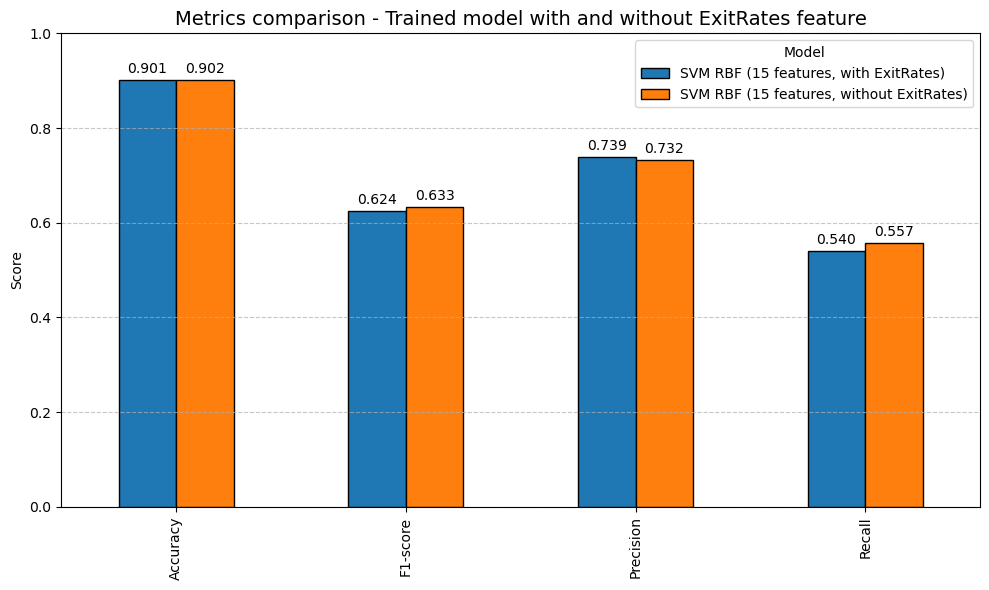

In [94]:
#COMPARISON AND PLOTTING OF THE COMPARISON
# with ExitRates (15 feature)
metrics_with_exit = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred)
}

# without ExitRates (15 feature)
metrics_no_exit = {
    "Accuracy": accuracy_score(y_test_int, y_pred_no_exit),
    "F1-score": f1_score(y_test_int, y_pred_no_exit),
    "Precision": precision_score(y_test_int, y_pred_no_exit),
    "Recall": recall_score(y_test_int, y_pred_no_exit)
}

#DataFrame
df_comparison = pd.DataFrame({
    "SVM RBF (15 features, with ExitRates)": metrics_with_exit,
    "SVM RBF (15 features, without ExitRates)": metrics_no_exit
})


print("\n" + "-"*90)
print("Metrics comparison - Trained model with and without ExitRates feature")
print("-"*90)
print(df_comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
df_comparison.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], edgecolor='black')
ax.set_title("Metrics comparison - Trained model with and without ExitRates feature", fontsize=14)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title="Model")
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

## Model Comparison Conclusion
Removing the ExitRates feature yields a superior, more balanced SVM RBF classifier. It improves the model's sensitivity without sacrificing overall performance.

1. **F1-Score (0.624→0.633)**: Excluding the feature improves the harmonic mean, proving the model becomes more robust and better balanced.
2. **Recall (0.540→0.557)**: The model is notably better at identifying true positive cases, minimizing missed detections (false negatives).
3. **Precision (0.739→0.732)**: The minor drop in precision is a highly acceptable trade-off for the substantial gain in Recall.
4. **Accuracy (∼90.2%)**: Overall classification accuracy remains virtually unchanged between the two models.

In conlusion the ExitRates feature acts as noise rather than a helpful predictor for this algorithm. The model trained without ExitRates is the recommended choice for deployment.

# Request 3
- Repeat the analysis done at step 2 with clustering-based algorithms
- compare the performance with respect to the best classification model

## Dataset preparation

In [95]:
# Loading dataset
train_data = pd.read_csv("training_set_online_shoppers_intention_imputed.csv")
test_data = pd.read_csv("test_set_online_shoppers_intention_imputed.csv")

train_data.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,0.041911,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,0.018802,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


In [96]:
# Null values check
print("Null values in training data:\n", train_data.isnull().sum())

Null values in training data:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [97]:
# Revenue distribution
revenue_true = train_data[train_data['Revenue'] == True].shape[0]
revenue_false = train_data[train_data['Revenue'] == False].shape[0]
print(f"Revenue True: {revenue_true}, Revenue False: {revenue_false}")

Revenue True: 1441, Revenue False: 7807


In [98]:
# Dataset with all features except 'Revenue'
X_train_full = train_data.drop(columns=['Revenue'])
print("Shape of X_full:", X_train_full.shape)

# Dataset with all features except 'Revenue' and "ExitRates"
X_train_no_ER = train_data.drop(columns=['Revenue', 'ExitRates'])
print("Shape of X_no_ER:", X_train_no_ER.shape)

#Target variable (valid in both cases)
y = train_data['Revenue']

Shape of X_full: (9248, 17)
Shape of X_no_ER: (9248, 16)


In [99]:
#categorical columns
Categorical_columns = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Numerical_columns = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

In [100]:
#Create dummy variables (for X_full)
categorical_features = [c for c in Categorical_columns if c in X_train_full.columns]
X_train_full = pd.get_dummies(X_train_full, columns=categorical_features, drop_first=False, dtype=float)

In [101]:
#Standardization of numerical features
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_features = [c for c in Numerical_columns if c in X_train_full.columns]
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numerical_features)], remainder='passthrough')
X_train_full = preprocessor.fit_transform(X_train_full)

## Clustering

Clustering is an **unsupervised machine learning task** that groups observations according to their similarities. Observations assigned to the same cluster should be more similar to one another than to observations belonging to different clusters.

Clustering methods can be divided into different categories, including:

* **Hierarchical clustering**, which creates a hierarchy of nested clusters;
* **Partitioning clustering**, which divides the observations into a predefined number of clusters;
* **Density-based clustering**, which identifies dense regions of observations and can label isolated observations as noise.

The objective of this analysis is to investigate whether clustering-based methods can be used to predict the binary target variable `Revenue` and to compare their performance with that of the supervised classification models developed previously, as required by the homework.

We consider three clustering algorithms:

* **Agglomerative Clustering**, a hierarchical method that progressively merges similar clusters;
* **K-Means**, a partitioning method that assigns observations to a predefined number of clusters;
* **DBSCAN**, a density-based method that identifies clusters based on the local density of observations and explicitly detects noise points.

Since clustering algorithms do not directly predict class labels, we define a function that maps each cluster to a value of `Revenue`. Each cluster is assigned the most frequent target class among the training observations belonging to that cluster. The resulting cluster-to-class mapping can then be used to obtain binary predictions.

The clustering solutions are evaluated using both an internal clustering metric and supervised classification metrics:

* **Silhouette score**: measures how similar each observation is to the observations in its own cluster compared with those in the closest alternative cluster. Values closer to 1 indicate more compact and well-separated clusters;
* **Precision**: measures the proportion of observations predicted as purchases that actually correspond to purchases;
* **Recall**: measures the proportion of actual purchases that are correctly identified;
* **F1 score**: combines precision and recall through their harmonic mean. It is particularly useful when the target classes are imbalanced;
* **Accuracy**: measures the proportion of observations that are correctly classified overall.

For Agglomerative Clustering and K-Means, we evaluate different numbers of clusters. For DBSCAN, which does not require the number of clusters to be specified in advance, we evaluate different combinations of `eps` and `min_samples`.

The best configuration of each algorithm is selected primarily according to the F1 score obtained after the cluster-to-class mapping. The silhouette score is also considered to evaluate the quality of the underlying clustering structure and to distinguish between configurations with similar classification performance.


In [102]:
# Function for assigning a Revenue class to each cluster

def clusters_to_classes(cluster_labels, y_true):
    cluster_to_class = {}

    for cluster in np.unique(cluster_labels):
        mask = cluster_labels == cluster

        # Most common Revenue value inside the cluster
        majority_class = pd.Series(np.asarray(y_true)[mask]).mode()[0]

        cluster_to_class[cluster] = majority_class

    predictions = np.array([cluster_to_class[cluster]for cluster in cluster_labels])

    return predictions, cluster_to_class

# The existing `clusters_to_classes` function learns the majority class of each cluster. 
# The following small function applies that association to validation or test cluster labels.
def apply_cluster_to_class(cluster_labels, cluster_to_class):
    predictions = np.array([cluster_to_class[cluster] for cluster in cluster_labels])
    return predictions

### Agglomerative clustering
Agglomerative clustering (or hierarchical clustering) is a clustering technique that works by partitioning the points iteratively. A **bottom-up** approach starts by considering singleton clusters (i.e., clusters containing only one sample) and then iteratively merges together the two most similar clusters.

This iterative approach, while in some cases less efficient, allows us to reconstruct the sequence of merges and to build a hierarchy of clusters which is usually called **dendrogram**.


In [103]:
#Function to define cluster purity score:
def cluster_purity_score(y_true, cluster_labels):
    contingency_table = pd.crosstab(
        pd.Series(cluster_labels, name="Cluster"),
        pd.Series(np.asarray(y_true), name="Revenue")
    )

    correctly_assigned = contingency_table.max(axis=1).sum()

    return correctly_assigned / len(y_true)

In [104]:
#Function for plotting the dendrogram

def plot_dendrogram(Z=None, model=None, X=None, **kwargs):
    annotate_above = kwargs.pop('annotate_above', 0)

    # Reconstruct the linakge matrix if the standard model API was used
    if Z is None:
        if hasattr(model, 'distances_') and model.distances_ is not None:
            # create the counts of samples under each node
            counts = np.zeros(model.children_.shape[0])
            n_samples = len(model.labels_)
            for i, merge in enumerate(model.children_):
                current_count = 0
                for child_idx in merge:
                    if child_idx < n_samples:
                        current_count += 1  # leaf node
                    else:
                        current_count += counts[child_idx - n_samples]
                counts[i] = current_count

            Z = np.column_stack([model.children_, model.distances_,
                                              counts]).astype(float)
        else:
            Z = linkage(X, method=model.linkage, metric=model.metric)
    
    if 'n_clusters' in kwargs:
        n_clusters = kwargs.pop('n_clusters')
        # Set the cut point just above the last but 'n_clusters' merge
        kwargs['color_threshold'] = Z[-n_clusters, 2] + 1e-6
    
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(111)
    # Plot the corresponding dendrogram
    ddata = dendrogram(Z, ax=ax, **kwargs) 
    
    # Annotate nodes in the dendrogram
    for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        nid = np.where(Z[:,2] == y)[0][0]
        if y > annotate_above:
            plt.plot(x, y, 'o', c=c)
            plt.annotate(str(nid-Z.shape[0]), (x, y), xytext=(0, -5),
                         textcoords='offset points',
                         va='top', ha='center')
    if kwargs['color_threshold']:
        plt.axhline(y=kwargs['color_threshold'], c='k')
    
    return fig, ax
   

In [105]:

agglomerative_method = ["single", "average", "complete", "ward"]
number_of_clusters = range(2, 11)

results = []
model_details = {}

for linkage_method in agglomerative_method:
    for n_clusters in number_of_clusters:

        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric='euclidean')
        y_predict = model.fit_predict(X_train_full)

        #silhouette score
        silhouette = silhouette_score(X_train_full, y_predict, metric='euclidean')

        #purity
        cs_purity_score = cluster_purity_score(y, y_predict)

        #Associate each cluster with its majority Revenue class
        revenue_predictions, cluster_to_class = clusters_to_classes(y_predict, y)

        #cluster sizes
        cluster_sizes = pd.Series(y_predict).value_counts().sort_index()

        #---------------------------------------------
        # Classification metrics
        #---------------------------------------------
        accuracy = accuracy_score(y, revenue_predictions)

        precision_value = precision_score(y, revenue_predictions, zero_division=0)

        recall_value = recall_score(y, revenue_predictions, zero_division=0)

        f1_value = f1_score(y, revenue_predictions, zero_division=0)

        #---------------------------------------------
        # Save results
        #---------------------------------------------

        #main results
        results.append({
            "linkage": linkage_method,
            "n_clusters": n_clusters,
            "silhouette": silhouette,
            "purity": cs_purity_score,
            "accuracy": accuracy,
            "precision": precision_value,
            "recall": recall_value,
            "f1": f1_value,
            "smallest_cluster": cluster_sizes.min(),
            "largest_cluster": cluster_sizes.max()
        })

        #more detailed info
        model_details[(linkage_method, n_clusters)] = {
            "model": model,
            "cluster_labels": y_predict,
            "cluster_sizes": cluster_sizes,
            "cluster_to_class": cluster_to_class,
            "revenue_predictions": revenue_predictions}
            

In [106]:
# visualizing results
results_df = pd.DataFrame(results)

results_df.sort_values(by="f1", ascending=False).head(10)

,linkage,n_clusters,silhouette,purity,accuracy,precision,recall,f1,smallest_cluster,largest_cluster
35,ward,10,0.134840,0.878136,0.878136,0.772569,0.308813,0.441249,59,4321
32,ward,7,0.157089,0.878136,0.878136,0.772569,0.308813,0.441249,117,4321
34,ward,9,0.145207,0.878136,0.878136,0.772569,0.308813,0.441249,59,4321
33,ward,8,0.140020,0.878136,0.878136,0.772569,0.308813,0.441249,117,4321
31,ward,6,0.152174,0.878136,0.878136,0.772569,0.308813,0.441249,349,4321
25,complete,9,0.362256,0.845264,0.845264,0.750000,0.010409,0.020534,1,8716
24,complete,8,0.433429,0.845264,0.845264,0.750000,0.010409,0.020534,1,8962
26,complete,10,0.362125,0.845264,0.845264,0.750000,0.010409,0.020534,1,8716
17,average,10,0.609390,0.845264,0.845264,0.777778,0.009715,0.019191,1,9215
16,average,9,0.609574,0.845264,0.845264,0.777778,0.009715,0.019191,1,9215


In [107]:
# Best model according to F1 score
best_row = (results_df.sort_values(by=["f1", "silhouette"],ascending=[False, False]).iloc[0])
best_linkage = best_row["linkage"]
best_n_clusters = int(best_row["n_clusters"])

best_model_details = model_details[(best_linkage, best_n_clusters)]
best_cluster_labels = best_model_details["cluster_labels"]

print("Best linkage:", best_linkage)
print("Best number of clusters:", best_n_clusters)

# The labels correspond to X_dendrogram, so they must be compared with
# y_dendrogram, not with the full training target.
cluster_composition = pd.crosstab(
    pd.Series(best_cluster_labels, name="Cluster"),
    pd.Series(np.asarray(y), name="Revenue")
)

cluster_composition

Best linkage: ward
Best number of clusters: 7


Revenue,False,True
Cluster,,
0,1875,471
1,962,8
2,3960,361
3,639,47
4,156,76
5,131,445
6,84,33


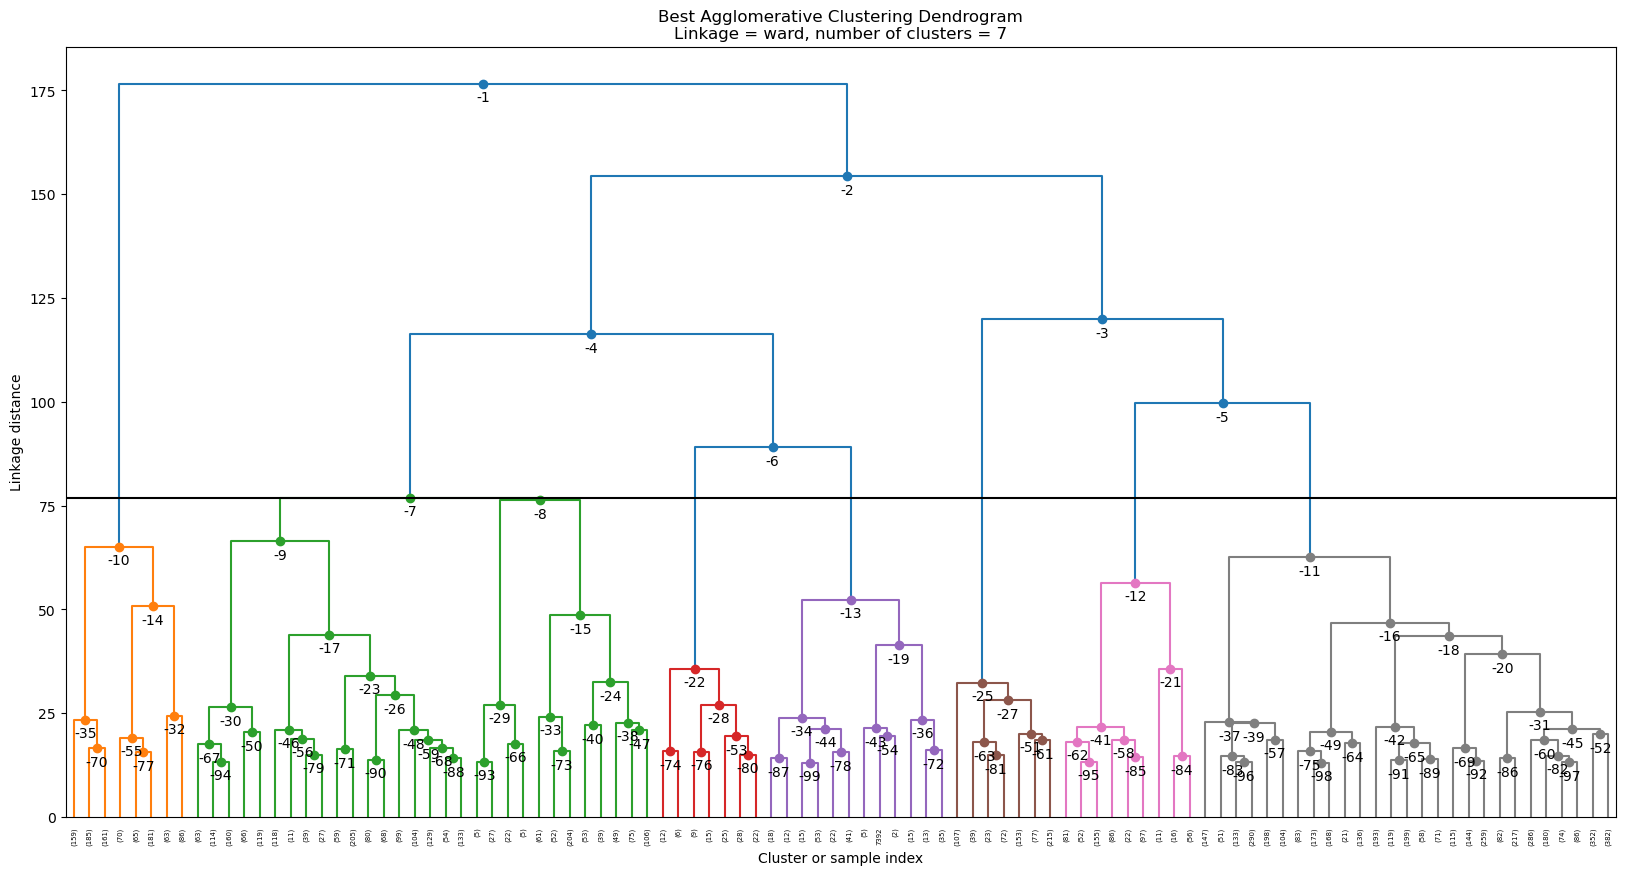

In [108]:
#plotting the dendrogram
best_agglomerative_model = best_model_details["model"]

fig, ax = plot_dendrogram(
    model=best_agglomerative_model,
    X=X_train_full,
    truncate_mode="lastp",
    p=100,
    n_clusters=best_n_clusters
)

ax.set_title(
    f"Best Agglomerative Clustering Dendrogram\n"
    f"Linkage = {best_linkage}, number of clusters = {best_n_clusters}"
)
ax.set_xlabel("Cluster or sample index")
ax.set_ylabel("Linkage distance")

plt.show()

### K-means clustering
We compare `random` and `k-means++` initialization for values of `K` from 2 to 15.

The silhouette is computed on a random sample of at most 2,000 observations only to reduce execution time.

In [109]:
number_of_clusters = range(2, 16)
initialization_methods = ["random", "k-means++"]

kmeans_results = []
kmeans_details = {}

for init_method in initialization_methods:
    for n_clusters in number_of_clusters:

        # Define and fit K-Means
        model = KMeans(n_clusters=n_clusters, init=init_method, n_init=10, random_state=0)
        cluster_labels = model.fit_predict(X_train_full)

        # Silhouette
        silhouette = silhouette_score(X_train_full, cluster_labels, 
            metric="euclidean",
            sample_size=min(2000, X_train_full.shape[0]),
            random_state=0)

        # External evaluation using the known Revenue labels
        purity_value = cluster_purity_score(y, cluster_labels)
        revenue_predictions, cluster_to_class = clusters_to_classes(cluster_labels,y)

        # Size and positive percentage of every cluster
        cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
        cluster_positive_percentage = (
            pd.DataFrame({
                "Cluster": cluster_labels,
                "Revenue": np.asarray(y).astype(int)
            }).groupby("Cluster")["Revenue"].mean().mul(100))

        #---------------------------------------------
        # Classification metrics
        #---------------------------------------------
        
        accuracy = accuracy_score(y, revenue_predictions)

        precision_value = precision_score(y, revenue_predictions, zero_division=0)

        recall_value = recall_score(y, revenue_predictions, zero_division=0)
        
        f1_value = f1_score(y, revenue_predictions, zero_division=0)

        # Main table: one row for each configuration
        kmeans_results.append({
            "init": init_method,
            "n_clusters": n_clusters,
            "silhouette": silhouette,
            "purity": purity_value,
            "accuracy": accuracy,
            "precision": precision_value,
            "recall": recall_value,
            "f1": f1_value,
            "smallest_cluster": cluster_sizes.min(),
            "largest_cluster": cluster_sizes.max(),
            "cluster_sizes": cluster_sizes.to_dict(),
            "positive_percentage": cluster_positive_percentage.round(2).to_dict()})

        # Additional information used later for the best model
        kmeans_details[(init_method, n_clusters)] = {
            "model": model,
            "cluster_labels": cluster_labels,
            "cluster_to_class": cluster_to_class,
            "revenue_predictions": revenue_predictions,
            "cluster_sizes": cluster_sizes,
            "positive_percentage": cluster_positive_percentage}

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df.sort_values(by="f1", ascending=False).head(10)

,init,n_clusters,silhouette,purity,accuracy,precision,recall,f1,smallest_cluster,largest_cluster,cluster_sizes,positive_percentage
25,k-means++,13,0.126708,0.874784,0.874784,0.790554,0.267176,0.399378,46,2635,"{0: 1189, 1: 703, 2: 669, 3: 475, 4: 2635, 5: ...","{0: 10.51, 1: 6.12, 2: 0.45, 3: 31.16, 4: 7.36..."
27,k-means++,15,0.123217,0.874459,0.874459,0.801724,0.258154,0.390551,38,2650,"{0: 653, 1: 839, 2: 546, 3: 688, 4: 595, 5: 12...","{0: 2.3, 1: 19.9, 2: 26.92, 3: 5.96, 4: 0.5, 5..."
4,random,6,0.212217,0.872405,0.872405,0.797267,0.242887,0.372340,413,5438,"{0: 439, 1: 686, 2: 413, 3: 723, 4: 1549, 5: 5...","{0: 79.73, 1: 0.44, 2: 30.99, 3: 6.22, 4: 22.6..."
18,k-means++,6,0.212623,0.872297,0.872297,0.800926,0.240111,0.369461,432,5474,"{0: 1493, 1: 440, 2: 686, 3: 723, 4: 5474, 5: ...","{0: 22.57, 1: 30.68, 2: 0.44, 3: 6.22, 4: 10.5..."
5,random,7,0.215244,0.871972,0.871972,0.799534,0.238029,0.366845,288,5417,"{0: 5417, 1: 1355, 2: 429, 3: 718, 4: 288, 5: ...","{0: 10.63, 1: 20.89, 2: 79.95, 3: 6.27, 4: 34...."
19,k-means++,7,0.217100,0.871972,0.871972,0.799534,0.238029,0.366845,294,5455,"{0: 294, 1: 5455, 2: 686, 3: 429, 4: 717, 5: 1...","{0: 36.05, 1: 10.6, 2: 0.44, 3: 79.95, 4: 6.28..."
6,random,8,0.131103,0.871324,0.871324,0.802410,0.231090,0.358836,292,4446,"{0: 712, 1: 1097, 2: 4446, 3: 292, 4: 1315, 5:...","{0: 6.32, 1: 22.61, 2: 10.89, 3: 25.0, 4: 11.7..."
20,k-means++,8,0.175613,0.871107,0.871107,0.805897,0.227620,0.354978,149,4990,"{0: 716, 1: 1654, 2: 4990, 3: 685, 4: 360, 5: ...","{0: 6.28, 1: 20.13, 2: 10.14, 3: 0.44, 4: 25.2..."
7,random,9,0.132467,0.870891,0.870891,0.804938,0.226232,0.353196,140,4048,"{0: 816, 1: 673, 2: 140, 3: 1291, 4: 706, 5: 3...","{0: 22.67, 1: 0.45, 2: 39.29, 3: 11.39, 4: 6.2..."
8,random,10,0.137177,0.870675,0.870675,0.811705,0.221374,0.347874,127,3841,"{0: 127, 1: 3841, 2: 1154, 3: 393, 4: 706, 5: ...","{0: 37.01, 1: 9.63, 2: 20.45, 3: 81.17, 4: 6.2..."


In [110]:
best_row = (kmeans_results_df.sort_values(by=["f1", "silhouette"],ascending=[False, False]).iloc[0])
best_init = best_row["init"]
best_n_clusters = int(best_row["n_clusters"])
best_model_details = kmeans_details[(best_init, best_n_clusters)]

best_kmeans_model = best_model_details["model"]
best_cluster_labels = best_model_details["cluster_labels"]
best_cluster_to_class = best_model_details["cluster_to_class"]

print("Best initialization:", best_init)
print("Best number of clusters:", best_n_clusters)
print("Silhouette:", best_row["silhouette"])
print("Purity:", best_row["purity"])
print("F1 after cluster-to-class mapping:", best_row["f1"])

Best initialization: k-means++
Best number of clusters: 13
Silhouette: 0.12670803769551356
Purity: 0.8747837370242214
F1 after cluster-to-class mapping: 0.3993775933609959


### DBSCAN

DBSCAN is a density-based clustering algorithm. Unlike K-Means, it does not
require the number of clusters to be specified in advance and it can identify
clusters with non-globular shapes.

DBSCAN also explicitly identifies observations that do not belong to a
sufficiently dense region. These observations are labelled as noise using the
cluster label `-1`.

The two main hyperparameters are:

- `eps`: maximum distance between two neighbouring observations;
    - if eps is too small, many observations will not have enough neighbours and will be classified as noise;
    - if eps is too large, separate dense regions may be merged into a single cluster.
- `min_samples`: minimum number of observations required to define a dense region.

For the DBSCAN clustering analysis we followed these steps:
1. __Train–validation split for DBSCAN hyperparameter selection__
2. __Preliminary selection of `eps` range using the kNN plot__: <br>
rather than choosing eps arbitrarily, the distances between each training observation and its 10-th nearest neighbour are analysed.  The main objective is to identify the elbow, namely the region where the curve starts increasing rapidly. Values before the elbow generally correspond to observations located inside dense regions, while values after it are more likely associated with sparse observations or noise.
3. __Approximate assignment of new observations to DBSCAN clusters__: <br>
Unlike algorithms such as K-Means, the DBSCAN implementation in scikit-learn does not provide a predict method for assigning unseen observations to the clusters found during training. With the function `predict_dbscan_clusters` each new observation is assigned to the cluster of its nearest DBSCAN core point, provided that this core point lies within the radius eps. Otherwise, the observation is labelled as noise (-1).
4. __Evaluation of the DBSCAN hyperparameter configurations__: <br>
After defining the candidate values for eps and min_samples, every possible combination of the two hyperparameters is evaluated.
5. __Selection of the best DBSCAN configuration__: <br>
The selection procedure gives priority to validation classification performance, while also considering the internal quality of the clustering and the proportion of validation observations classified as noise.
6. __Training of DBSCAN on the complete training set__: <br>
This allows DBSCAN to estimate the density structure from the largest possible amount of data before the model is used for the final analysis and for assigning the test observations to a cluster
7. __Final mapping from DBSCAN clusters to Revenue classes__: <br>
DBSCAN produces arbitrary cluster identifiers such as 0, 1, or 2. These identifiers do not directly correspond to the binary target values of Revenue. Therefore, each cluster is associated with the class that appears most frequently among the training observations assigned to that cluster.

In [111]:
# The validation set is used to select eps and min_samples.
X_dbscan_train, X_dbscan_val, y_dbscan_train, y_dbscan_val = train_test_split(
    X_train_full,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42)

print("DBSCAN training shape:", X_dbscan_train.shape)
print("DBSCAN validation shape:", X_dbscan_val.shape)

DBSCAN training shape: (6473, 74)
DBSCAN validation shape: (2775, 74)


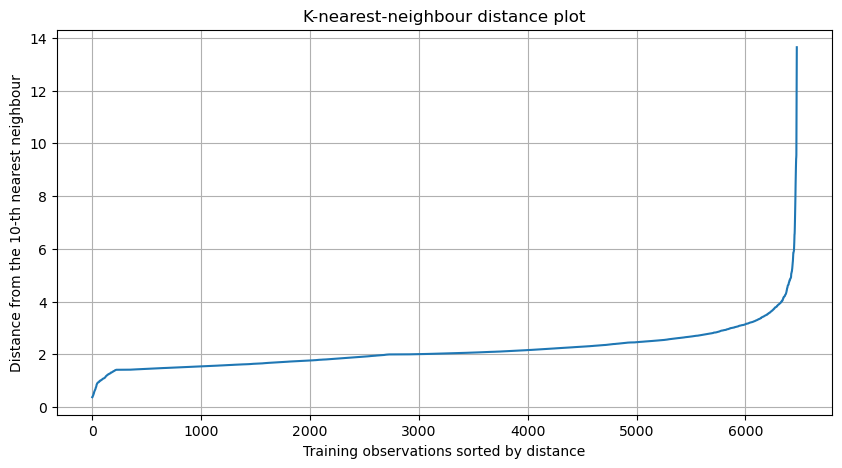

In [112]:
k_neighbors = 10

#model selection
nearest_neighbors = NearestNeighbors(n_neighbors=k_neighbors, metric="euclidean", n_jobs=-1)

#model fitting
nearest_neighbors.fit(X_dbscan_train)

distances, _ = nearest_neighbors.kneighbors(X_dbscan_train)

# Distance from the k-th nearest neighbour
k_distances = distances[:, -1]
sorted_k_distances = np.sort(k_distances)

plt.figure(figsize=(10, 5))
plt.plot(sorted_k_distances)

plt.xlabel("Training observations sorted by distance")
plt.ylabel(f"Distance from the {k_neighbors}-th nearest neighbour")
plt.title("K-nearest-neighbour distance plot")
plt.grid()

plt.show()

In [113]:
# we define a limited range of candidate values for the hyperparameters

eps_lower = np.percentile(k_distances, 80)
eps_upper = np.percentile(k_distances, 95)
eps_values = np.unique(np.round(np.linspace(eps_lower, eps_upper, 10),3))

min_samples_values = [5, 10, 15, 20]

print("eps values:", eps_values)
print("min_samples values:", min_samples_values)

eps values: [2.52  2.617 2.715 2.812 2.91  3.007 3.105 3.202 3.3   3.397]
min_samples values: [5, 10, 15, 20]


In [114]:
def predict_dbscan_clusters(model, X_new):
    """
    Assign each new observation to the cluster of its nearest core point.

    If the nearest core point is farther than eps, the observation is
    assigned to noise (-1).
    """

    # DBSCAN may produce no core points
    if len(model.core_sample_indices_) == 0:
        return np.full(X_new.shape[0], -1, dtype=int)

    core_points = model.components_

    # Cluster label associated with each core point
    core_labels = model.labels_[model.core_sample_indices_]

    nearest_core_model = NearestNeighbors(n_neighbors=1, metric="euclidean", n_jobs=-1)

    nearest_core_model.fit(core_points)

    distances, nearest_indices = nearest_core_model.kneighbors(X_new)

    distances = distances.ravel()
    nearest_indices = nearest_indices.ravel()

    predicted_clusters = np.full(X_new.shape[0], -1, dtype=int)

    assigned_mask = distances <= model.eps

    predicted_clusters[assigned_mask] = (
        core_labels[nearest_indices[assigned_mask]])

    return predicted_clusters

In [115]:
dbscan_results = []

# explore every combination of eps and min_samples
for eps in eps_values:

    for min_samples in min_samples_values:

        #Fitting the model on the training set
        model = DBSCAN(eps=float(eps), min_samples=int(min_samples), metric="euclidean", n_jobs=-1)

        train_cluster_labels = model.fit_predict(X_dbscan_train)

        # -----------------------------------------------------
        # Clusters and noise
        # -----------------------------------------------------

        non_noise_mask = train_cluster_labels != -1

        cluster_ids = np.unique(train_cluster_labels[non_noise_mask])

        n_clusters = len(cluster_ids)

        #measure the amount of training observations labelled as noise
        train_noise_points = np.sum(~non_noise_mask)
        train_noise_percentage = (100 * train_noise_points / len(train_cluster_labels))

        #cluster sizes
        cluster_sizes = (
            pd.Series(train_cluster_labels[non_noise_mask])
            .value_counts()
            .sort_index())

        if len(cluster_sizes) > 0:
            smallest_cluster = int(cluster_sizes.min())
            largest_cluster = int(cluster_sizes.max())
        else:
            smallest_cluster = 0
            largest_cluster = 0

        # Percentage of positive Revenue samples in each cluster.
        # Cluster -1 is included so that noise composition can be inspected.
        positive_percentage = (
            pd.DataFrame({
                "Cluster": train_cluster_labels,
                "Revenue": y_dbscan_train
            }).groupby("Cluster")["Revenue"].mean().mul(100))

        # -----------------------------------------------------
        # Silhouette on non-noise observations
        # -----------------------------------------------------

        X_non_noise = X_dbscan_train[non_noise_mask]
        labels_non_noise = train_cluster_labels[non_noise_mask]

        unique_non_noise_clusters = np.unique(labels_non_noise)

        # Verify whether the silhouette coefficient is defined
        if (
            len(unique_non_noise_clusters) >= 2
            and len(unique_non_noise_clusters) < len(labels_non_noise)):

            if len(labels_non_noise) <= 2000:

                # Use all non-noise observations
                X_silhouette = X_non_noise
                labels_silhouette = labels_non_noise

            else:
                rng = np.random.RandomState(0)

                # Include at least one observation from every cluster
                mandatory_indices = np.array([
                    np.where(labels_non_noise == cluster)[0][0]
                    for cluster in unique_non_noise_clusters])

                remaining_indices = np.setdiff1d(
                    np.arange(len(labels_non_noise)),
                    mandatory_indices)

                remaining_sample_size = 2000 - len(mandatory_indices)

                if remaining_sample_size > 0:
                    random_indices = rng.choice(
                        remaining_indices,
                        size=min(
                            remaining_sample_size,
                            len(remaining_indices)
                        ),
                        replace=False)

                    selected_indices = np.concatenate([
                        mandatory_indices,
                        random_indices])
                else:
                    selected_indices = mandatory_indices

                X_silhouette = X_non_noise[selected_indices]
                labels_silhouette = labels_non_noise[selected_indices]

            silhouette = silhouette_score(
                X_silhouette,
                labels_silhouette,
                metric="euclidean")

        else:
            silhouette = np.nan

        # -----------------------------------------------------
        # Purity on non-noise observations
        # -----------------------------------------------------

        if non_noise_mask.sum() > 0:
            train_purity = cluster_purity_score(
                y_dbscan_train[non_noise_mask],
                train_cluster_labels[non_noise_mask]
            )
        else:
            train_purity = np.nan

        # -----------------------------------------------------
        # Learn cluster-to-class mapping from training data
        # -----------------------------------------------------

        _, cluster_to_class = clusters_to_classes(train_cluster_labels, y_dbscan_train)

        # Explicit rule for noise:
        # assign it to the majority class of the training set.
        noise_class = pd.Series(y_dbscan_train).mode()[0]
        cluster_to_class[-1] = noise_class

        train_revenue_predictions = apply_cluster_to_class(
            train_cluster_labels,
            cluster_to_class)

        # -----------------------------------------------------
        # Validation-set assignment
        # -----------------------------------------------------

        validation_cluster_labels = predict_dbscan_clusters(model, X_dbscan_val)

        validation_noise_mask = validation_cluster_labels == -1

        validation_noise_points = validation_noise_mask.sum()

        validation_noise_percentage = (
            100
            * validation_noise_points
            / len(validation_cluster_labels))

        validation_non_noise_mask = ~validation_noise_mask

        if validation_non_noise_mask.sum() > 0:
            validation_purity = cluster_purity_score(
                y_dbscan_val[validation_non_noise_mask],
                validation_cluster_labels[validation_non_noise_mask]
            )
        else:
            validation_purity = np.nan

        validation_revenue_predictions = apply_cluster_to_class(
            validation_cluster_labels,
            cluster_to_class
        )

        # -----------------------------------------------------
        # Save results
        # -----------------------------------------------------

        dbscan_results.append({
            "eps": float(eps),
            "min_samples": int(min_samples),

            "n_clusters": n_clusters,

            "train_noise_points": train_noise_points,
            "train_noise_percentage": train_noise_percentage,

            "validation_noise_points": validation_noise_points,
            "validation_noise_percentage": validation_noise_percentage,

            "silhouette": silhouette,
            "train_purity": train_purity,
            "validation_purity": validation_purity,

            "accuracy": accuracy_score(y_dbscan_val, validation_revenue_predictions),

            "precision": precision_score(y_dbscan_val, validation_revenue_predictions, zero_division=0),

            "recall": recall_score(y_dbscan_val, validation_revenue_predictions, zero_division=0),

            "f1": f1_score(y_dbscan_val, validation_revenue_predictions, zero_division=0),

            "smallest_cluster": smallest_cluster,
            "largest_cluster": largest_cluster,
            "cluster_sizes": cluster_sizes.to_dict(),
            "positive_percentage": (
                positive_percentage.round(2).to_dict())})

        print(
            f"eps={eps}, min_samples={min_samples}: "
            f"clusters={n_clusters}, "
            f"train noise={train_noise_percentage:.1f}%, "
            f"validation F1="
            f"{dbscan_results[-1]['f1']:.3f}")

eps=2.52, min_samples=5: clusters=2, train noise=9.3%, validation F1=0.014
eps=2.52, min_samples=10: clusters=2, train noise=10.9%, validation F1=0.000
eps=2.52, min_samples=15: clusters=1, train noise=12.0%, validation F1=0.000
eps=2.52, min_samples=20: clusters=1, train noise=13.2%, validation F1=0.000
eps=2.617, min_samples=5: clusters=2, train noise=8.3%, validation F1=0.014
eps=2.617, min_samples=10: clusters=1, train noise=9.3%, validation F1=0.000
eps=2.617, min_samples=15: clusters=1, train noise=10.1%, validation F1=0.000
eps=2.617, min_samples=20: clusters=1, train noise=11.0%, validation F1=0.000
eps=2.715, min_samples=5: clusters=2, train noise=7.0%, validation F1=0.014
eps=2.715, min_samples=10: clusters=1, train noise=8.0%, validation F1=0.000
eps=2.715, min_samples=15: clusters=1, train noise=8.8%, validation F1=0.000
eps=2.715, min_samples=20: clusters=1, train noise=9.4%, validation F1=0.000
eps=2.812, min_samples=5: clusters=2, train noise=5.9%, validation F1=0.014
ep

In [116]:
#Table of results
dbscan_results_df = pd.DataFrame(dbscan_results)

columns_to_display = [
    "eps",
    "min_samples",
    "n_clusters",
    "train_noise_percentage",
    "validation_noise_percentage",
    "smallest_cluster",
    "largest_cluster",
    "silhouette",
    "train_purity",
    "validation_purity",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

dbscan_results_df.sort_values(
    by=[
        "f1",
        "silhouette",
        "validation_noise_percentage"
    ],
    ascending=[False, False, True],
    na_position="last"
)[columns_to_display].head(15)

,eps,min_samples,n_clusters,train_noise_percentage,validation_noise_percentage,smallest_cluster,largest_cluster,silhouette,train_purity,validation_purity,accuracy,precision,recall,f1
0,2.520,5,2,9.331068,9.873874,5,5864,0.256488,0.860794,0.862455,0.845405,1.0,0.006944,0.013793
4,2.617,5,2,8.311448,8.144144,5,5930,0.255579,0.859983,0.860337,0.845405,1.0,0.006944,0.013793
8,2.715,5,2,6.998301,7.063063,5,6015,0.149229,0.857641,0.856921,0.845405,1.0,0.006944,0.013793
12,2.812,5,2,5.855090,6.090090,5,6089,0.142460,0.855596,0.855334,0.845405,1.0,0.006944,0.013793
16,2.910,5,2,5.159895,5.333333,5,6134,0.127823,0.854048,0.853826,0.845405,1.0,0.006944,0.013793
1,2.520,10,2,10.906844,11.207207,10,5757,0.481372,0.863881,0.864448,0.844324,0.0,0.000000,0.000000
28,3.202,5,2,2.703538,3.135135,7,6291,0.383351,0.848682,0.847470,0.844324,0.0,0.000000,0.000000
20,3.007,5,3,4.155724,4.432432,3,6196,0.358045,0.851709,0.851056,0.843964,0.0,0.000000,0.000000
36,3.397,5,1,1.992894,2.702703,6344,6344,NaN,0.847730,0.847407,0.844324,0.0,0.000000,0.000000
32,3.300,5,1,2.255523,2.882883,6327,6327,NaN,0.847953,0.847866,0.844324,0.0,0.000000,0.000000


In [117]:
#Best DBSCAN selection model
valid_dbscan_results = dbscan_results_df[dbscan_results_df["n_clusters"] >= 2].copy()

if valid_dbscan_results.empty:
    print(
        "Warning: none of the tested configurations "
        "found at least two clusters.")

    valid_dbscan_results = dbscan_results_df.copy()


best_dbscan_row = (valid_dbscan_results.sort_values(
        by=[
            "f1",
            "silhouette",
            "validation_noise_percentage"
        ],
        ascending=[False, False, True], na_position="last").iloc[0])

best_eps = float(best_dbscan_row["eps"])
best_min_samples = int(best_dbscan_row["min_samples"])

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Number of clusters:", int(best_dbscan_row["n_clusters"]))
print("Silhouette:", best_dbscan_row["silhouette"])
print("Validation purity:", best_dbscan_row["validation_purity"])
print("Validation F1:", best_dbscan_row["f1"])
print(
    "Validation noise percentage:",
    best_dbscan_row["validation_noise_percentage"])

Best eps: 2.52
Best min_samples: 5
Number of clusters: 2
Silhouette: 0.2564880647929093
Validation purity: 0.8624550179928029
Validation F1: 0.013793103448275862
Validation noise percentage: 9.873873873873874


In [118]:
#addestramento su tutto il training set, dopo aver trovato gli iperparametri

#model selection
best_dbscan_model = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric="euclidean", n_jobs=-1)

#model fitting
final_train_cluster_labels = best_dbscan_model.fit_predict(X_train_full)

final_non_noise_mask = final_train_cluster_labels != -1

final_n_clusters = len(np.unique(final_train_cluster_labels[final_non_noise_mask]))

final_noise_points = np.sum(~final_non_noise_mask)

final_noise_percentage = (
    100
    * final_noise_points
    / len(final_train_cluster_labels))

print("Final number of clusters:", final_n_clusters)
print("Final training noise points:", final_noise_points)
print("Final training noise percentage:", final_noise_percentage)

Final number of clusters: 2
Final training noise points: 766
Final training noise percentage: 8.28287197231834


In [119]:
_, final_cluster_to_class = clusters_to_classes(final_train_cluster_labels, y)

# Explicit rule for noise points
final_noise_class = pd.Series(y).mode()[0]
final_cluster_to_class[-1] = final_noise_class

print("Cluster-to-class mapping:")
print(final_cluster_to_class)

print("Class assigned to noise:", final_noise_class)

Cluster-to-class mapping:
{np.int64(-1): np.False_, np.int64(0): np.False_, np.int64(1): np.True_}
Class assigned to noise: False


In [120]:
cluster_composition = pd.crosstab(
    pd.Series(final_train_cluster_labels, name="Cluster"),
    pd.Series(y, name="Revenue"))

cluster_composition = cluster_composition.reindex(columns=[0, 1], fill_value=0)

cluster_composition.columns = ["Revenue=False", "Revenue=True"]

cluster_composition["Total"] = (cluster_composition.sum(axis=1))

cluster_composition["Revenue=True (%)"] = (
    100
    * cluster_composition["Revenue=True"]
    / cluster_composition["Total"])

cluster_composition["Mapped class"] = [
    final_cluster_to_class[cluster]
    for cluster in cluster_composition.index]

cluster_composition

,Revenue=False,Revenue=True,Total,Revenue=True (%),Mapped class
Cluster,,,,,
-1,523,243,766,31.723238,False
0,7284,1196,8480,14.103774,False
1,0,2,2,100.000000,True


### Summary

In [121]:
# Best Agglomerative Clustering configuration.
# F1 is the primary criterion and silhouette is used to break ties.
best_agglomerative_row = (results_df.sort_values(by=["f1", "silhouette"],ascending=[False, False]).iloc[0])

# Best K-Means configuration
best_kmeans_row = (kmeans_results_df.sort_values(by=["f1", "silhouette"], ascending=[False, False]).iloc[0])

# Best DBSCAN configuration.
# The variables valid_dbscan_results and best_dbscan_row were already
# created during the DBSCAN analysis.
best_dbscan_row = (valid_dbscan_results.sort_values(
        by=[
            "f1",
            "silhouette",
            "validation_noise_percentage"
        ],
        ascending=[False, False, True], na_position="last").iloc[0])

# Create one row for each clustering method
clustering_summary = pd.DataFrame([
    {
        "Method": "Agglomerative Clustering",
        "Best configuration": (
            f"linkage={best_agglomerative_row['linkage']}, "
            f"n_clusters={int(best_agglomerative_row['n_clusters'])}"
        ),
        "Evaluation data": "Training set",
        "Number of clusters": int(best_agglomerative_row["n_clusters"]),
        "Silhouette": best_agglomerative_row["silhouette"],
        "Purity": best_agglomerative_row["purity"],
        "Accuracy": best_agglomerative_row["accuracy"],
        "Precision": best_agglomerative_row["precision"],
        "Recall": best_agglomerative_row["recall"],
        "F1": best_agglomerative_row["f1"],
        "Noise (%)": np.nan
    },
    {
        "Method": "K-Means",
        "Best configuration": (
            f"init={best_kmeans_row['init']}, "
            f"n_clusters={int(best_kmeans_row['n_clusters'])}"
        ),
        "Evaluation data": "Training set",
        "Number of clusters": int(best_kmeans_row["n_clusters"]),
        "Silhouette": best_kmeans_row["silhouette"],
        "Purity": best_kmeans_row["purity"],
        "Accuracy": best_kmeans_row["accuracy"],
        "Precision": best_kmeans_row["precision"],
        "Recall": best_kmeans_row["recall"],
        "F1": best_kmeans_row["f1"],
        "Noise (%)": np.nan
    },
    {
        "Method": "DBSCAN",
        "Best configuration": (
            f"eps={best_dbscan_row['eps']:.3f}, "
            f"min_samples={int(best_dbscan_row['min_samples'])}"
        ),
        "Evaluation data": "Validation set",
        "Number of clusters": int(best_dbscan_row["n_clusters"]),
        "Silhouette": best_dbscan_row["silhouette"],
        "Purity": best_dbscan_row["validation_purity"],
        "Accuracy": best_dbscan_row["accuracy"],
        "Precision": best_dbscan_row["precision"],
        "Recall": best_dbscan_row["recall"],
        "F1": best_dbscan_row["f1"],
        "Noise (%)": best_dbscan_row["validation_noise_percentage"]
    }
])

# Sort the methods from the highest to the lowest F1 score
clustering_summary = (clustering_summary.sort_values("F1", ascending=False).reset_index(drop=True))

display(
    clustering_summary.style.format({
        "Silhouette": "{:.4f}",
        "Purity": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Noise (%)": "{:.2f}"
    })
)

,Method,Best configuration,Evaluation data,Number of clusters,Silhouette,Purity,Accuracy,Precision,Recall,F1,Noise (%)
0,Agglomerative Clustering,"linkage=ward, n_clusters=7",Training set,7,0.1571,0.8781,0.8781,0.7726,0.3088,0.4412,nan
1,K-Means,"init=k-means++, n_clusters=13",Training set,13,0.1267,0.8748,0.8748,0.7906,0.2672,0.3994,nan
2,DBSCAN,"eps=2.520, min_samples=5",Validation set,2,0.2565,0.8625,0.8454,1.0000,0.0069,0.0138,9.87


###  Test evaluation of Agglomerative Clustering
Since AgglomerativeClustering does not provide a native prediction method, unseen test observations were assigned to the nearest centroid of the clusters identified on the training set. The resulting cluster labels were subsequently converted into Revenue predictions using the majority-class mapping learned exclusively from the training data.

In [122]:
# Retrieve the best Agglomerative Clustering hyperparameters
best_agglomerative_linkage = best_agglomerative_row["linkage"]
best_agglomerative_n_clusters = int(
    best_agglomerative_row["n_clusters"])

best_row = results_df.loc[results_df["f1"].idxmax()]
best_linkage = best_row["linkage"]
best_n_clusters = int(best_row["n_clusters"])

print("Selected linkage:", best_agglomerative_linkage)
print("Selected number of clusters:", best_agglomerative_n_clusters)


Selected linkage: ward
Selected number of clusters: 7


In [123]:
# Separate predictors and target
X_agg_train_raw = train_data.drop(columns=["Revenue"]).copy()
X_agg_test_raw = test_data.drop(columns=["Revenue"]).copy()

y_agg_train = train_data["Revenue"].astype(int).to_numpy()
y_agg_test = test_data["Revenue"].astype(int).to_numpy()

# Identify the categorical variables that are present in the data
agg_categorical_features = [column for column in Categorical_columns if column in X_agg_train_raw.columns]

# Create dummy variables separately for training and test data
X_agg_train_encoded = pd.get_dummies(
    X_agg_train_raw,
    columns=agg_categorical_features,
    drop_first=False,
    dtype=float)

X_agg_test_encoded = pd.get_dummies(
    X_agg_test_raw,
    columns=agg_categorical_features,
    drop_first=False,
    dtype=float)

# Ensure that the test set contains exactly the same columns, in the same order, as the training set
X_agg_test_encoded = X_agg_test_encoded.reindex(columns=X_agg_train_encoded.columns, fill_value=0)

print("Encoded training shape:", X_agg_train_encoded.shape)
print("Encoded test shape:", X_agg_test_encoded.shape)

Encoded training shape: (9248, 74)
Encoded test shape: (3082, 74)


In [124]:
# Select the numerical columns that are still present
agg_numerical_features = [
    column
    for column in Numerical_columns
    if column in X_agg_train_encoded.columns]

# Fit StandardScaler only on the training set.
# The fitted transformation is then applied to the test set.
agg_preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), agg_numerical_features)], remainder="passthrough")

X_agg_train = agg_preprocessor.fit_transform(X_agg_train_encoded)

X_agg_test = agg_preprocessor.transform(X_agg_test_encoded)

print("Processed training shape:", X_agg_train.shape)
print("Processed test shape:", X_agg_test.shape)

Processed training shape: (9248, 74)
Processed test shape: (3082, 74)


In [125]:
# Fit the final agglomerative model
final_agglomerative_model = AgglomerativeClustering(
    n_clusters=best_agglomerative_n_clusters,
    linkage=best_agglomerative_linkage,
    metric="euclidean")

# Agglomerative Clustering returns a cluster for each training observation
agg_train_cluster_labels = (final_agglomerative_model.fit_predict(X_agg_train))

# Associate each training cluster with its majority Revenue class
_, agg_cluster_to_class = clusters_to_classes(agg_train_cluster_labels, y_agg_train)

# Compute training cluster centroids

agg_cluster_ids = np.sort(np.unique(agg_train_cluster_labels))

# Compute the centroid of every cluster in the standardized
# feature space
agg_cluster_centroids = np.vstack([
X_agg_train[
        agg_train_cluster_labels == cluster_id
    ].mean(axis=0)
    for cluster_id in agg_cluster_ids
])

print("Number of computed centroids:", len(agg_cluster_centroids))

# Assign test observation to the nearest centroid

# Fit a nearest-neighbour model using the cluster centroids
nearest_centroid_model = NearestNeighbors(n_neighbors=1, metric="euclidean")

nearest_centroid_model.fit(agg_cluster_centroids)

# Find the nearest centroid for every test observation
test_centroid_distances, test_centroid_indices = (nearest_centroid_model.kneighbors(X_agg_test))

test_centroid_indices = test_centroid_indices.ravel()

# Convert centroid positions back into the original cluster IDs
agg_test_cluster_labels = agg_cluster_ids[test_centroid_indices]

# Convert the assigned clusters into Revenue predictions
agg_test_predictions = apply_cluster_to_class(
    agg_test_cluster_labels,
    agg_cluster_to_class
).astype(int)

Number of computed centroids: 7


In [126]:
#Test performance

agg_test_accuracy = accuracy_score(y_agg_test, agg_test_predictions)

agg_test_precision = precision_score(y_agg_test, agg_test_predictions, zero_division=0)

agg_test_recall = recall_score(y_agg_test, agg_test_predictions, zero_division=0)

agg_test_f1 = f1_score(y_agg_test, agg_test_predictions, zero_division=0)

agglomerative_test_results = pd.DataFrame([{
    "Method": "Agglomerative Clustering",
    "Linkage": best_agglomerative_linkage,
    "Number of clusters": best_agglomerative_n_clusters,
    "Assignment rule": "Nearest training-cluster centroid",
    "Test Accuracy": agg_test_accuracy,
    "Test Precision": agg_test_precision,
    "Test Recall": agg_test_recall,
    "Test F1": agg_test_f1}])

display(
    agglomerative_test_results.style.format({
        "Test Accuracy": "{:.4f}",
        "Test Precision": "{:.4f}",
        "Test Recall": "{:.4f}",
        "Test F1": "{:.4f}"}))

print("\nClassification report:")
print(
    classification_report(
        y_agg_test,
        agg_test_predictions,
        target_names=["Revenue=False", "Revenue=True"],
        zero_division=0))

,Method,Linkage,Number of clusters,Assignment rule,Test Accuracy,Test Precision,Test Recall,Test F1
0,Agglomerative Clustering,ward,7,Nearest training-cluster centroid,0.8851,0.7958,0.3255,0.4620



Classification report:
               precision    recall  f1-score   support

Revenue=False       0.89      0.99      0.94      2615
 Revenue=True       0.80      0.33      0.46       467

     accuracy                           0.89      3082
    macro avg       0.84      0.66      0.70      3082
 weighted avg       0.88      0.89      0.86      3082



# Final conclusion

This project investigated the prediction of online purchasing intention through three connected stages: recovery of the missing `ExitRates` values, supervised classification of the `Revenue` target, and clustering-based analysis.

For the regression task, the linear model trained on the forward-selected subset of 25 features achieved the best cross-validation performance, with a mean (R^2) of approximately 0.8595 and a mean MSE of approximately (3.23 \times 10^{-4}). Its performance on the internal test set was consistent, obtaining an (R^2) of approximately 0.8658. Ridge and LASSO regression produced very similar results, so the selected subset model should not be considered substantially more accurate; it was preferred because it combined competitive predictive performance with a smaller and more interpretable feature set. The model was subsequently retrained on all observations with known `ExitRates` and used to recover the missing values in both the training and test datasets.

For the supervised classification task, the best-performing model was an RBF Support Vector Machine combined with `SelectKBest`, which retained 15 features. The model achieved a mean cross-validation F1 score of approximately 0.6067. On the provided test set, it obtained an accuracy of 0.9014, a precision of 0.7390, a recall of 0.5396 and an F1 score of 0.6238. These results indicate that the model maintains high overall accuracy while providing a substantially better identification of purchasing sessions than simpler linear and distance-based alternatives.

Removing `ExitRates` produced a slightly higher test F1 score, increasing it from 0.6238 to 0.6326, together with a small increase in recall. The observed difference is limited, and therefore it does not support the conclusion that the imputed `ExitRates` information improves the selected classifier. Instead, the results suggest that most of the useful information contained in `ExitRates` may already be represented by related browsing variables, particularly `BounceRates`, `PageValues` and the page-activity features. A cross-validated comparison with independent hyperparameter tuning should nevertheless be used before drawing a definitive conclusion about the usefulness of this feature.

The clustering experiments produced substantially weaker class-prediction performance than the supervised SVM. During the exploratory analysis, Agglomerative Clustering and K-Means achieved mapped F1 scores of approximately 0.441 and 0.399, respectively, while DBSCAN was unable to recover a useful separation of the purchasing class. Since Agglomerative Clustering does not provide a native prediction method, test observations were assigned to their nearest training-cluster centroid and then converted into class predictions using the cluster-to-class mapping. Agglomerative Clustering obtained a test accuracy of 0.8851, precision of 0.7958, recall of 0.3255 and F1 score of 0.4620. This was substantially lower than the RBF SVM test F1 score of 0.6238, indicating that the natural cluster structure of the predictors does not align as closely with Revenue as the decision boundary learned through supervised classification.

Overall, the results show that supervised learning is considerably more suitable than clustering for predicting online purchasing intention in this dataset. Among the evaluated approaches, the feature-selected RBF SVM provides the best balance between precision, recall and generalization performance.
